<a href="https://colab.research.google.com/github/Shafnpt/HE-Fault-detection-and-control-system/blob/main/PROJECT_WITH_CLEAN_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision torchaudio tqdm matplotlib pandas numpy scipy scikit-learn gekko xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 13.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# DATA LOADING

import pandas as pd
clean_df = pd.read_excel('/content/drive/MyDrive/he_clean_data.xlsx')


In [ ]:
# DATA PROPERTIES AND INFO
import pandas as pd
import numpy as np
print(clean_df.shape)
print(clean_df.columns.tolist())
print(clean_df.head())
print(clean_df.info())

(10000, 12)
['Time', 'hot_inlet_temperature_k', 'cold_inlet_temperature_k', 'cold_inlet_mass_flow_kg_s', 'hot_outlet_temperature_k', 'cold_outlet_temperature_k', 'hx_1_heat_load_kw', 'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa', 'hot_outlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s', 'LMTD']
                 Time  hot_inlet_temperature_k  cold_inlet_temperature_k  \
0 2024-01-01 00:00:00                   373.15                281.214900   
1 2024-01-01 01:00:00                   373.15                281.076499   
2 2024-01-01 02:00:00                   373.15                280.965146   
3 2024-01-01 03:00:00                   373.15                280.874257   
4 2024-01-01 04:00:00                   373.15                280.798714   

   cold_inlet_mass_flow_kg_s  hot_outlet_temperature_k  \
0                   0.500000                   378.649   
1                   0.545455                   378.394   
2                   0.590909                   378.173   
3       

In [ ]:
numerical_cols_clean = clean_df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns in clean_df:", numerical_cols_clean)

Numerical columns in clean_df: ['hot_inlet_temperature_k', 'cold_inlet_temperature_k', 'cold_inlet_mass_flow_kg_s', 'hot_outlet_temperature_k', 'cold_outlet_temperature_k', 'hx_1_heat_load_kw', 'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa', 'hot_outlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s', 'LMTD']


In [ ]:
# OUTLIER DETECTION AND REMOVAL
import pandas as pd
import numpy as np
def remove_outliers_iqr(df, col):
    """Removes outliers from a DataFrame column using the IQR method."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
    return df_cleaned

print("Shape of clean_df before outlier removal:", clean_df.shape)

for col in numerical_cols_clean:
    clean_df = remove_outliers_iqr(clean_df, col)

print("Shape of clean_df after outlier removal:", clean_df.shape)
display(clean_df.head())

Shape of clean_df before outlier removal: (10000, 12)
Shape of clean_df after outlier removal: (9222, 12)


,Time,hot_inlet_temperature_k,cold_inlet_temperature_k,cold_inlet_mass_flow_kg_s,hot_outlet_temperature_k,cold_outlet_temperature_k,hx_1_heat_load_kw,hot_outlet_pressure_pa,cold_outlet_pressure_pa,hot_outlet_mass_flow_kg_s,cold_outlet_mass_flow_kg_s,LMTD
0,2024-01-01 00:00:00,373.15,281.214900,0.500000,378.649,301.151,61.3959,500000,100000,1,0.500000,84.076299
1,2024-01-01 01:00:00,373.15,281.076499,0.545455,378.394,301.151,62.4725,500000,100000,1,0.545455,84.023449
2,2024-01-01 02:00:00,373.15,280.965146,0.590909,378.173,301.151,63.4044,500000,100000,1,0.590909,83.973732
3,2024-01-01 03:00:00,373.15,280.874257,0.636364,377.981,301.151,64.2172,500000,100000,1,0.636364,83.927870
4,2024-01-01 04:00:00,373.15,280.798714,0.681818,377.811,301.151,64.9323,500000,100000,1,0.681818,83.885013


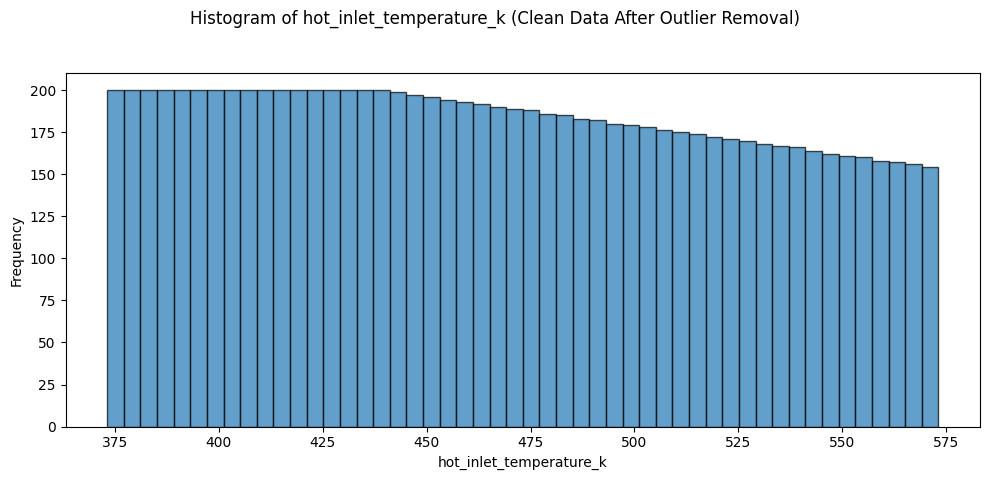

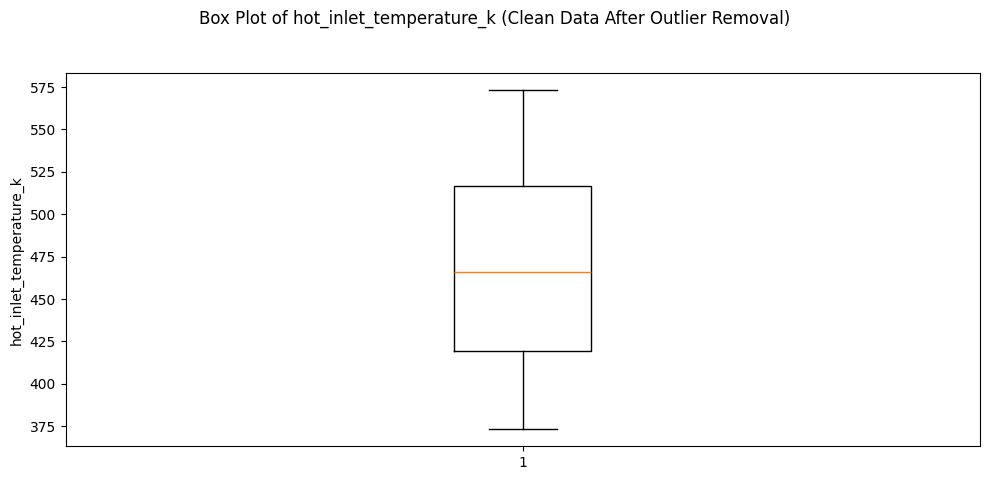

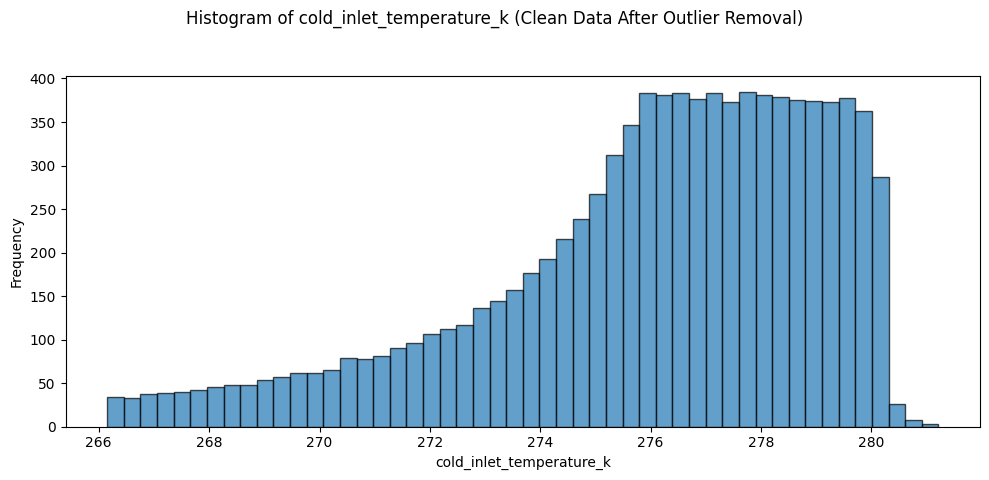

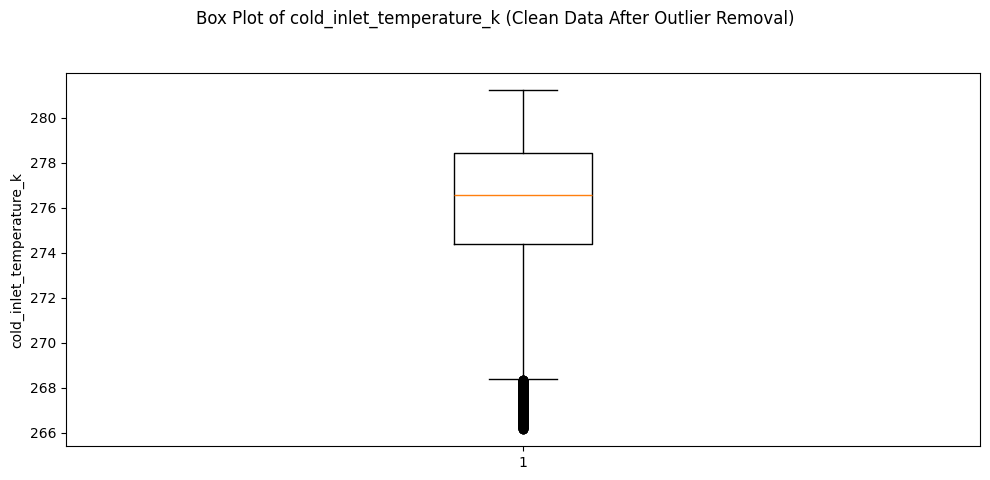

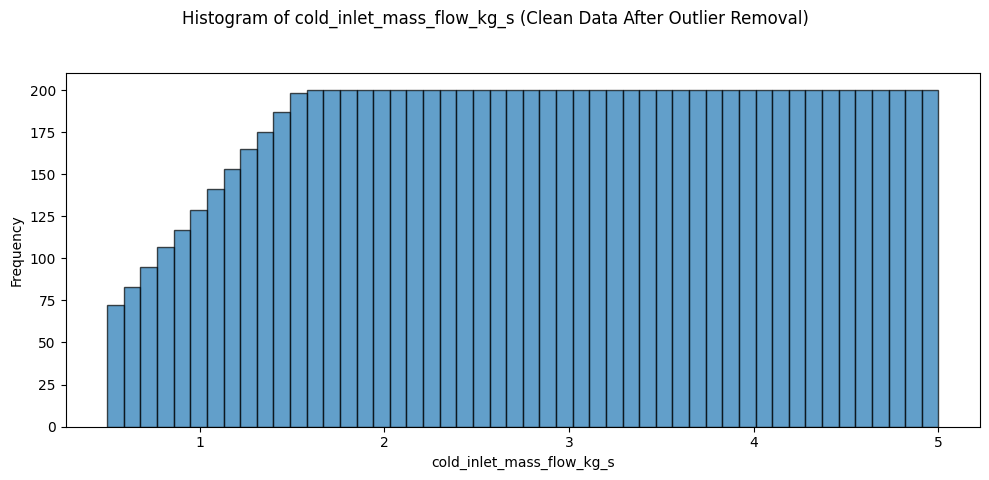

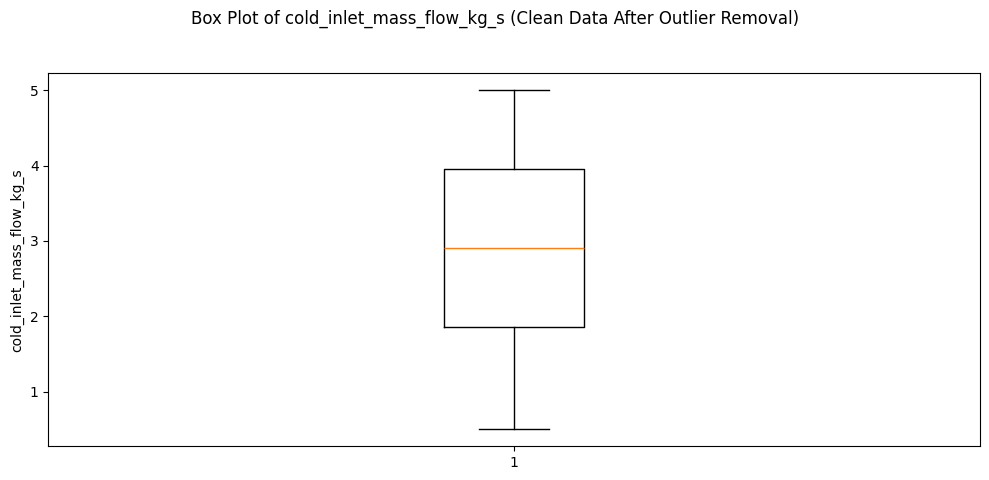

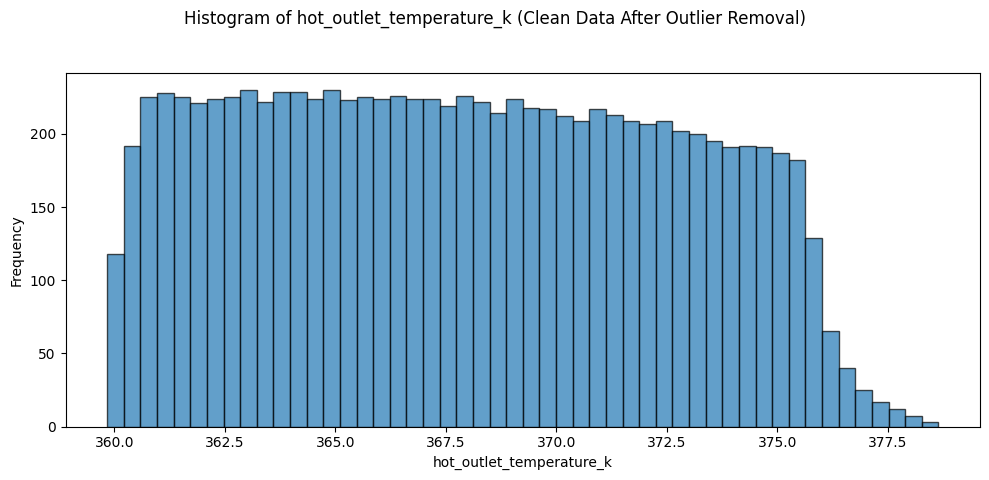

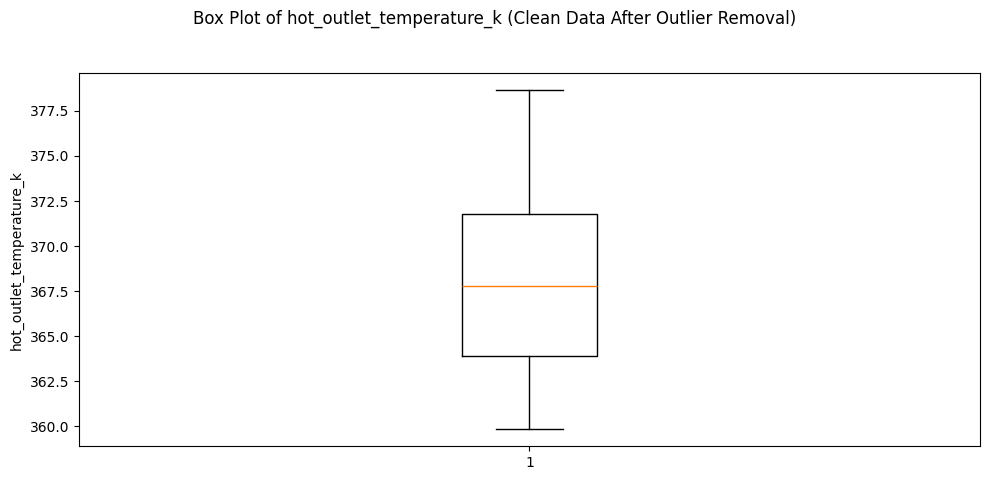

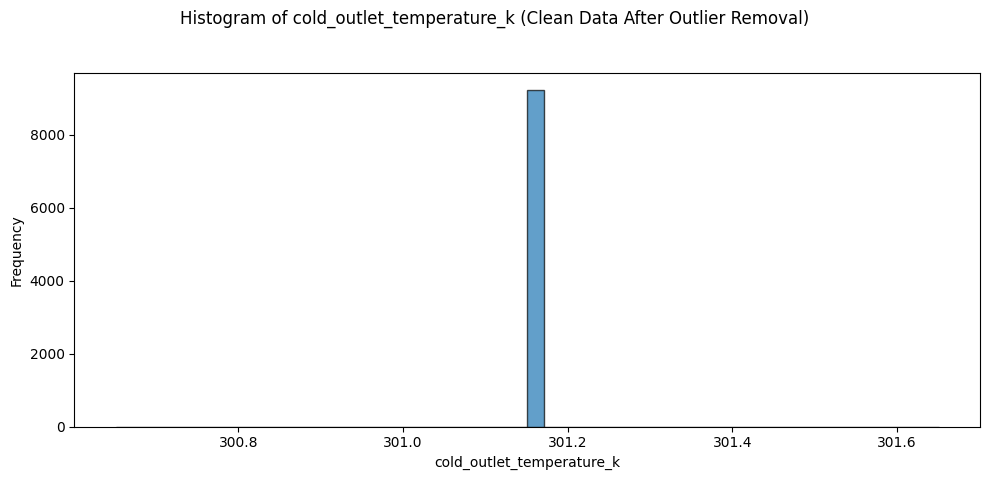

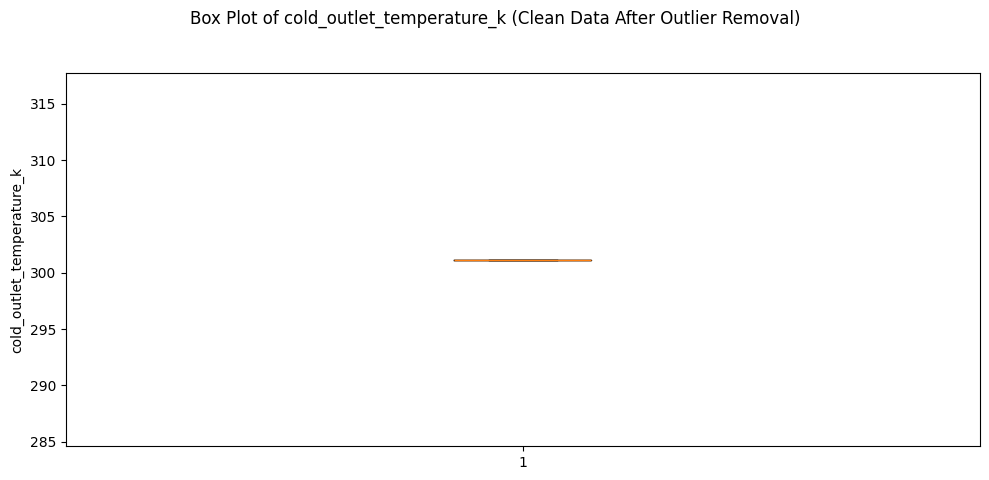

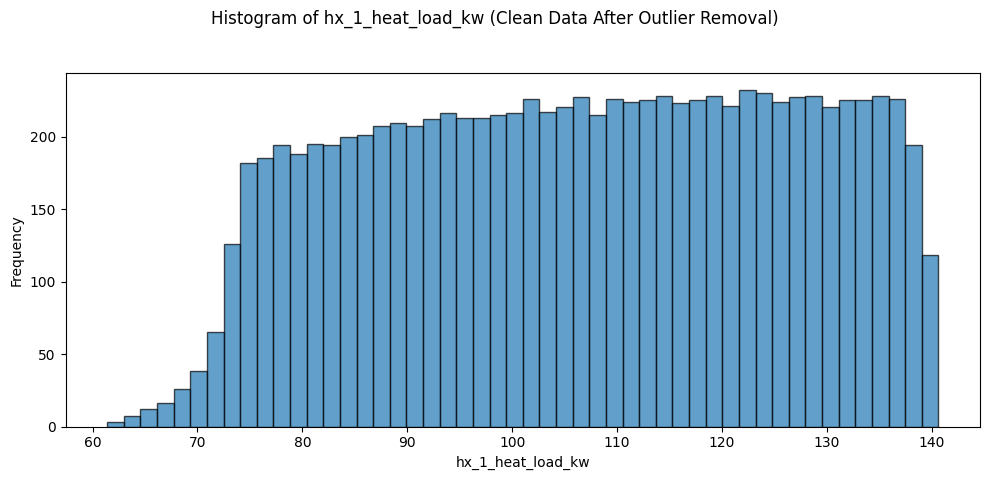

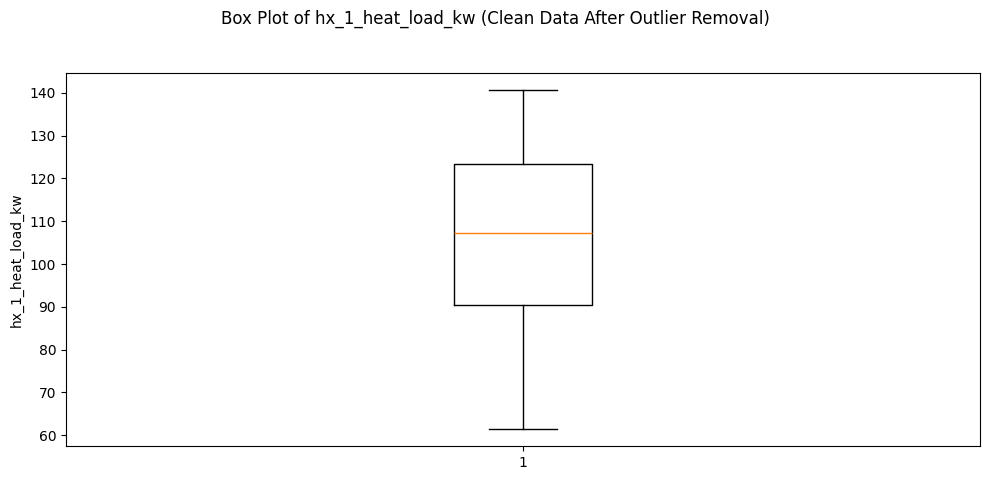

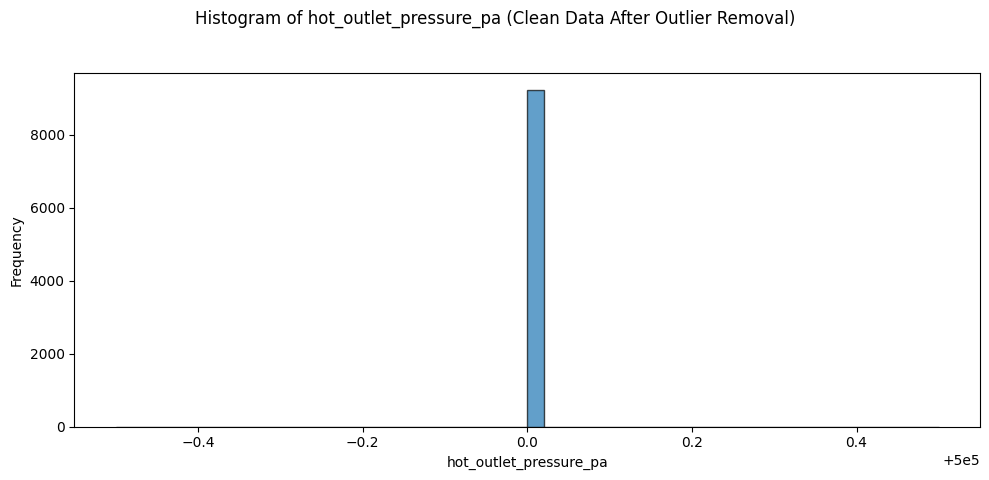

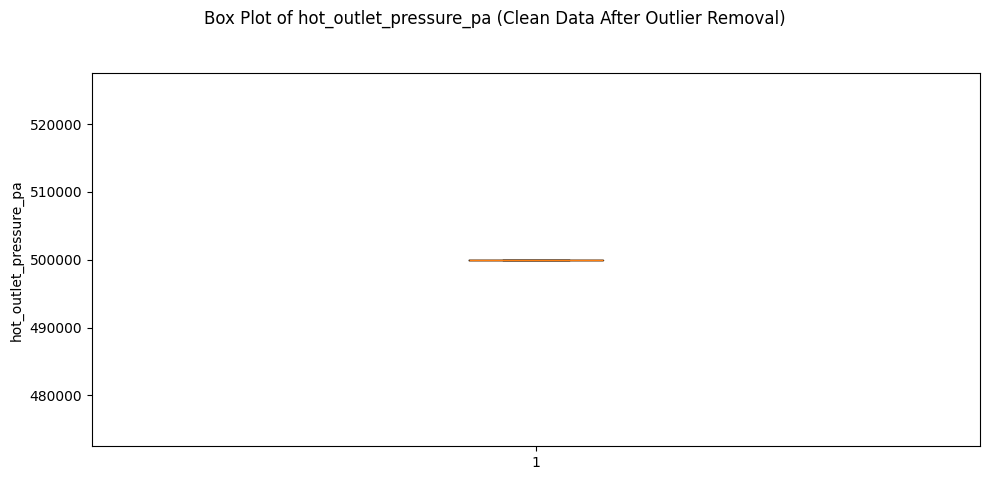

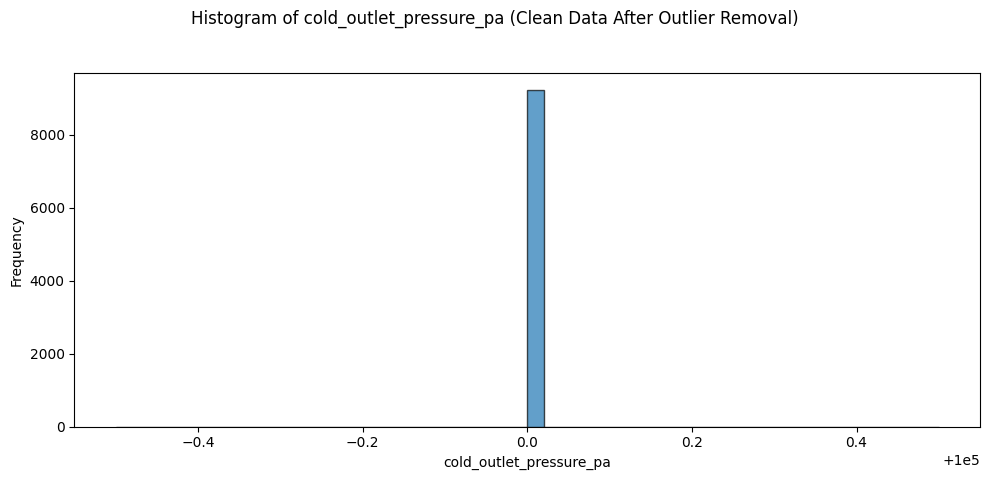

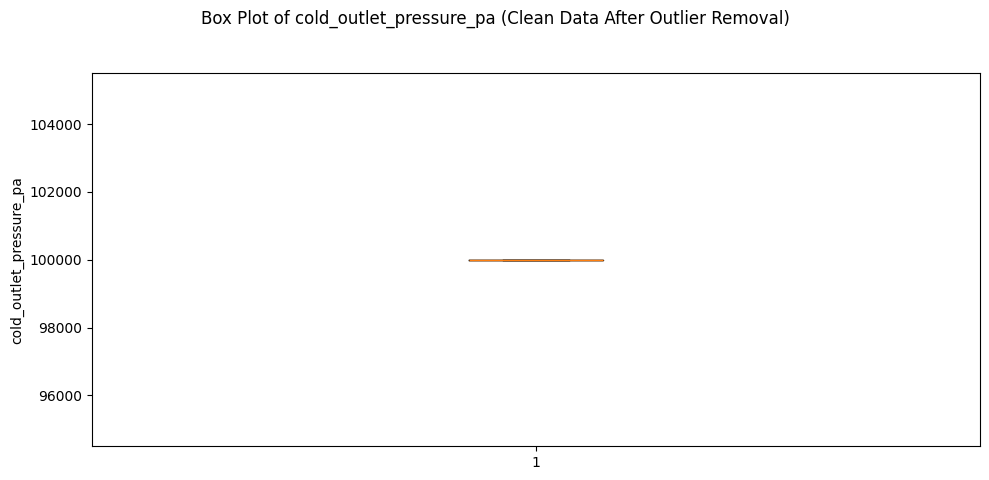

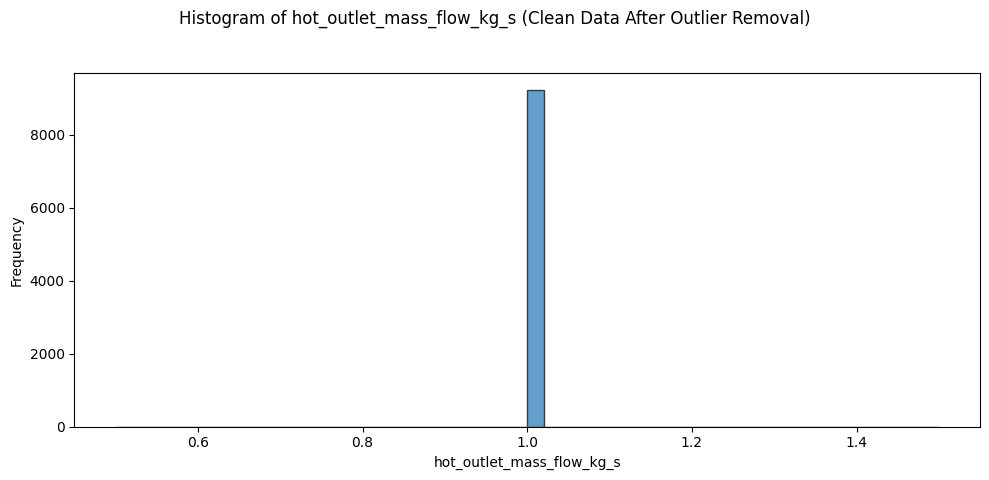

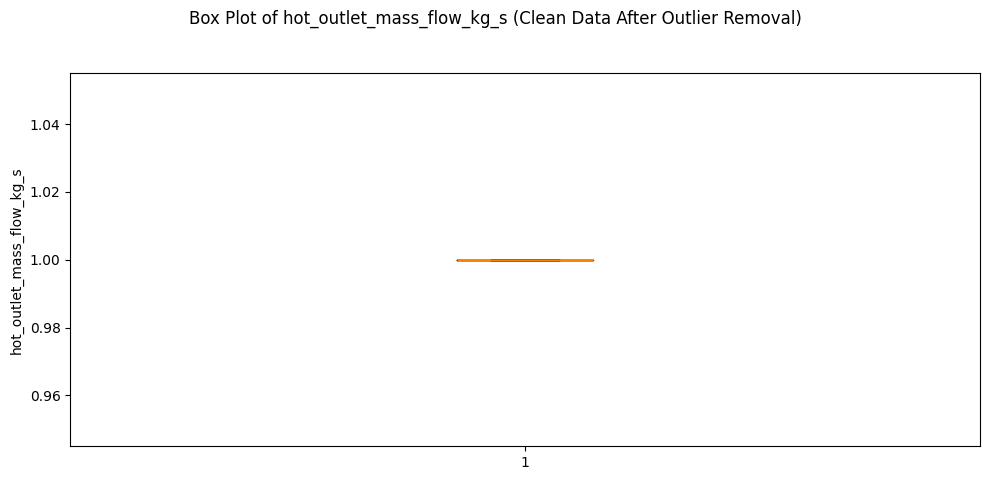

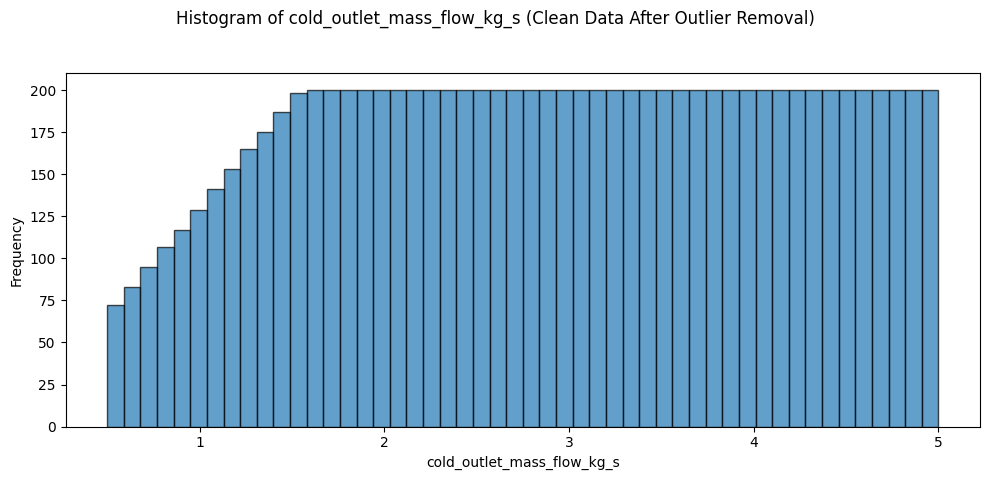

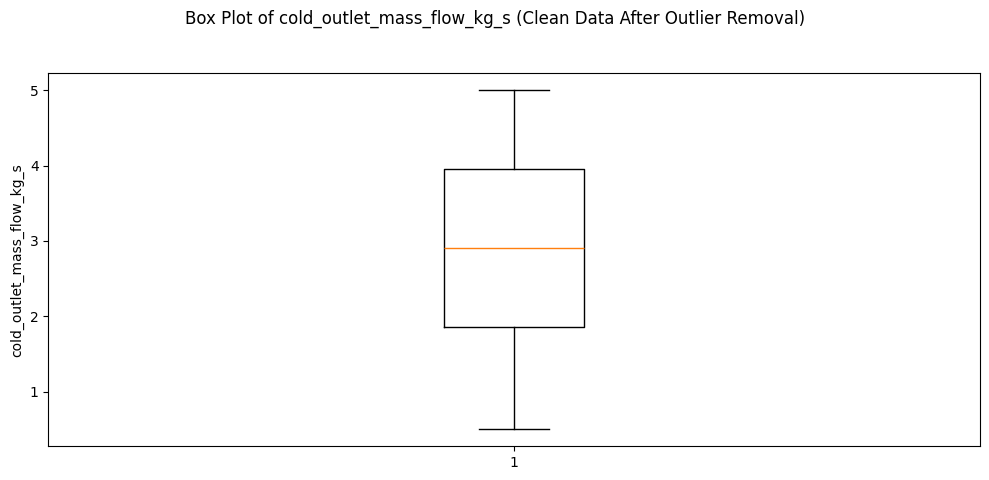

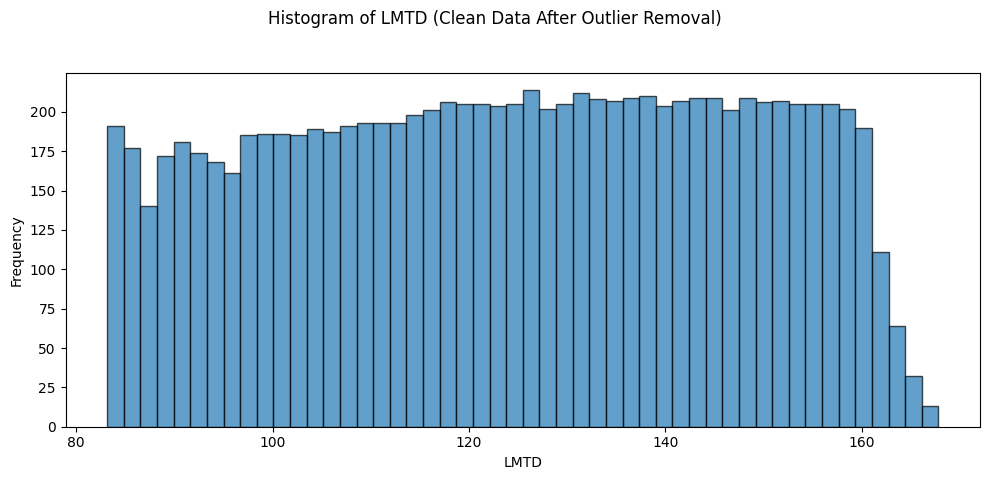

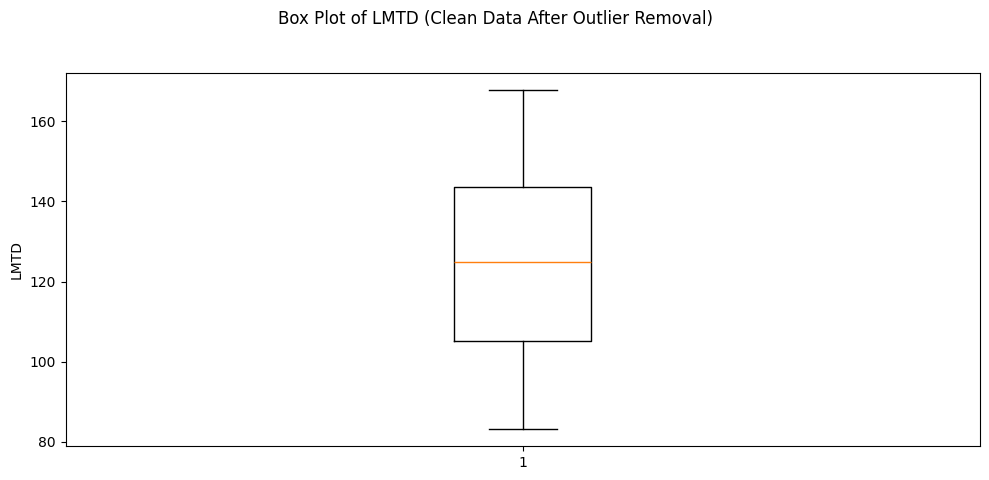

In [ ]:
import matplotlib.pyplot as plt

# data visual after outlier removal
for col in numerical_cols_clean:
    # Create figure for histograms
    fig_hist, axes_hist = plt.subplots(1, 1, figsize=(10, 5))
    fig_hist.suptitle(f'Histogram of {col} (Clean Data After Outlier Removal)')

    # Histogram for cleaned data
    axes_hist.hist(clean_df[col], bins=50, edgecolor='k', alpha=0.7)
    axes_hist.set_xlabel(col)
    axes_hist.set_ylabel('Frequency')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Create figure for box plots
    fig_box, axes_box = plt.subplots(1, 1, figsize=(10, 5))
    fig_box.suptitle(f'Box Plot of {col} (Clean Data After Outlier Removal)')

    # Box plot for cleaned data
    axes_box.boxplot(clean_df[col])
    axes_box.set_ylabel(col)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# Save the dataframe with outliers removed from clean_df
clean_df.to_csv('/content/drive/MyDrive/he_clean_data_outliers_removed.csv', index=False)

print("Cleaned dataframes saved successfully.")

Cleaned dataframes saved successfully.


In [ ]:
#Autodetecting time,T,P,Flow columns
df = pd.read_csv('/content/drive/MyDrive/he_clean_data_outliers_removed.csv')

print("Dataset shape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print(" -", c)

print("\nRows:")
display(df.head())


# Time handling, duplicates, and missing-value basic strategy
# Try to detect time column automatically

time_col = None
for c in df.columns:
    if "time" in c.lower() or "date" in c.lower():
        time_col = c
        break

if time_col:
    print("Detected time column:", time_col)
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
else:
    print("No time column found — creating synthetic time index (10s step).")
    df["time"] = pd.to_timedelta(np.arange(len(df))*10, unit="s")
    time_col = "time"

# Drop exact duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {before - len(df)} duplicate rows")

# Fill missing values: interpolate then ffill/bfill
num_missing_before = df.isna().sum().sum()
df = df.interpolate(method="linear", limit_direction="both")
df = df.fillna(method="ffill").fillna(method="bfill")
num_missing_after = df.isna().sum().sum()
print(f"Missing values before: {num_missing_before}, after cleaning: {num_missing_after}")

display(df[[time_col]].head())

# Detect pressure, flow, and temperature columns (auto-detect)
cols = df.columns.tolist()

# Common names we'll look for (adjust if your file uses different labels)
candidates = {
    "pressure_hot": ["hot_outlet_pressure_pa","hot_pressure","pressure_hot","P_hot","Hot_Pressure"],
    "pressure_cold": ["cold_outlet_pressure_pa","cold_pressure","pressure_cold","P_cold","Cold_Pressure"],
    "flow_hot": ["hot_outlet_mass_flow_kg_s", "hot_mass_flow", "Flow_hot","flow_hot","flowHot","hot_flow"],
    "flow_cold": ["cold_inlet_mass_flow_kg_s", "cold_outlet_mass_flow_kg_s", "cold_mass_flow", "Flow_cold","flow_cold","flowCold","cold_flow"],
    "T_hot_in": ["hot_inlet_temperature_k", "T_hot_in","Th_in","T_hot_inlet","T_hot_inlet"],
    "T_hot_out": ["hot_outlet_temperature_k", "T_hot_out","Th_out","T_hot_outlet"],
    "T_cold_in": ["cold_inlet_temperature_k", "T_cold_in","Tc_in","T_cold_inlet"],
    "T_cold_out": ["cold_outlet_temperature_k", "T_cold_out","Tc_out","T_cold_outlet"]
}

found = {}
for key, names in candidates.items():
    found[key] = None
    for n in names:
        if n in cols:
            found[key] = n
            break

print("Auto-detected column mapping (None = not found):")
for k,v in found.items():
    print(f" {k:12s} -> {v}")

# If any important column is None, show a hint for manual selection
missing = [k for k,v in found.items() if v is None]
if missing:
    print("\nPlease verify column names for:", missing)
    print("Available columns:", cols)

Dataset shape: (9222, 12)

Columns:
 - Time
 - hot_inlet_temperature_k
 - cold_inlet_temperature_k
 - cold_inlet_mass_flow_kg_s
 - hot_outlet_temperature_k
 - cold_outlet_temperature_k
 - hx_1_heat_load_kw
 - hot_outlet_pressure_pa
 - cold_outlet_pressure_pa
 - hot_outlet_mass_flow_kg_s
 - cold_outlet_mass_flow_kg_s
 - LMTD

Rows:


,Time,hot_inlet_temperature_k,cold_inlet_temperature_k,cold_inlet_mass_flow_kg_s,hot_outlet_temperature_k,cold_outlet_temperature_k,hx_1_heat_load_kw,hot_outlet_pressure_pa,cold_outlet_pressure_pa,hot_outlet_mass_flow_kg_s,cold_outlet_mass_flow_kg_s,LMTD
0,2024-01-01 00:00:00,373.15,281.214900,0.500000,378.649,301.151,61.3959,500000,100000,1,0.500000,84.076299
1,2024-01-01 01:00:00,373.15,281.076499,0.545455,378.394,301.151,62.4725,500000,100000,1,0.545455,84.023449
2,2024-01-01 02:00:00,373.15,280.965146,0.590909,378.173,301.151,63.4044,500000,100000,1,0.590909,83.973732
3,2024-01-01 03:00:00,373.15,280.874257,0.636364,377.981,301.151,64.2172,500000,100000,1,0.636364,83.927870
4,2024-01-01 04:00:00,373.15,280.798714,0.681818,377.811,301.151,64.9323,500000,100000,1,0.681818,83.885013


Detected time column: Time
Dropped 0 duplicate rows
Missing values before: 0, after cleaning: 0


/tmp/ipython-input-333741028.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill").fillna(method="bfill")


,Time
0,2024-01-01 00:00:00
1,2024-01-01 01:00:00
2,2024-01-01 02:00:00
3,2024-01-01 03:00:00
4,2024-01-01 04:00:00


Auto-detected column mapping (None = not found):
 pressure_hot -> hot_outlet_pressure_pa
 pressure_cold -> cold_outlet_pressure_pa
 flow_hot     -> hot_outlet_mass_flow_kg_s
 flow_cold    -> cold_inlet_mass_flow_kg_s
 T_hot_in     -> hot_inlet_temperature_k
 T_hot_out    -> hot_outlet_temperature_k
 T_cold_in    -> cold_inlet_temperature_k
 T_cold_out   -> cold_outlet_temperature_k


In [ ]:
# ================================================================
#  Derived variables (ΔP, ΔT_hot, ΔT_cold, Flow Change)
# ================================================================

# ---- Column Mapping (auto-detected earlier or edit manually if needed) ----
PH = found.get("pressure_hot")     # e.g. 'hot_outlet_pressure_pa'
PC = found.get("pressure_cold")    # e.g. 'cold_outlet_pressure_pa'
FH = found.get("flow_hot")         # e.g. 'Flow_hot'
FC = found.get("flow_cold")        # e.g. 'Flow_cold'
Th_in = found.get("T_hot_in")      # e.g. 'T_hot_in'
Th_out = found.get("T_hot_out")    # e.g. 'T_hot_out'
Tc_in = found.get("T_cold_in")     # e.g. 'T_cold_in'
Tc_out = found.get("T_cold_out")   # e.g. 'T_cold_out'

# ✅ Skip LMTD computation if it already exists
if "LMTD" in df.columns:
    print("ℹ️ Existing 'LMTD' column detected — skipping recalculation.")
else:
    print("⚙️ 'LMTD' not found — computing from temperature differences.")
    if all([Th_in, Th_out, Tc_in, Tc_out]):
        ΔT1 = df[Th_in] - df[Tc_out]
        ΔT2 = df[Th_out] - df[Tc_in]
        eps = 1e-6
        ΔT1 = np.where(ΔT1 <= 0, eps, ΔT1)
        ΔT2 = np.where(ΔT2 <= 0, eps, ΔT2)
        df["LMTD"] = (ΔT1 - ΔT2) / np.log(np.maximum(ΔT1 / ΔT2, eps))
        df["LMTD"].replace([np.inf, -np.inf], np.nan, inplace=True)
        df["LMTD"].fillna(df["LMTD"].mean(), inplace=True)
    else:
        df["LMTD"] = np.nan

# ---- Pressure Drop (ΔP) ----
if PH and PC:
    df["Pressure_Drop"] = df[PH].astype(float) - df[PC].astype(float)
elif PH:
    df["Pressure_Drop"] = np.gradient(df[PH].astype(float))
else:
    df["Pressure_Drop"] = 0.0

# ---- Temperature Differences ----
if Th_in and Th_out:
    df["DeltaT_hot"] = df[Th_in] - df[Th_out]
else:
    df["DeltaT_hot"] = np.nan

if Tc_out and Tc_in:
    df["DeltaT_cold"] = df[Tc_out] - df[Tc_in]
else:
    df["DeltaT_cold"] = np.nan

# ---- Flow Rate Changes ----
if FH:
    df["FH_Change"] = df[FH].diff().fillna(0)
if FC:
    df["FC_Change"] = df[FC].diff().fillna(0)

# ---- Display Key Columns ----
cols_to_display = [time_col, PH, PC, "Pressure_Drop", "FH_Change", "FC_Change",
                   "DeltaT_hot", "DeltaT_cold"]
cols_to_display = [c for c in cols_to_display if c in df.columns]
print("✅ Derived columns calculated successfully.")
display(df[cols_to_display].head())


ℹ️ Existing 'LMTD' column detected — skipping recalculation.
✅ Derived columns calculated successfully.


,Time,hot_outlet_pressure_pa,cold_outlet_pressure_pa,Pressure_Drop,FH_Change,FC_Change,DeltaT_hot,DeltaT_cold
0,2024-01-01 00:00:00,500000,100000,400000.0,0.0,0.000000,-5.499,19.936100
1,2024-01-01 01:00:00,500000,100000,400000.0,0.0,0.045455,-5.244,20.074501
2,2024-01-01 02:00:00,500000,100000,400000.0,0.0,0.045454,-5.023,20.185854
3,2024-01-01 03:00:00,500000,100000,400000.0,0.0,0.045455,-4.831,20.276743
4,2024-01-01 04:00:00,500000,100000,400000.0,0.0,0.045454,-4.661,20.352286


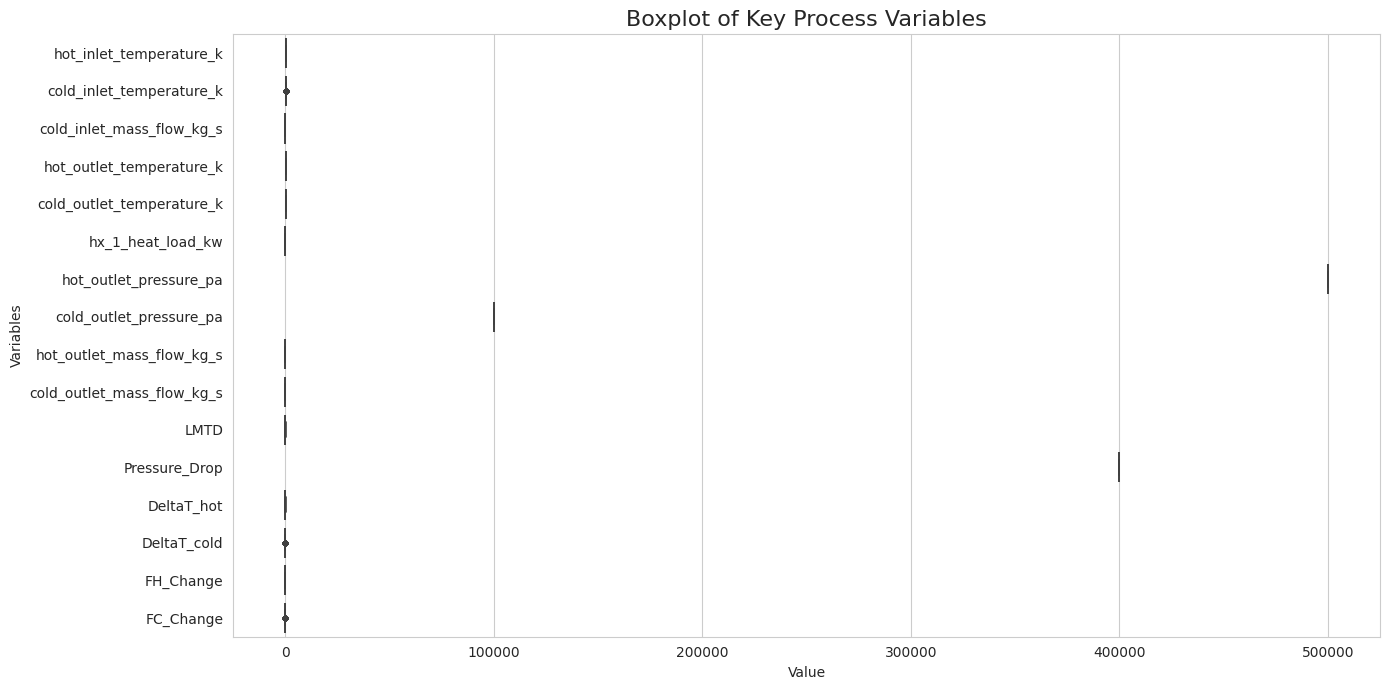

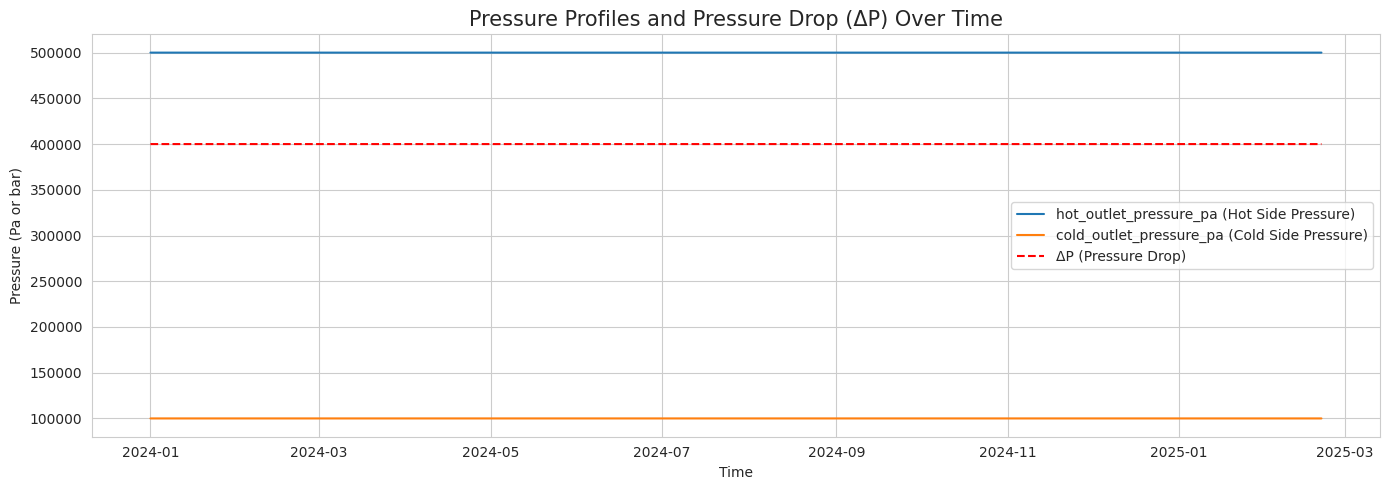

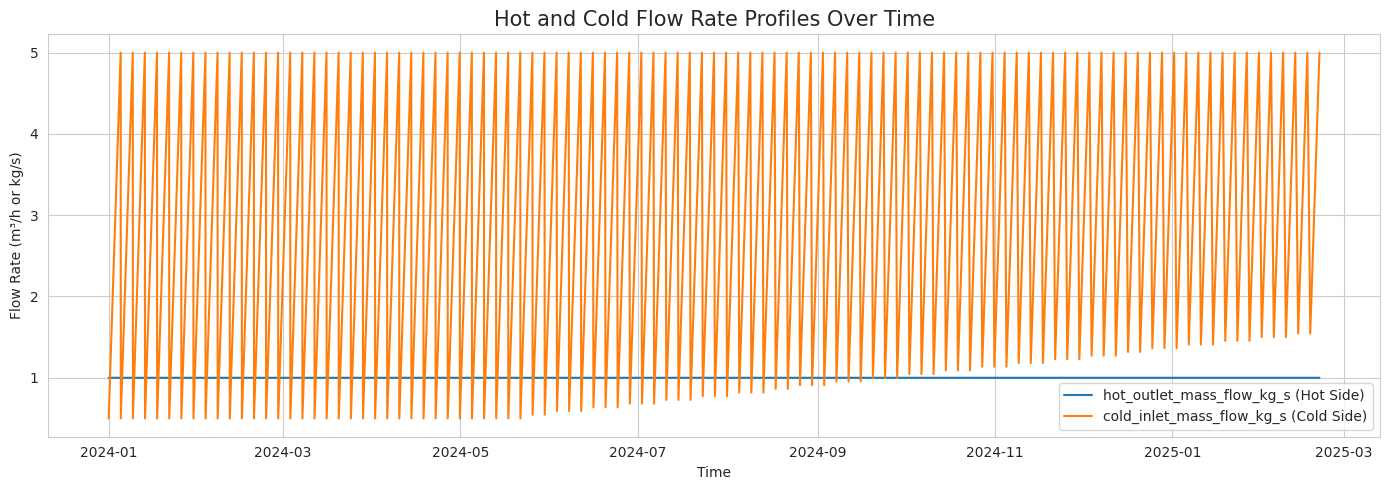

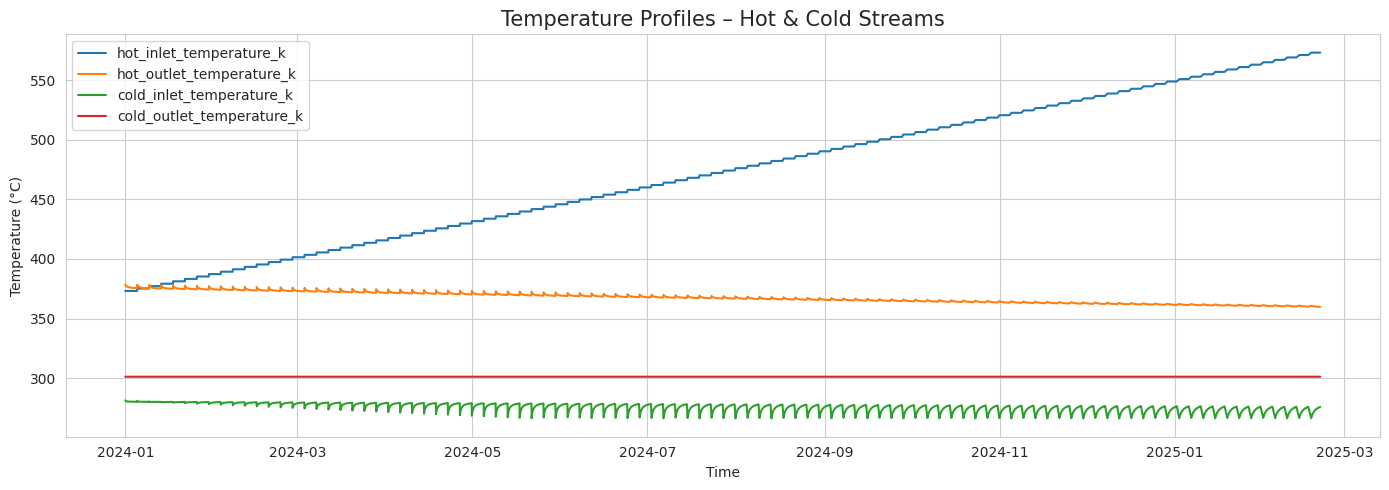

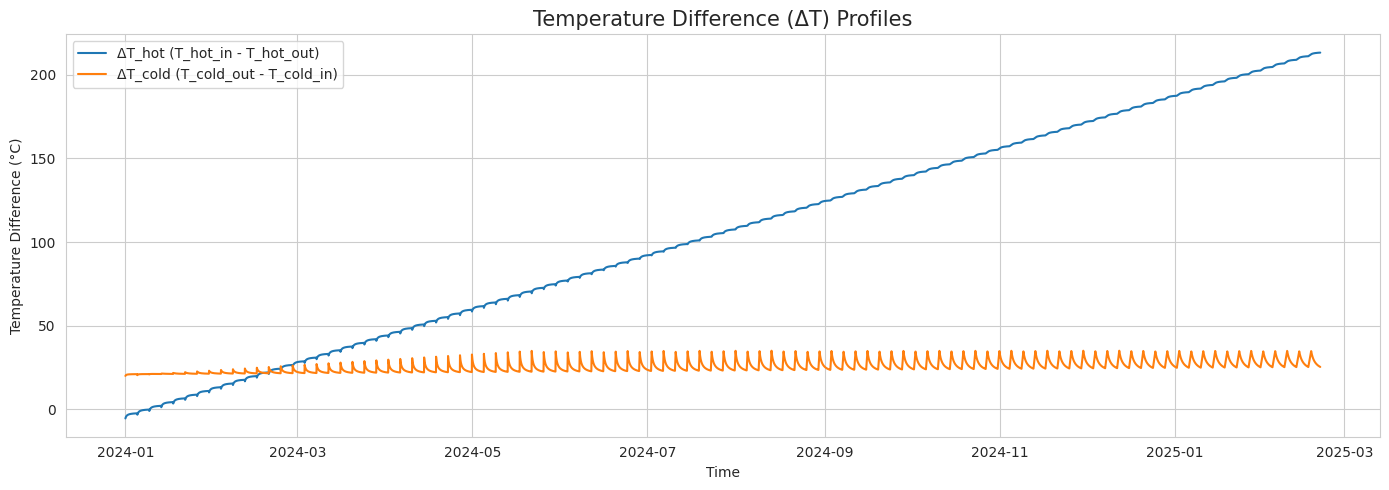

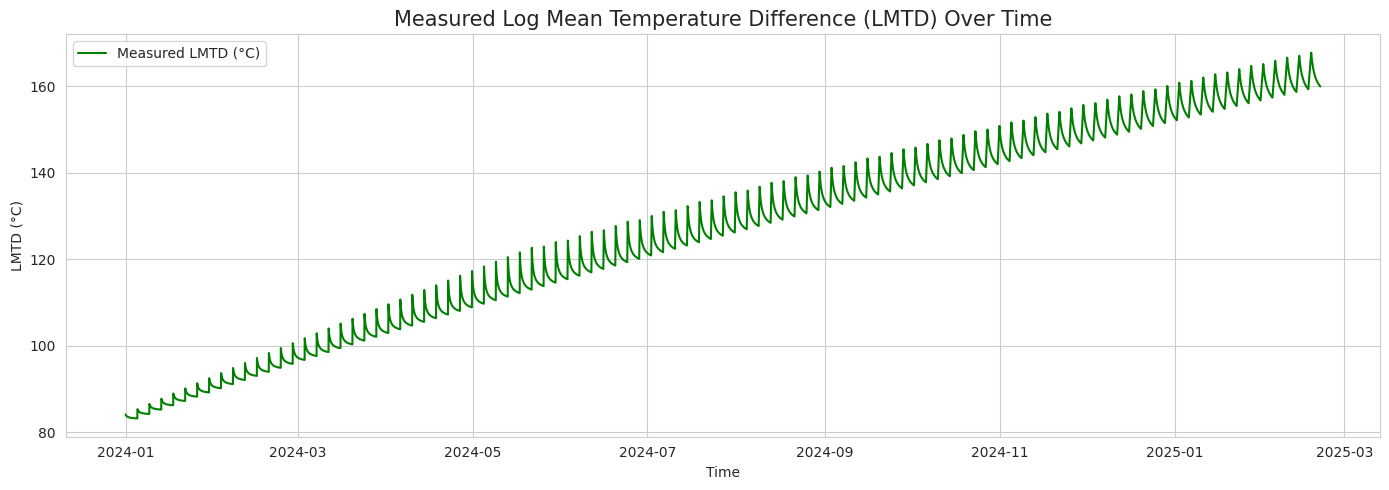

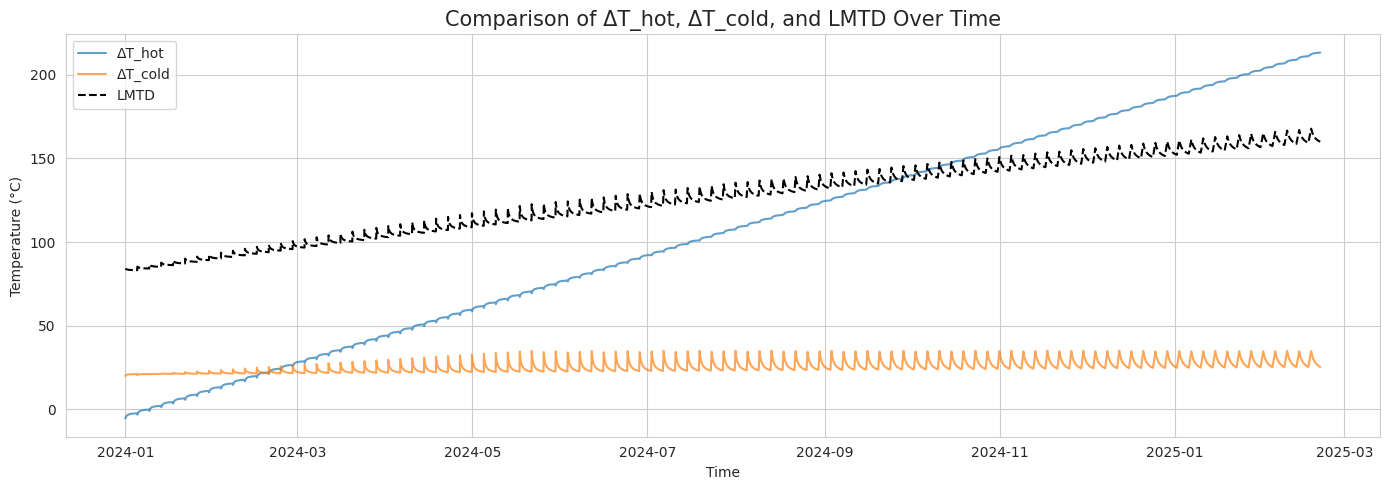

✅ Visualization Completed: Pressure, Flow, Temperature, ΔT, and LMTD plotted successfully.


In [ ]:
# ================================================================
# Visualization – Pressure, Flow, Temperature, ΔT, and LMTD
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14,5)

# -------------------- 6.1 Boxplot for numeric variables --------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14,7))
sns.boxplot(data=df[num_cols].fillna(0), orient="h", linewidth=1.2, fliersize=3)
plt.title("Boxplot of Key Process Variables", fontsize=16)
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# -------------------- 6.2 Pressure Profiles --------------------
plt.figure(figsize=(14,5))
if PH: plt.plot(df[time_col], df[PH], label=f"{PH} (Hot Side Pressure)")
if PC: plt.plot(df[time_col], df[PC], label=f"{PC} (Cold Side Pressure)")
plt.plot(df[time_col], df["Pressure_Drop"], 'r--', label='ΔP (Pressure Drop)')
plt.legend()
plt.title("Pressure Profiles and Pressure Drop (ΔP) Over Time", fontsize=15)
plt.xlabel("Time")
plt.ylabel("Pressure (Pa or bar)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------- 6.3 Flow Profiles --------------------
plt.figure(figsize=(14,5))
if FH: plt.plot(df[time_col], df[FH], label=f"{FH} (Hot Side)")
if FC: plt.plot(df[time_col], df[FC], label=f"{FC} (Cold Side)")
plt.legend()
plt.title("Hot and Cold Flow Rate Profiles Over Time", fontsize=15)
plt.xlabel("Time")
plt.ylabel("Flow Rate (m³/h or kg/s)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------- 6.4 Temperature Profiles --------------------
plt.figure(figsize=(14,5))
for t in [Th_in, Th_out, Tc_in, Tc_out]:
    if t in df.columns:
        plt.plot(df[time_col], df[t], label=t)
plt.legend()
plt.title("Temperature Profiles – Hot & Cold Streams", fontsize=15)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------- 6.5 Temperature Differences --------------------
if "DeltaT_hot" in df.columns and "DeltaT_cold" in df.columns:
    plt.figure(figsize=(14,5))
    plt.plot(df[time_col], df["DeltaT_hot"], label="ΔT_hot (T_hot_in - T_hot_out)")
    plt.plot(df[time_col], df["DeltaT_cold"], label="ΔT_cold (T_cold_out - T_cold_in)")
    plt.legend()
    plt.title("Temperature Difference (ΔT) Profiles", fontsize=15)
    plt.xlabel("Time")
    plt.ylabel("Temperature Difference (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------- 6.6 LMTD Variation (using inbuilt LMTD) --------------------
if "LMTD" in df.columns:
    plt.figure(figsize=(14,5))
    plt.plot(df[time_col], df["LMTD"], color='green', lw=1.5, label="Measured LMTD (°C)")
    plt.legend()
    plt.title("Measured Log Mean Temperature Difference (LMTD) Over Time", fontsize=15)
    plt.xlabel("Time")
    plt.ylabel("LMTD (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ LMTD column not found in dataset. Skipping LMTD plot.")

# -------------------- 6.7 Combined Overview (ΔT vs LMTD) --------------------
if all(c in df.columns for c in ["DeltaT_hot", "DeltaT_cold", "LMTD"]):
    plt.figure(figsize=(14,5))
    plt.plot(df[time_col], df["DeltaT_hot"], label="ΔT_hot", alpha=0.7)
    plt.plot(df[time_col], df["DeltaT_cold"], label="ΔT_cold", alpha=0.7)
    plt.plot(df[time_col], df["LMTD"], 'k--', label="LMTD")
    plt.legend()
    plt.title("Comparison of ΔT_hot, ΔT_cold, and LMTD Over Time", fontsize=15)
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("✅ Visualization Completed: Pressure, Flow, Temperature, ΔT, and LMTD plotted successfully.")

📊 Statistical Summary of Cleaned Dataset



,mean,std,min,max,25%,50%,75%,missing_%
Time,2024-07-17 17:37:22.290175744,NaN,2024-01-01 00:00:00,2025-02-20 15:00:00,2024-04-06 01:15:00,2024-07-12 12:30:00,2024-10-26 03:45:00,0.0
hot_inlet_temperature_k,468.434002,57.587841,373.15,573.15,419.615,466.079,516.584,0.0
cold_inlet_temperature_k,275.989398,3.145316,266.153458,281.2149,274.391552,276.582032,278.411137,0.0
cold_inlet_mass_flow_kg_s,2.912029,1.234642,0.5,5.0,1.86364,2.90909,3.95455,0.0
hot_outlet_temperature_k,367.899097,4.629296,359.837,378.649,363.91575,367.7755,371.78425,0.0
cold_outlet_temperature_k,301.151,0.0,301.151,301.151,301.151,301.151,301.151,0.0
hx_1_heat_load_kw,106.704823,19.488113,61.3959,140.618,90.354125,107.2375,123.475,0.0
hot_outlet_pressure_pa,500000.0,0.0,500000.0,500000.0,500000.0,500000.0,500000.0,0.0
cold_outlet_pressure_pa,100000.0,0.0,100000.0,100000.0,100000.0,100000.0,100000.0,0.0
hot_outlet_mass_flow_kg_s,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0


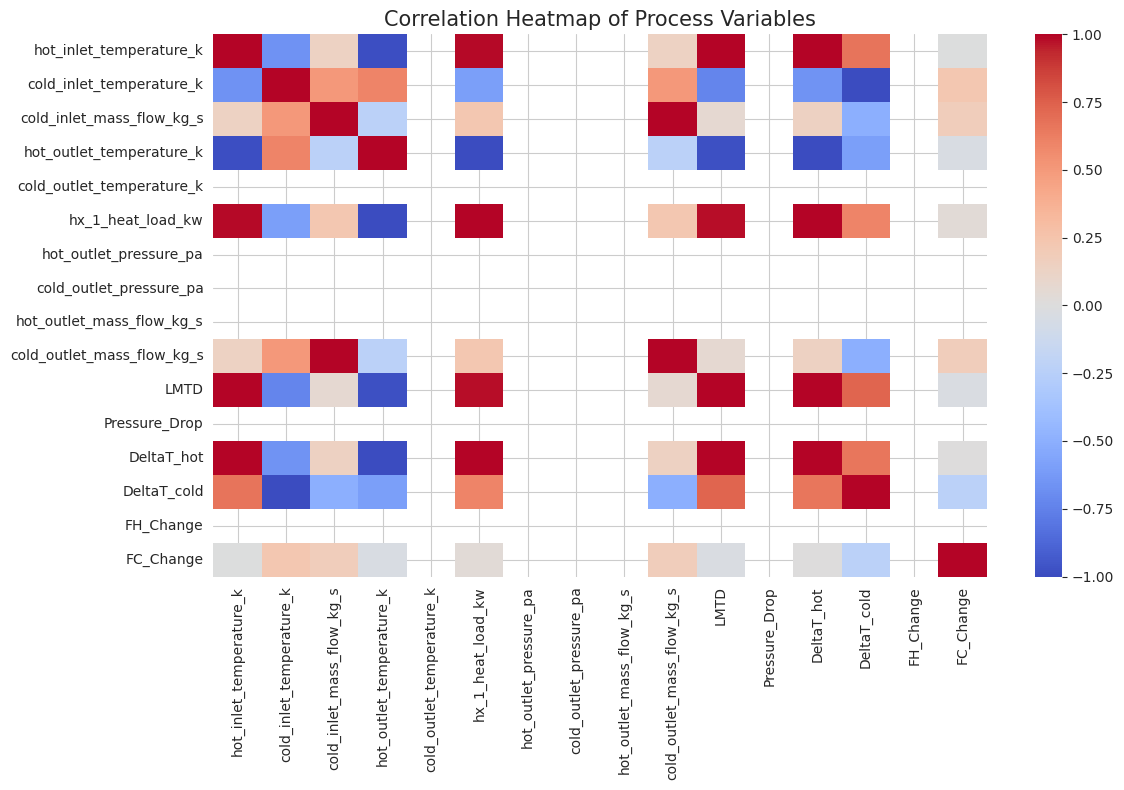


✅ Cleaned dataset saved successfully as: clean_he_data.csv

📁 The cleaned dataset is ready for next steps (EDA, PCA, Health Index, Fault Detection).


In [ ]:
# ================================================================
#  Statistical Summary & Save Cleaned Dataset
# ================================================================

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------- 7.1 Descriptive statistics --------------------
print("📊 Statistical Summary of Cleaned Dataset\n")
summary = df.describe().T
summary["missing_%"] = df.isna().mean() * 100
summary = summary[["mean", "std", "min", "max","25%", "50%","75%", "missing_%"]]
display(summary.round(4))

# -------------------- 7.2 Correlation matrix (heatmap) --------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=False, cbar=True)
plt.title("Correlation Heatmap of Process Variables", fontsize=15)
plt.tight_layout()
plt.show()

# -------------------- 7.3 Save cleaned dataset --------------------
cleaned_path = "clean_he_data.csv"
df.to_csv(cleaned_path, index=False)
print(f"\n✅ Cleaned dataset saved successfully as: {cleaned_path}")

print("\n📁 The cleaned dataset is ready for next steps (EDA, PCA, Health Index, Fault Detection).")


✅ Dataset loaded: (9222, 17)
✅ Realistic fault simulation complete.
Condition
Normal           6455
Fouling          1383
Leakage           738
Flow_Blockage     646
Name: count, dtype: int64


/tmp/ipython-input-3957813791.py:30: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z = np.abs(zscore(df[cols_for_zscore]))
/tmp/ipython-input-3957813791.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85
 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85
 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85
 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85
 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85
 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85
 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85
 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85 0.85
 0.85 0.85 0.85 

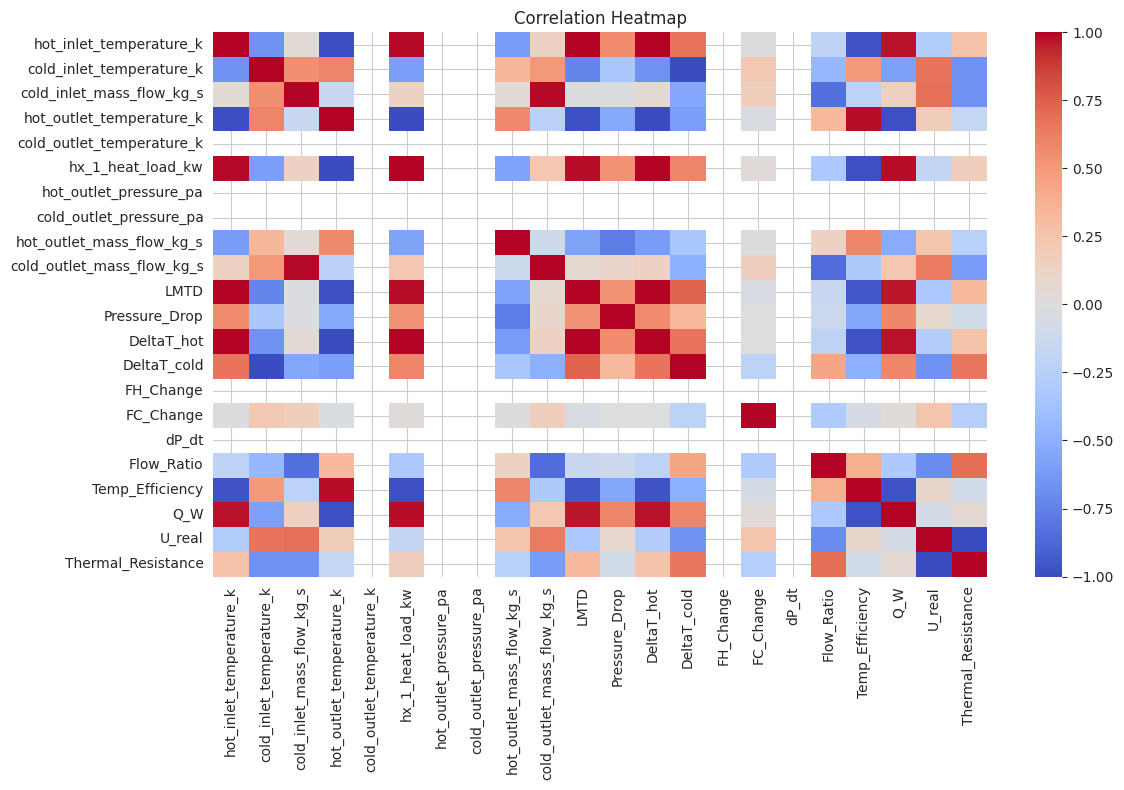

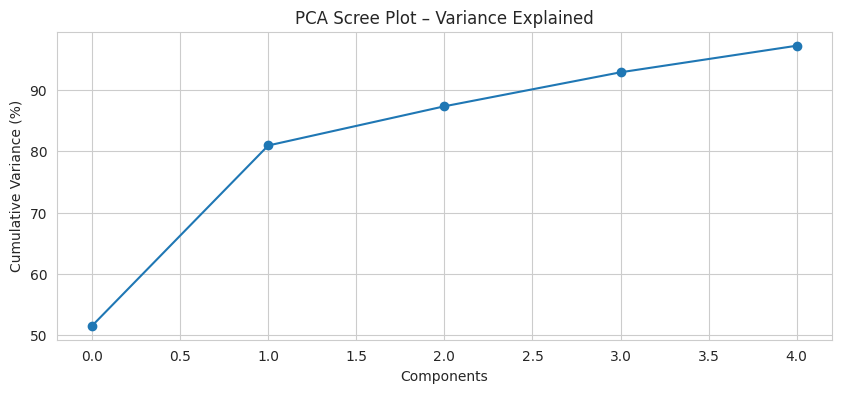

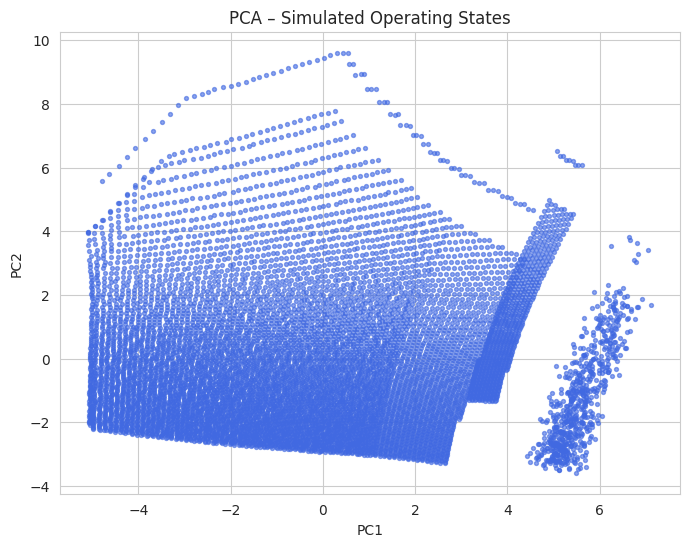

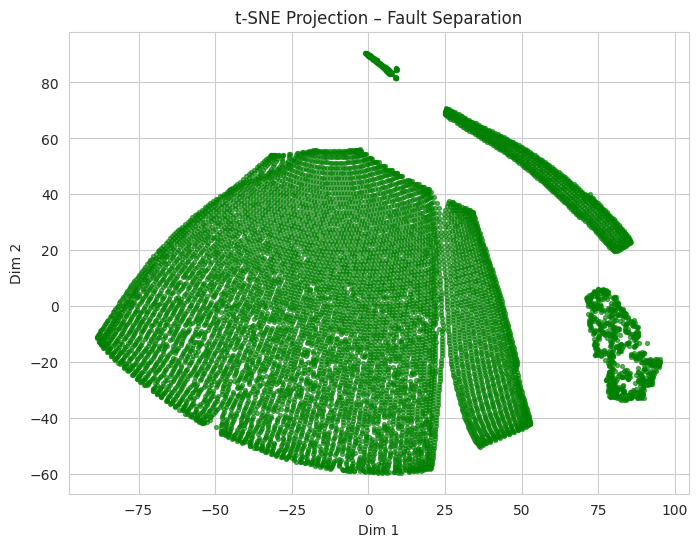

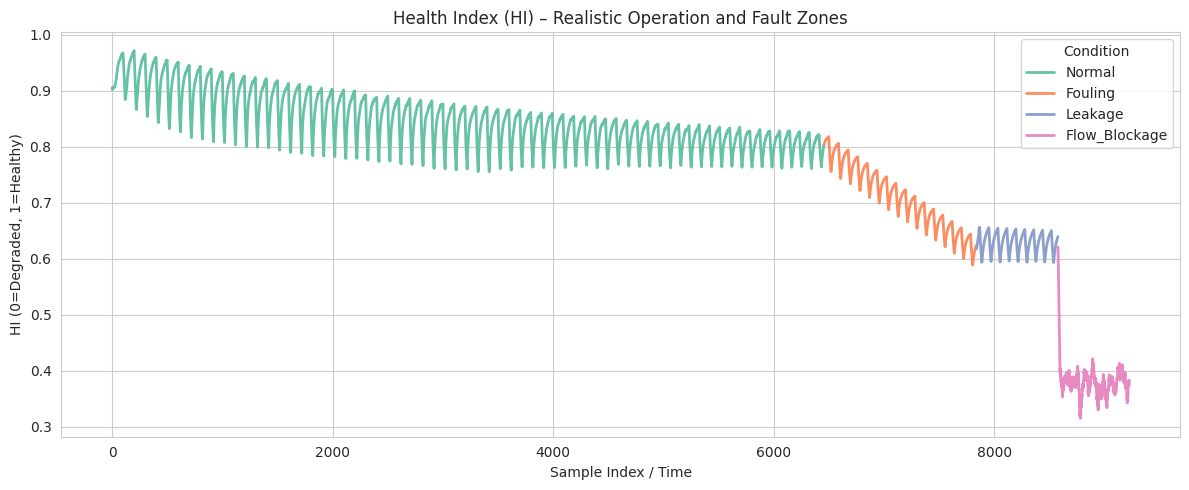

🔍 Starting condition-wise outlier cleaning...
Condition Normal: Removed 31 outliers in Pressure_Drop
Condition Normal: Removed 437 outliers in Thermal_Resistance
Condition Normal: Removed 230 outliers in Flow_Ratio
Condition Normal: Removed 131 outliers in U_real
Condition Fouling: Removed 36 outliers in Thermal_Resistance
Condition Fouling: Removed 18 outliers in Temp_Efficiency
Condition Fouling: Removed 23 outliers in Flow_Ratio
Condition Fouling: Removed 3 outliers in U_real
Condition Leakage: Removed 1 outliers in Pressure_Drop
Condition Leakage: Removed 5 outliers in Thermal_Resistance
Condition Leakage: Removed 4 outliers in Temp_Efficiency
Condition Leakage: Removed 2 outliers in Flow_Ratio
Condition Leakage: Removed 4 outliers in Health_Index
Condition Flow_Blockage: Removed 2 outliers in Thermal_Resistance
Condition Flow_Blockage: Removed 12 outliers in Temp_Efficiency
Condition Flow_Blockage: Removed 2 outliers in Flow_Ratio
✅ Outlier cleaning complete.
Final cleaned dataset

/tmp/ipython-input-3957813791.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df_clean, palette="Set2")


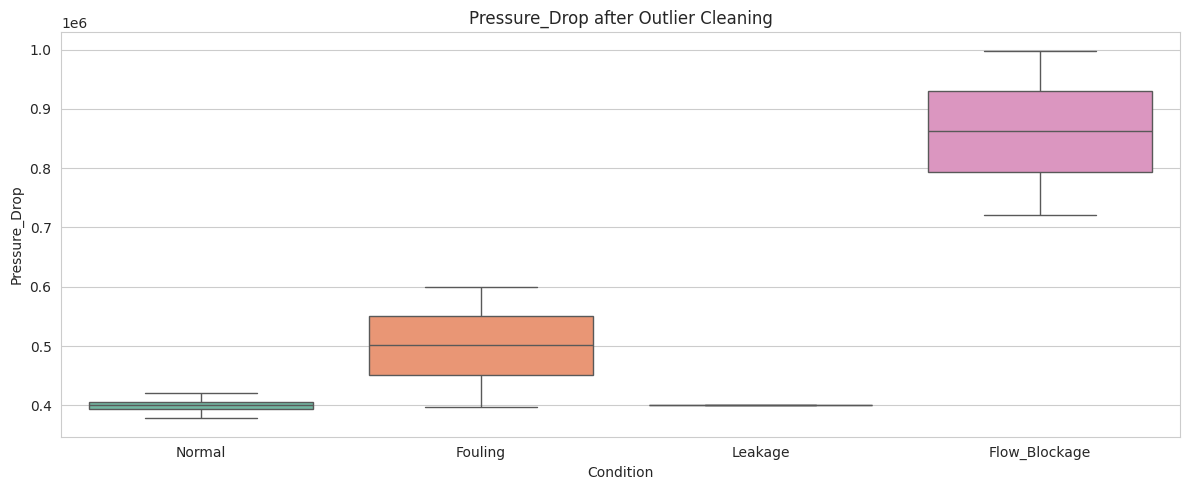

/tmp/ipython-input-3957813791.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df_clean, palette="Set2")


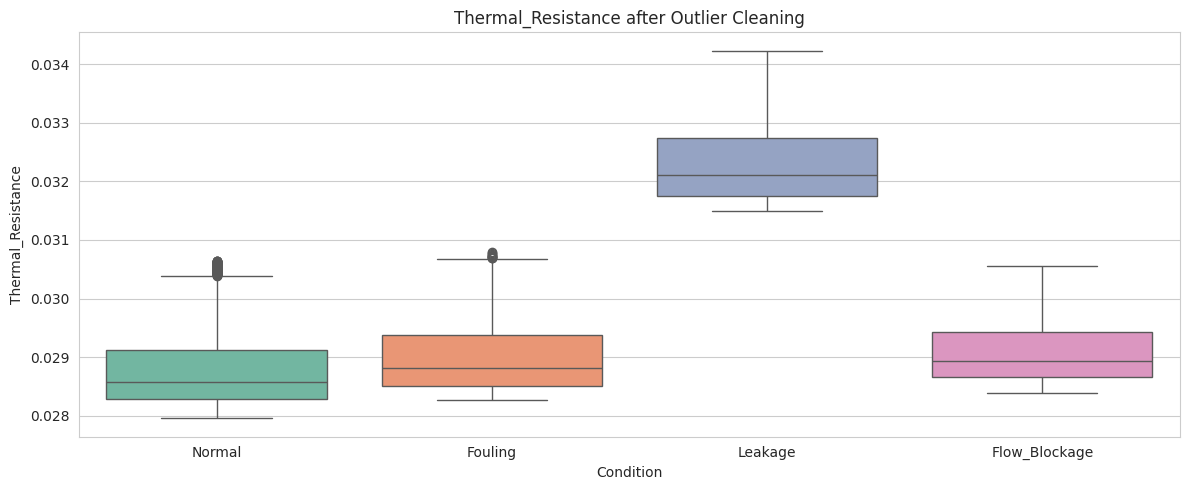

/tmp/ipython-input-3957813791.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df_clean, palette="Set2")


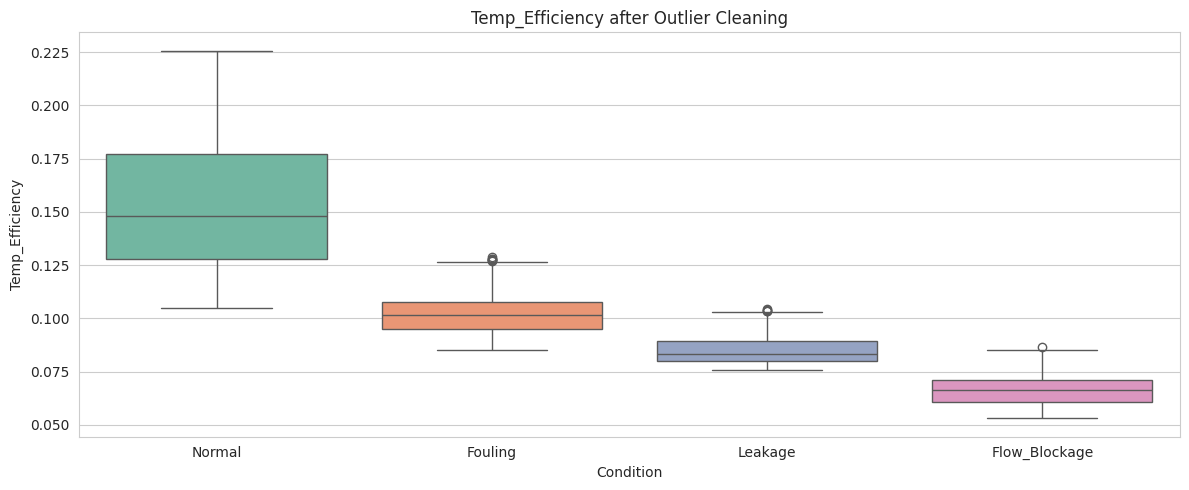

/tmp/ipython-input-3957813791.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df_clean, palette="Set2")


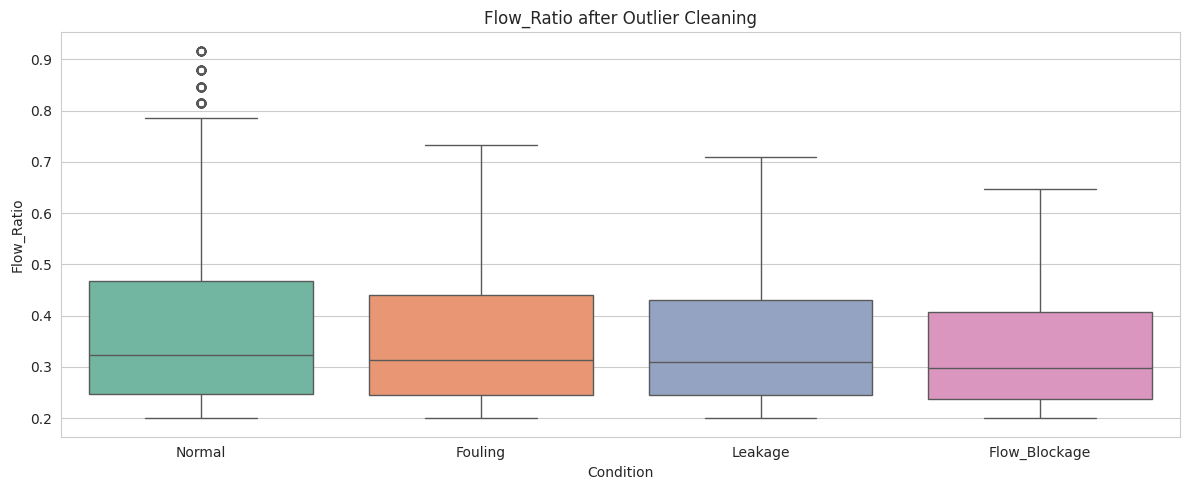

/tmp/ipython-input-3957813791.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df_clean, palette="Set2")


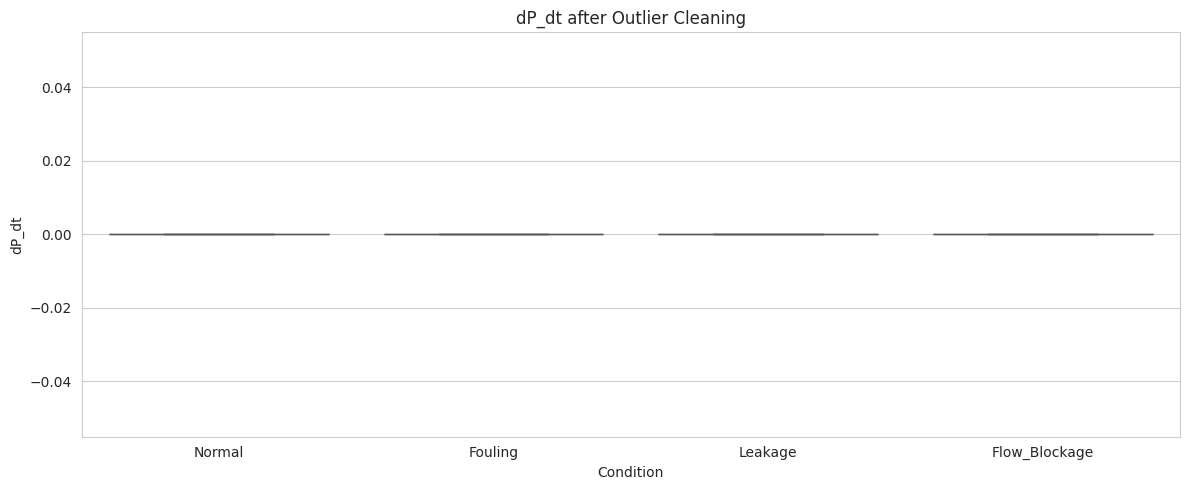

/tmp/ipython-input-3957813791.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df_clean, palette="Set2")


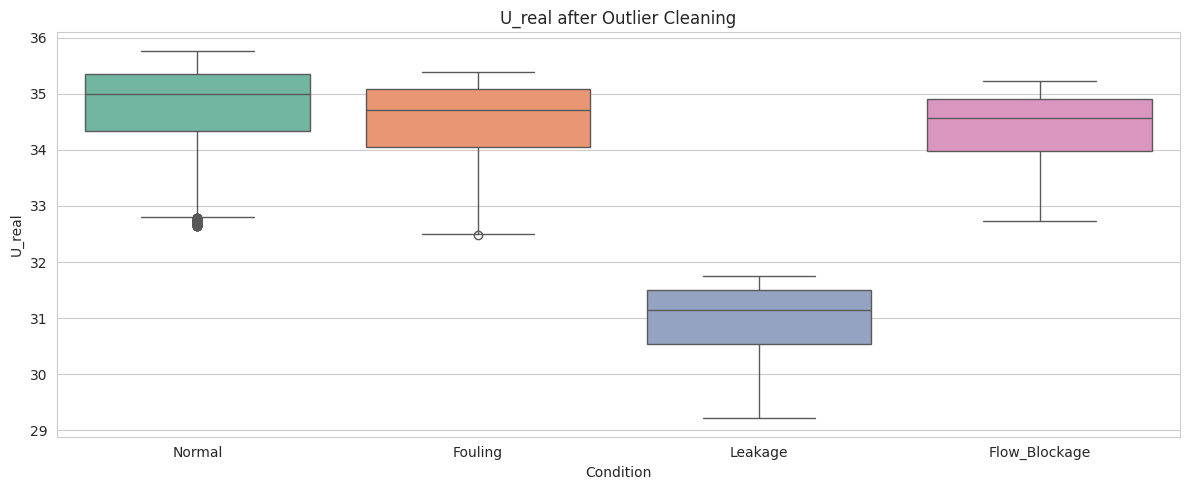

/tmp/ipython-input-3957813791.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df_clean, palette="Set2")


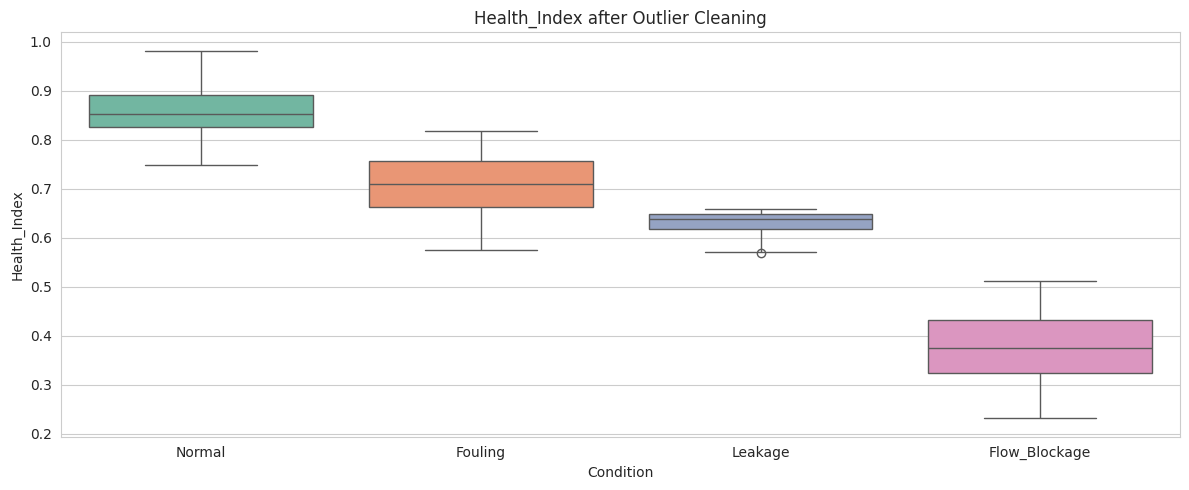

,Pressure_Drop,Thermal_Resistance,Temp_Efficiency,Health_Index
Condition,,,,
Flow_Blockage,861379.9853,0.0291,0.0671,0.3769
Fouling,499925.4110,0.0291,0.1037,0.7074
Leakage,400271.0027,0.0324,0.0856,0.6295
Normal,399875.0221,0.0292,0.1574,0.8484


/tmp/ipython-input-3957813791.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")


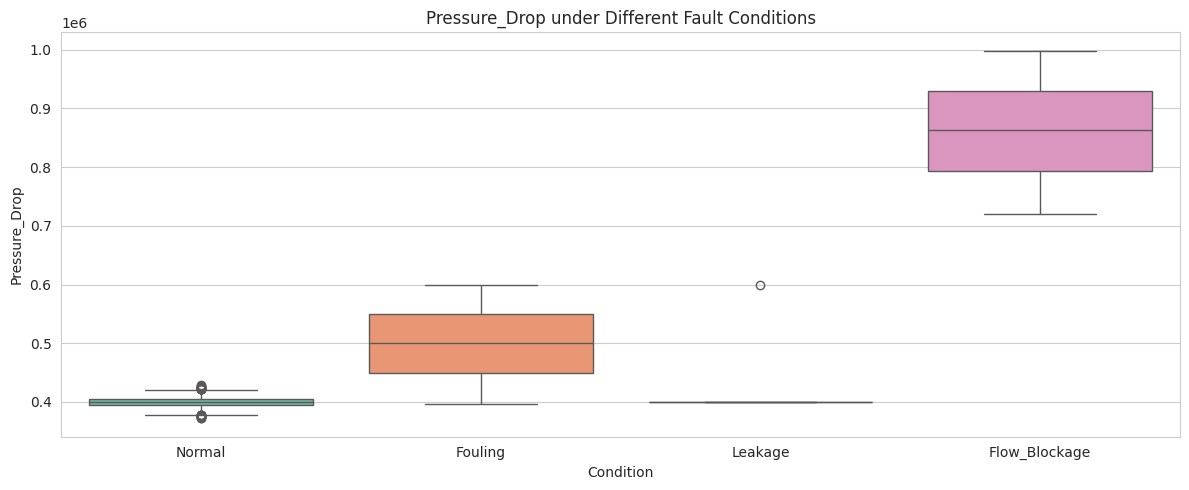

/tmp/ipython-input-3957813791.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")


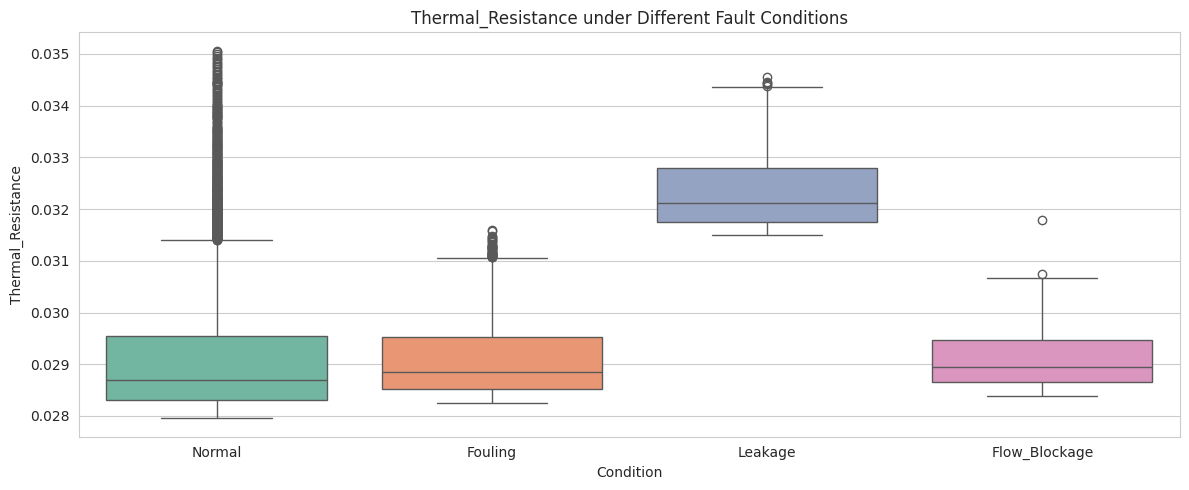

/tmp/ipython-input-3957813791.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")


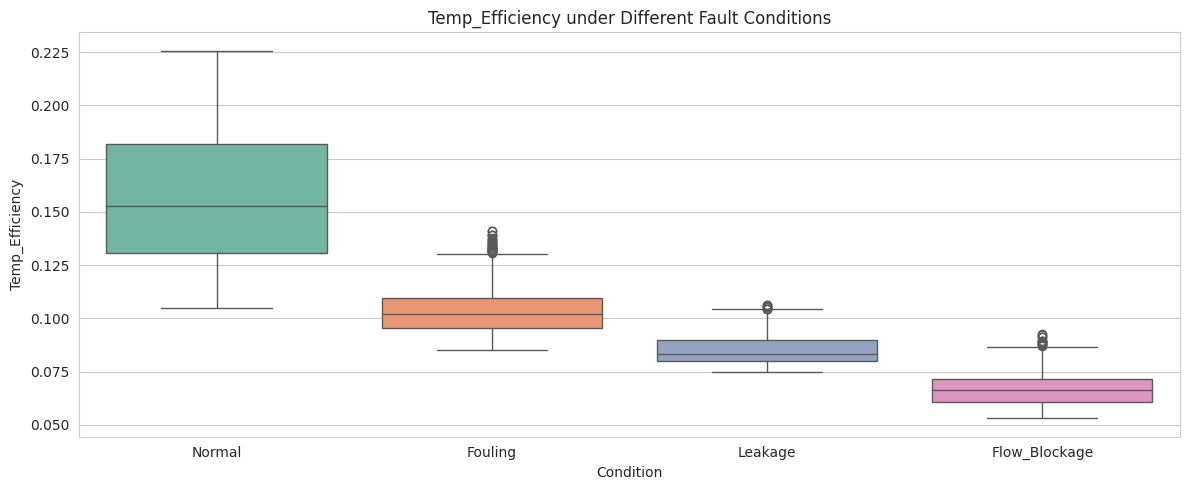

/tmp/ipython-input-3957813791.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")


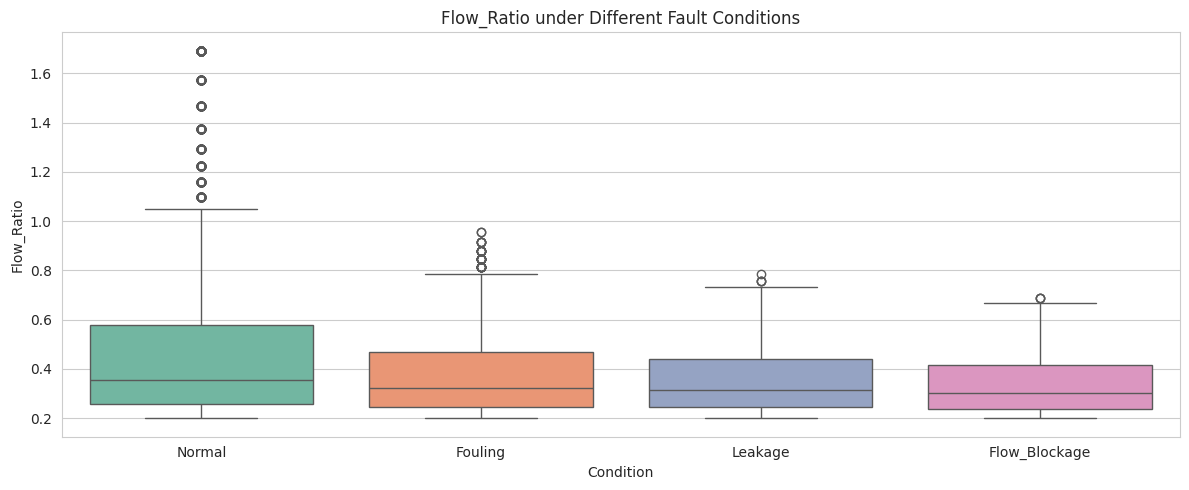

/tmp/ipython-input-3957813791.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")


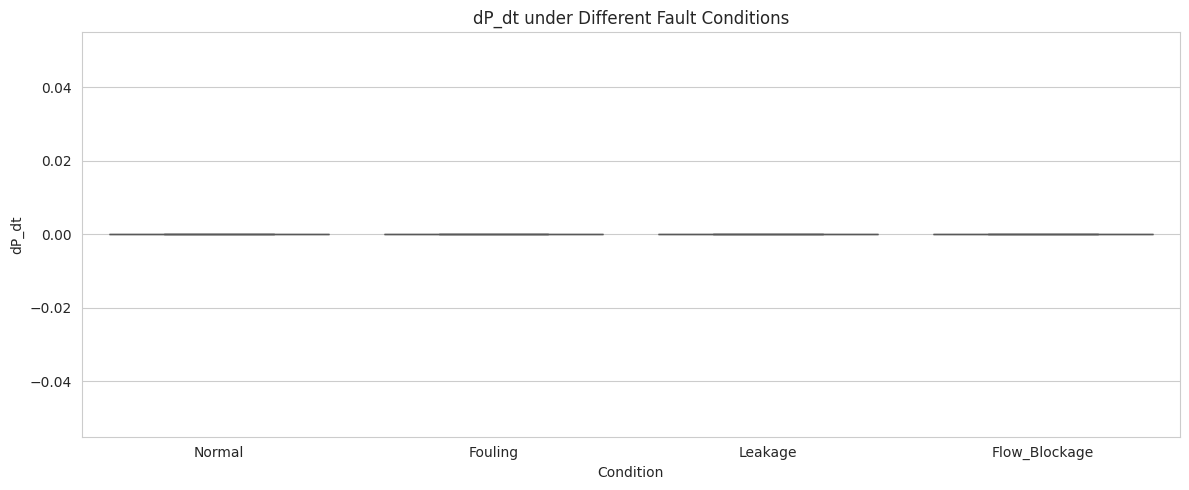

/tmp/ipython-input-3957813791.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")


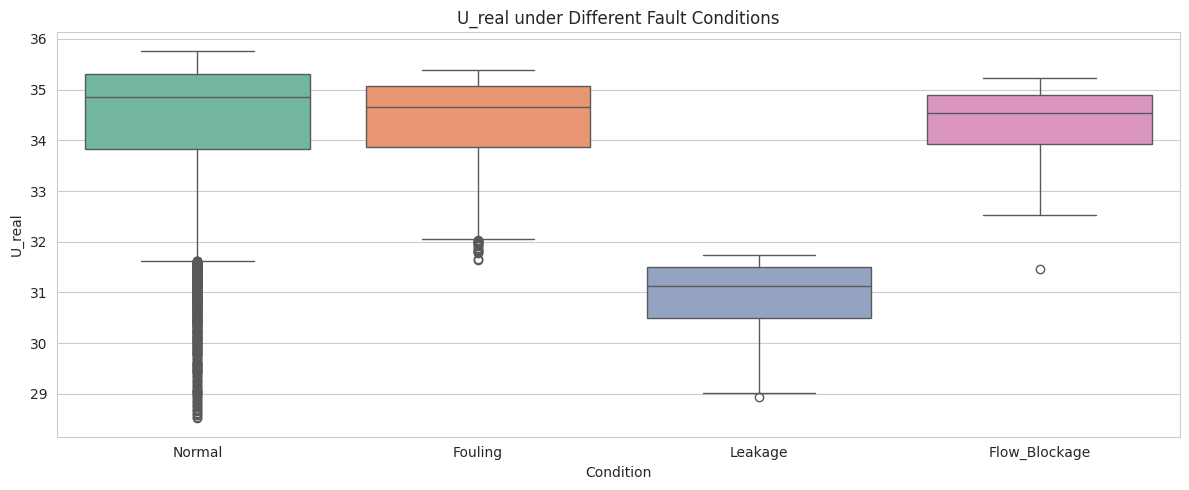

/tmp/ipython-input-3957813791.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")


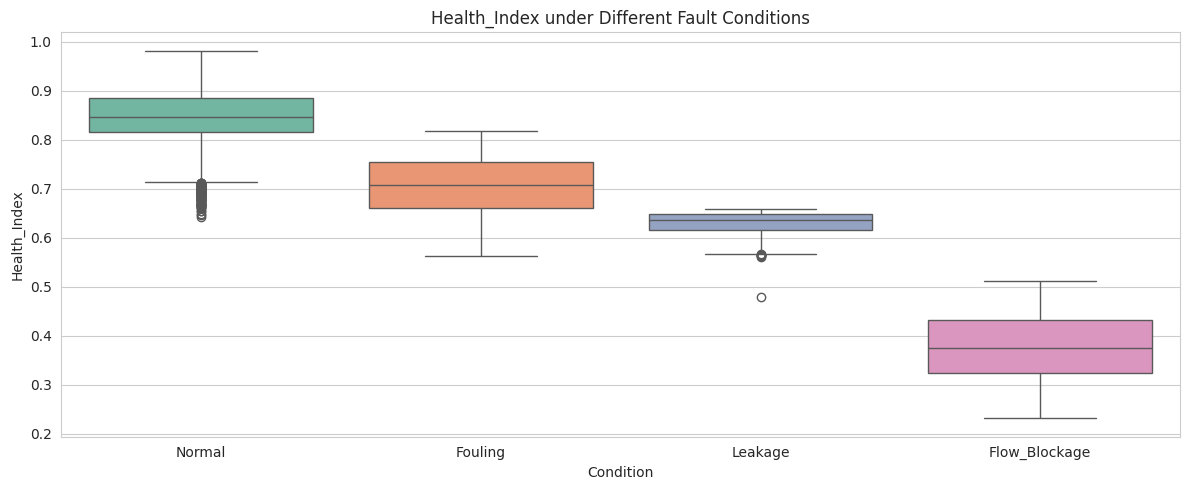

/tmp/ipython-input-3957813791.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")


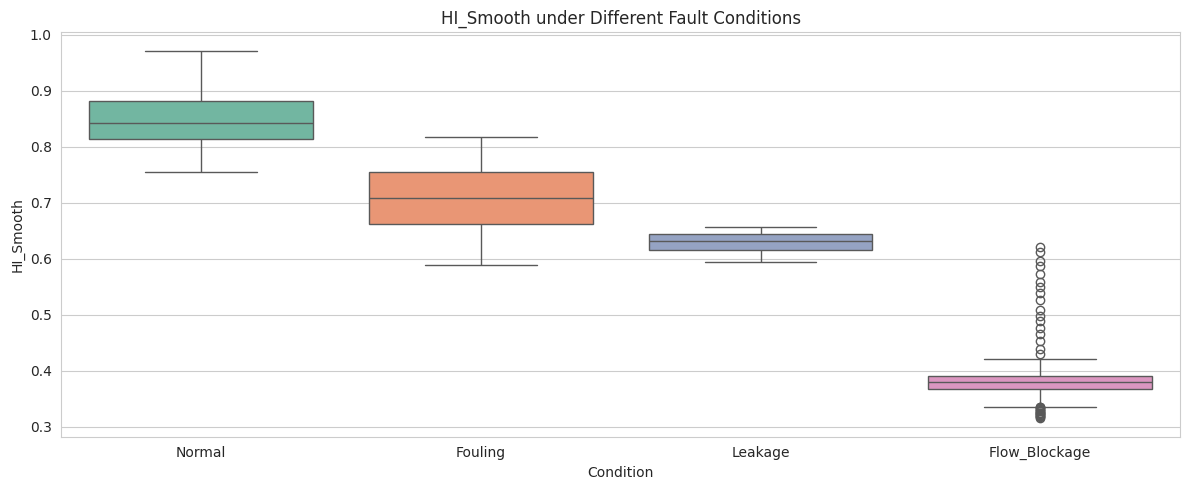

 Final realistic physics-informed dataset saved → clean_he_data.csv
Columns saved: ['Time', 'hot_inlet_temperature_k', 'cold_inlet_temperature_k', 'cold_inlet_mass_flow_kg_s', 'hot_outlet_temperature_k', 'cold_outlet_temperature_k', 'hx_1_heat_load_kw', 'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa', 'hot_outlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s', 'LMTD', 'Pressure_Drop', 'DeltaT_hot', 'DeltaT_cold', 'FH_Change', 'FC_Change', 'dP_dt', 'Flow_Ratio', 'Temp_Efficiency', 'Q_W', 'U_real', 'Thermal_Resistance', 'Condition', 'Pressure_Drop_norm', 'Thermal_Resistance_norm', 'Temp_Efficiency_norm', 'Health_Index', 'HI_Smooth']
Condition class counts:
 Condition
Normal           6455
Fouling          1383
Leakage           738
Flow_Blockage     646
Name: count, dtype: int64
✅ Step 2 Completed – Physics-based fault simulation, EDA, PCA & Health Index


In [ ]:
# ================================================================
# Realistic Physics-Informed Fault Simulation + EDA + SAVE
# ================================================================

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import zscore

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

# ---------------------------------------------------------------
# 2.1 Load Base Dataset
# ---------------------------------------------------------------
# df = pd.read_csv("clean_he_data.csv") # Use the df from previous steps
print("✅ Dataset loaded:", df.shape)

# ---------------------------------------------------------------
# 2.2 Outlier Detection & Clipping
# ---------------------------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns
# Identify columns with zero standard deviation
zero_std_cols = num_cols[df[num_cols].std() == 0]
# Exclude columns with zero standard deviation from z-score calculation
cols_for_zscore = num_cols.difference(zero_std_cols)

# Calculate z-scores only for columns with non-zero standard deviation
z = np.abs(zscore(df[cols_for_zscore]))

# Apply clipping to all numerical columns (including those with zero std)
df[num_cols] = df[num_cols].clip(df[num_cols].quantile(0.01),
                                 df[num_cols].quantile(0.99),
                                 axis=1)

# ---------------------------------------------------------------
# 2.3 Feature Engineering
# ---------------------------------------------------------------
df["dP_dt"] = df["Pressure_Drop"].diff().fillna(0)
# Use the variable names for column access
df["Flow_Ratio"] = df[FH] / (df[FC] + 1e-6)
df["Temp_Efficiency"] = (df[Tc_out] - df[Tc_in]) / (
                         (df[Th_in] - df[Tc_in]) + 1e-6)

A = 25.0
# Use the correct column name for heat load
df["Q_W"] = df["hx_1_heat_load_kw"] * 1000
df["U_real"] = df["Q_W"] / ((A * df["LMTD"]) + 1e-6)
df["Thermal_Resistance"] = 1 / (df["U_real"] + 1e-6)

# ---------------------------------------------------------------
# 2.4 Realistic Fault Distribution
# ---------------------------------------------------------------
N = len(df)
normal   = slice(0, int(0.70*N))   # 70% Normal
fouling  = slice(int(0.70*N), int(0.85*N))  # 15% Fouling
leakage  = slice(int(0.85*N), int(0.93*N))  # 8% Leakage
blockage = slice(int(0.93*N), N)             # 7% Blockage

# ---------------------------------------------------------------
# 2.5 Physics-Informed Behavior by Fault Type
# ---------------------------------------------------------------
# Normal – stable with mild noise
df.loc[normal, "Pressure_Drop"] = df.loc[normal, "Pressure_Drop"].astype(float) * np.random.normal(1.0, 0.02, len(df.loc[normal]))
df.loc[normal, "U_real"] = df.loc[normal, "U_real"].astype(float) * np.random.normal(1.0, 0.02, len(df.loc[normal]))

# Fouling – ΔP↑ slowly, U↓ gradually, efficiency↓
df.loc[fouling, "Pressure_Drop"] = df.loc[fouling, "Pressure_Drop"].astype(float) * np.linspace(1.0, 1.5, len(df.loc[fouling]))
df.loc[fouling, "U_real"] = df.loc[fouling, "U_real"].astype(float) * np.linspace(1.0, 0.8, len(df.loc[fouling]))
df.loc[fouling, "Temp_Efficiency"] = df.loc[fouling, "Temp_Efficiency"].astype(float) * np.linspace(1.0, 0.9, len(df.loc[fouling]))

# Leakage – ΔT↓, Flow↓, Heat duty↓
df.loc[leakage, FH] = df.loc[leakage, FH].astype(float) * 0.85
df.loc[leakage, FC] = df.loc[leakage, FC].astype(float) * 0.9
df.loc[leakage, "Temp_Efficiency"] = df.loc[leakage, "Temp_Efficiency"].astype(float) * 0.85
df.loc[leakage, "Q_W"] = df.loc[leakage, "Q_W"].astype(float) * 0.9


# Flow Blockage – ΔP↑↑, Flow↓↓, Efficiency↓↓
df.loc[blockage, "Pressure_Drop"] = df.loc[blockage, "Pressure_Drop"].astype(float) * np.random.uniform(1.8, 2.5, len(df.loc[blockage]))
df.loc[blockage, FH] = df.loc[blockage, FH].astype(float) * np.random.uniform(0.6, 0.8, len(df.loc[blockage]))
df.loc[blockage, FC] = df.loc[blockage, FC].astype(float) * np.random.uniform(0.7, 0.9, len(df.loc[blockage]))
df.loc[blockage, "Temp_Efficiency"] = df.loc[blockage, "Temp_Efficiency"].astype(float) * np.random.uniform(0.6, 0.8, len(df.loc[blockage]))


# Recalculate U and R after modifications
df["U_real"] = df["Q_W"] / ((A * df["LMTD"]) + 1e-6)
df["Thermal_Resistance"] = 1 / (df["U_real"] + 1e-6)

# Add Condition labels
df["Condition"] = "Normal"
df.loc[fouling, "Condition"]  = "Fouling"
df.loc[leakage, "Condition"]  = "Leakage"
df.loc[blockage, "Condition"] = "Flow_Blockage"

print("✅ Realistic fault simulation complete.")
print(df["Condition"].value_counts())

# ---------------------------------------------------------------
# 2.6 Correlation Heatmap
# ---------------------------------------------------------------
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 2.7 PCA (Principal Component Analysis)
# ---------------------------------------------------------------
scaler = StandardScaler()
scaled = scaler.fit_transform(df.select_dtypes(include=[np.number]).fillna(0))
pca = PCA(n_components=0.95)
pcs = pca.fit_transform(scaled)
pca_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(pcs.shape[1])])

plt.figure(figsize=(10,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o')
plt.title("PCA Scree Plot – Variance Explained")
plt.xlabel("Components"); plt.ylabel("Cumulative Variance (%)")
plt.grid(True); plt.show()

plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c='royalblue', s=8, alpha=0.6)
plt.title("PCA – Simulated Operating States")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True); plt.show()

# ---------------------------------------------------------------
# 2.8 t-SNE Non-Linear Projection
# ---------------------------------------------------------------
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
tsne_data = tsne.fit_transform(scaled)
plt.figure(figsize=(8,6))
plt.scatter(tsne_data[:,0], tsne_data[:,1], c='green', s=8, alpha=0.6)
plt.title("t-SNE Projection – Fault Separation")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2"); plt.grid(True); plt.show()
# ---------------------------------------------------------------
# 2.9 Compute Physics-Based Health Index
# ---------------------------------------------------------------
for c in ["Pressure_Drop","Thermal_Resistance","Temp_Efficiency"]:
    df[c+"_norm"] = (df[c]-df[c].min())/(df[c].max()-df[c].min()+1e-6)

w = np.array([0.5,0.3,0.2])
df["Health_Index"] = 1 - (w[0]*df["Pressure_Drop_norm"] +
                          w[1]*df["Thermal_Resistance_norm"] +
                          w[2]*(1-df["Temp_Efficiency_norm"]))
df["HI_Smooth"] = df["Health_Index"].rolling(window=20,min_periods=1).mean()

plt.figure(figsize=(12,5))
sns.lineplot(x=np.arange(len(df)), y=df["HI_Smooth"], hue=df["Condition"], palette="Set2", lw=2)
plt.title("Health Index (HI) – Realistic Operation and Fault Zones")
plt.xlabel("Sample Index / Time"); plt.ylabel("HI (0=Degraded, 1=Healthy)")
plt.legend(title="Condition"); plt.grid(True); plt.tight_layout(); plt.show()

# ================================================================
# 2.10 – Robust Outlier Removal (Condition-wise)
# ================================================================

print("🔍 Starting condition-wise outlier cleaning...")

clean_df = []

# Columns to clean → all key physics parameters
clean_cols = [
    "Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
    "Flow_Ratio", "dP_dt", "U_real", "Health_Index"
]

# Loop for each condition (Normal / Fouling / Leakage / Blockage)
for cond in df["Condition"].unique():
    block = df[df["Condition"] == cond].copy()

    for col in clean_cols:
        # Skip if column not found
        if col not in block.columns:
            continue

        series = block[col]

        # ---- 1) IQR Filter (removes hard spikes) ----
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1

        lower_iqr = Q1 - 1.5 * IQR
        upper_iqr = Q3 + 1.5 * IQR

        # ---- 2) Z-score Filter (removes global anomalies) ----
        z = (series - series.mean()) / (series.std() + 1e-6)
        z_limit = 3   # more strict for physics variables

        # ---- Final mask ----
        mask = (series >= lower_iqr) & (series <= upper_iqr) & (np.abs(z) <= z_limit)

        removed = len(block) - mask.sum()
        if removed > 0:
            print(f"Condition {cond}: Removed {removed} outliers in {col}")

        block = block[mask]

    clean_df.append(block)

# Merge cleaned blocks
df_clean = pd.concat(clean_df).reset_index(drop=True)

print("✅ Outlier cleaning complete.")
print("Final cleaned dataset shape:", df_clean.shape)

# plots

for feat in clean_cols:
    plt.figure(figsize=(12,5))
    sns.boxplot(x="Condition", y=feat, data=df_clean, palette="Set2")
    plt.title(f"{feat} after Outlier Cleaning")
    plt.tight_layout(); plt.show()
# ---------------------------------------------------------------
# 2.11 Summary Statistics and Feature Comparison
# ---------------------------------------------------------------
summary_cols = ["Pressure_Drop","Thermal_Resistance","Temp_Efficiency","Health_Index"]
display(df.groupby("Condition")[summary_cols].mean().round(4))

# Add all relevant features to the list for boxplots
features_to_plot = ["Pressure_Drop","Thermal_Resistance","Temp_Efficiency","Flow_Ratio", "dP_dt", "U_real", "Health_Index", "HI_Smooth"]

for feat in features_to_plot:
    plt.figure(figsize=(12,5))
    sns.boxplot(x="Condition", y=feat, data=df, palette="Set2")
    plt.title(f"{feat} under Different Fault Conditions")
    plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# 2.11 Save Updated Dataset
# ---------------------------------------------------------------
output_path = "clean_he_data.csv"
df.to_csv(output_path, index=False)
print(f" Final realistic physics-informed dataset saved → {output_path}")
print("Columns saved:", df.columns.tolist())
print("Condition class counts:\n", df["Condition"].value_counts())

print("✅ Step 2 Completed – Physics-based fault simulation, EDA, PCA & Health Index")

<Figure size 1200x600 with 0 Axes>

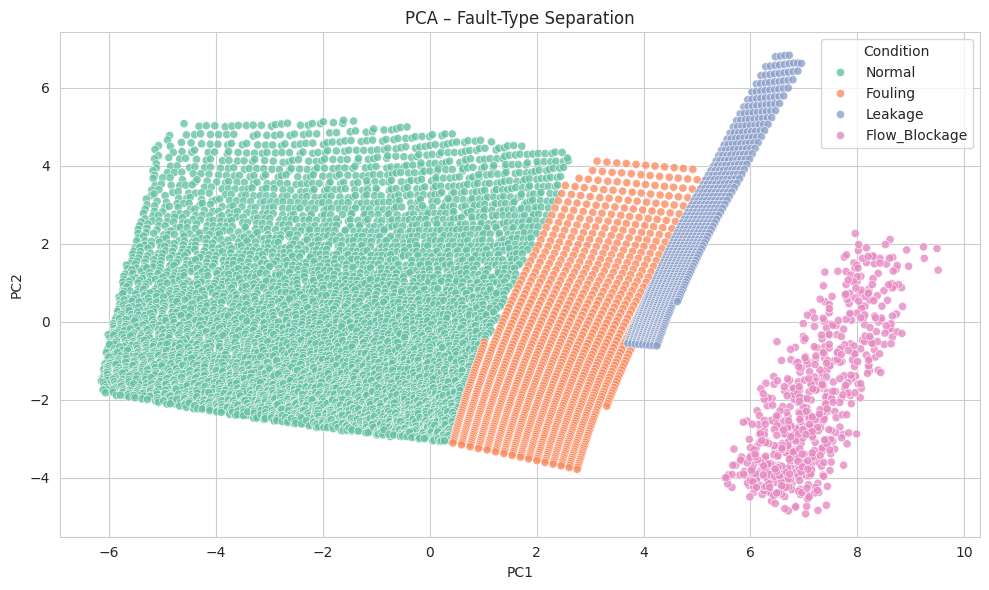

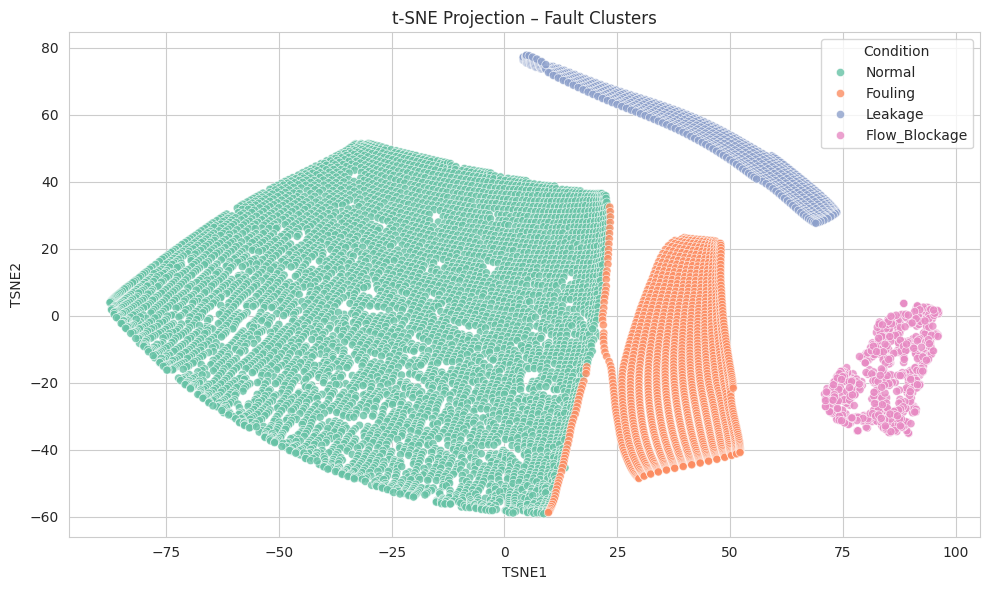

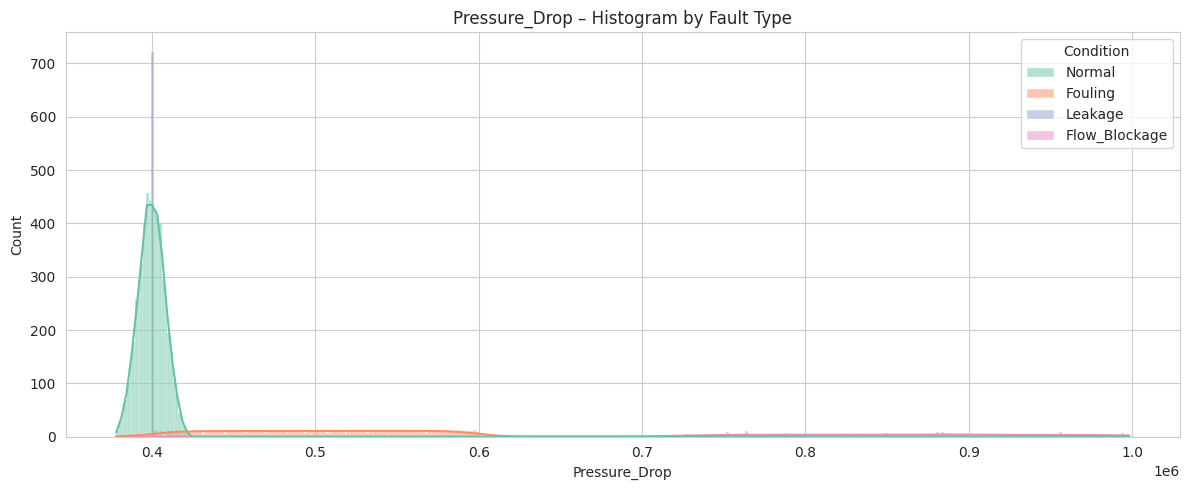

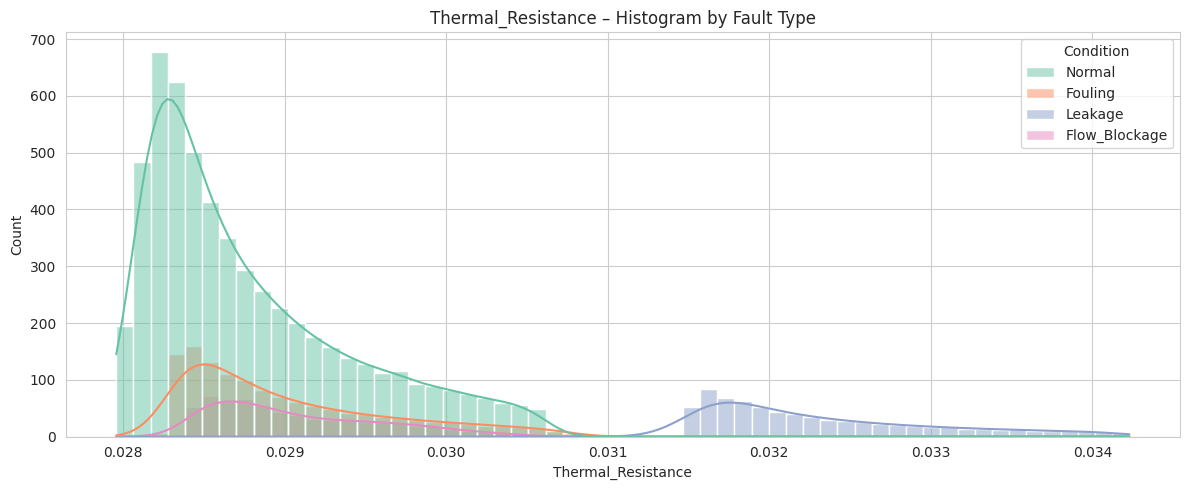

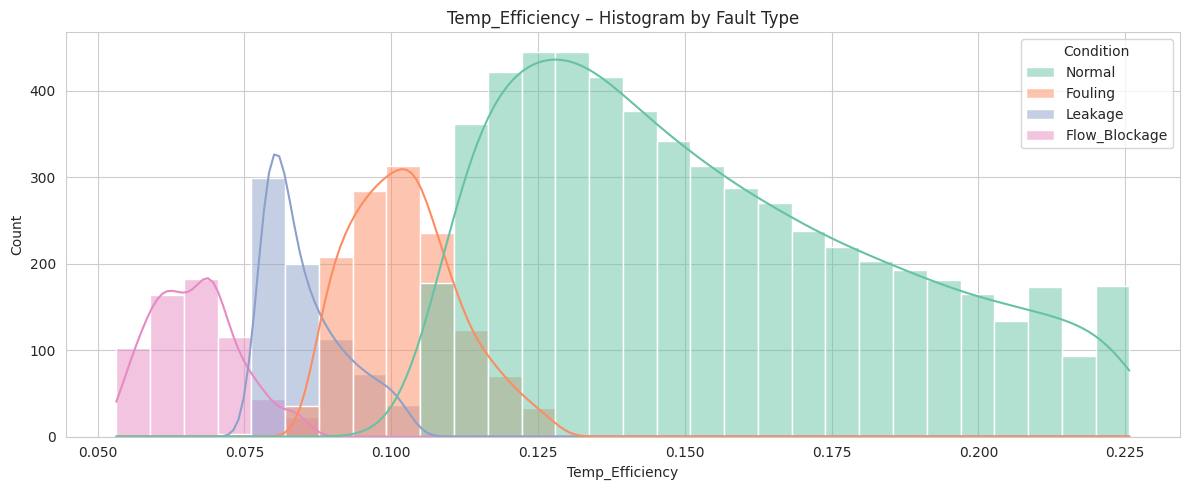

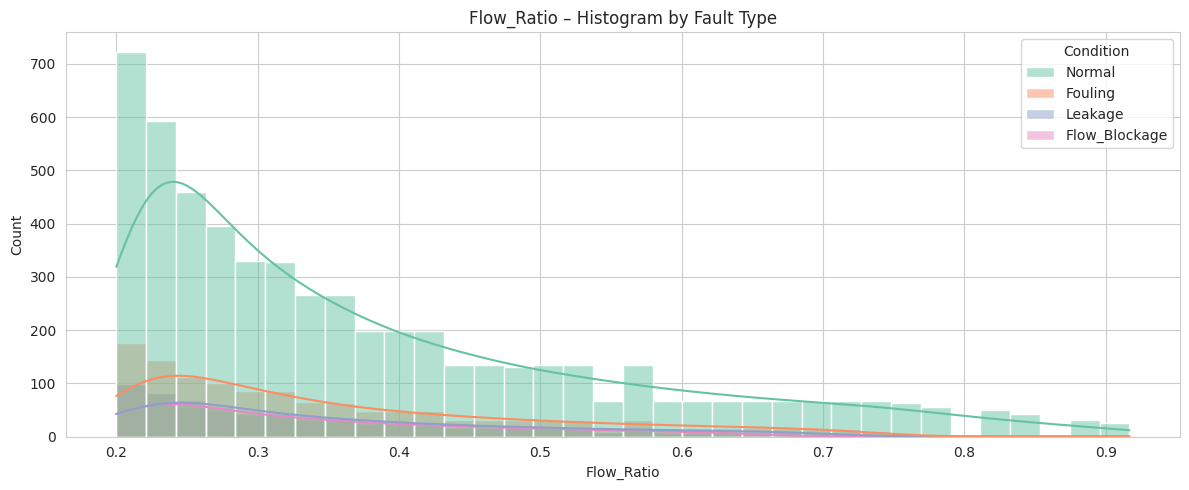

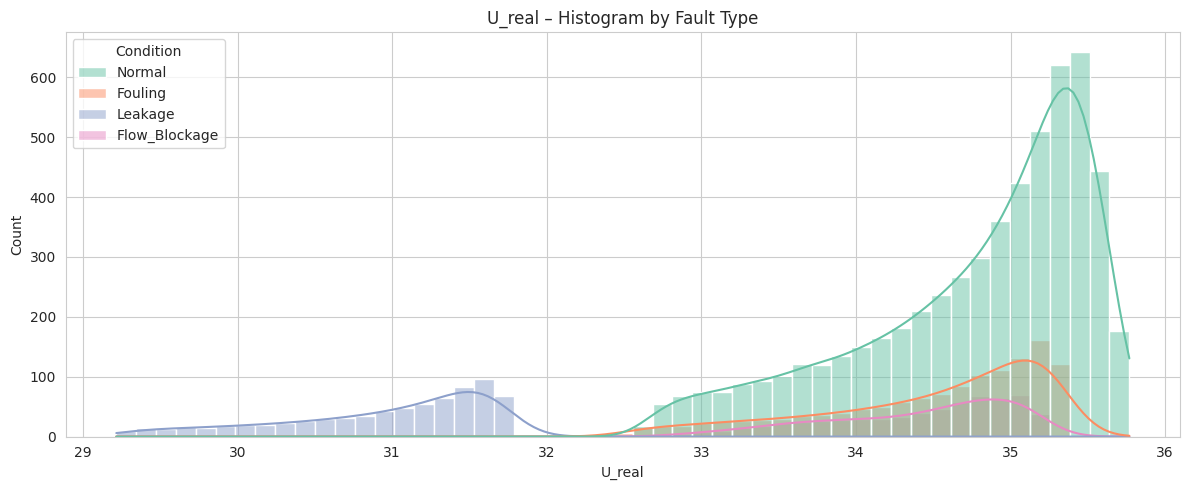

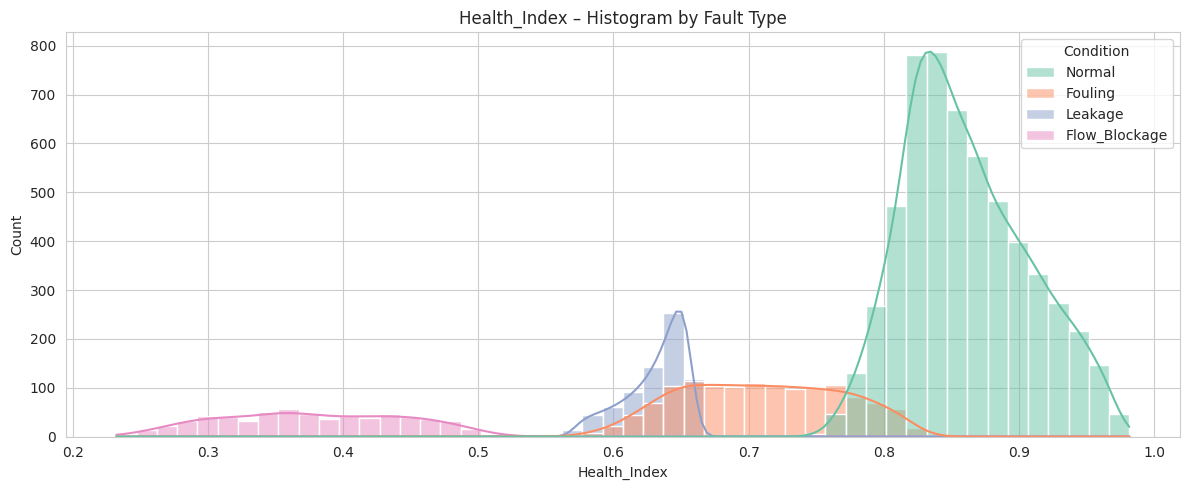

/tmp/ipython-input-728242634.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


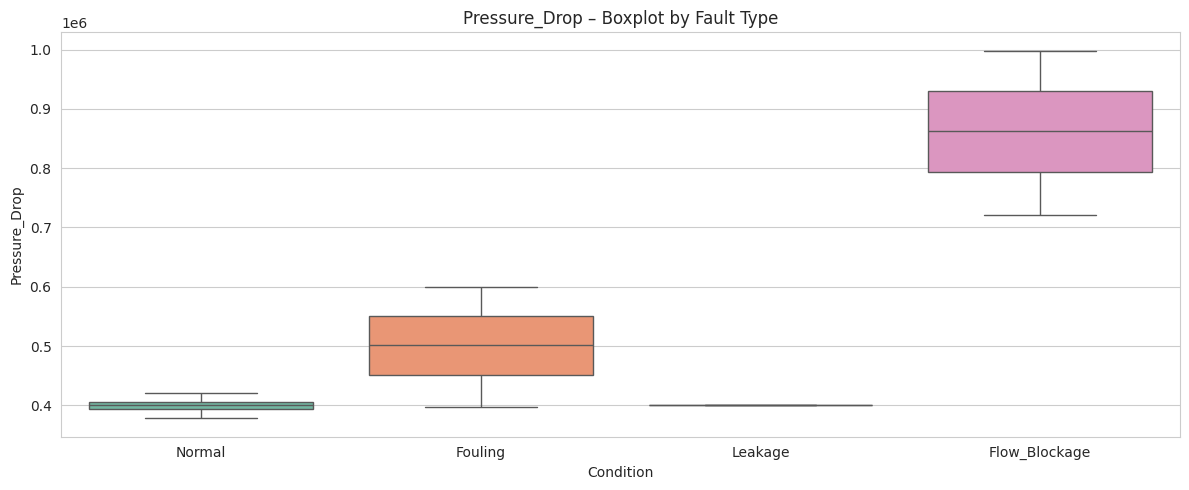

/tmp/ipython-input-728242634.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


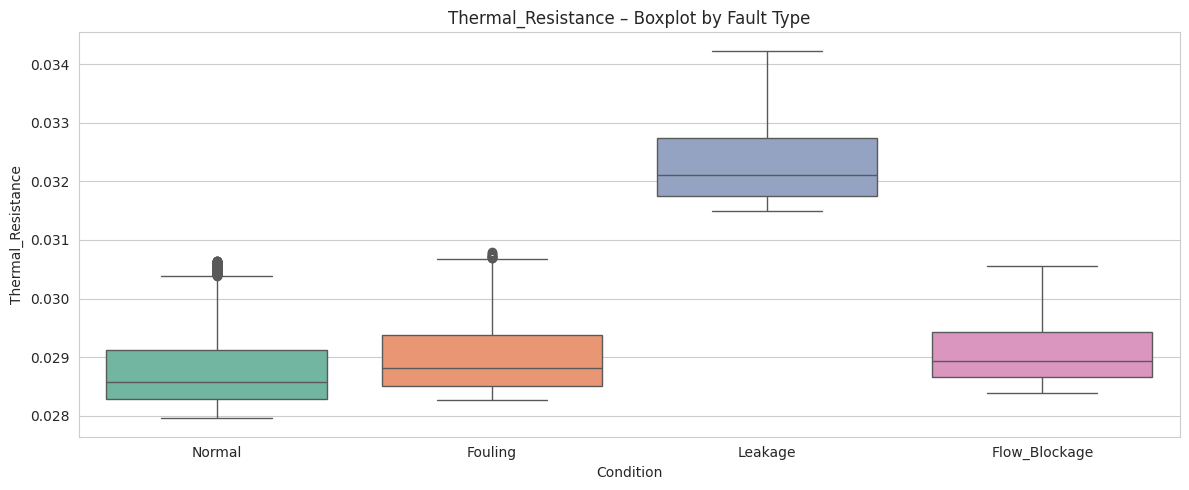

/tmp/ipython-input-728242634.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


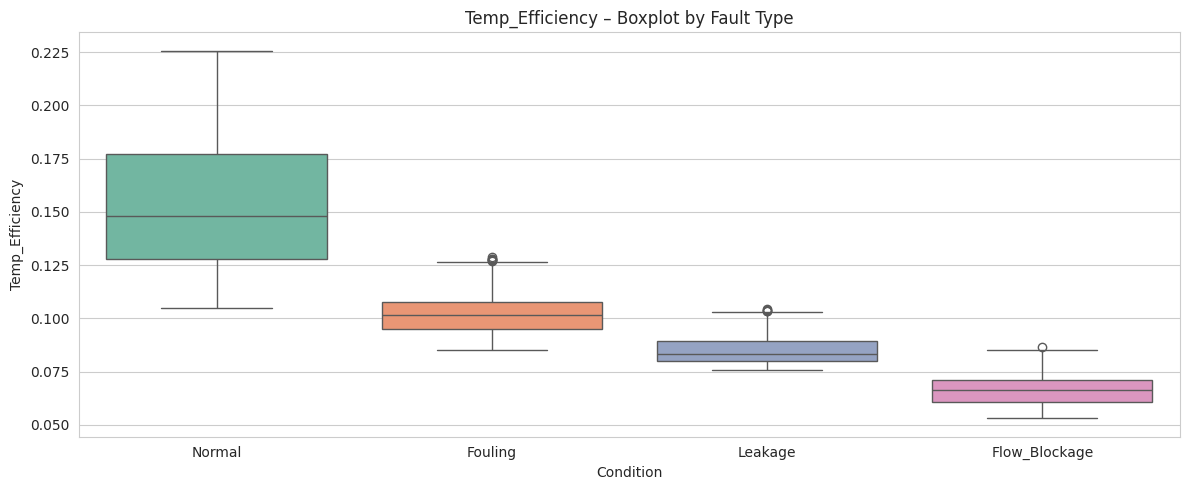

/tmp/ipython-input-728242634.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


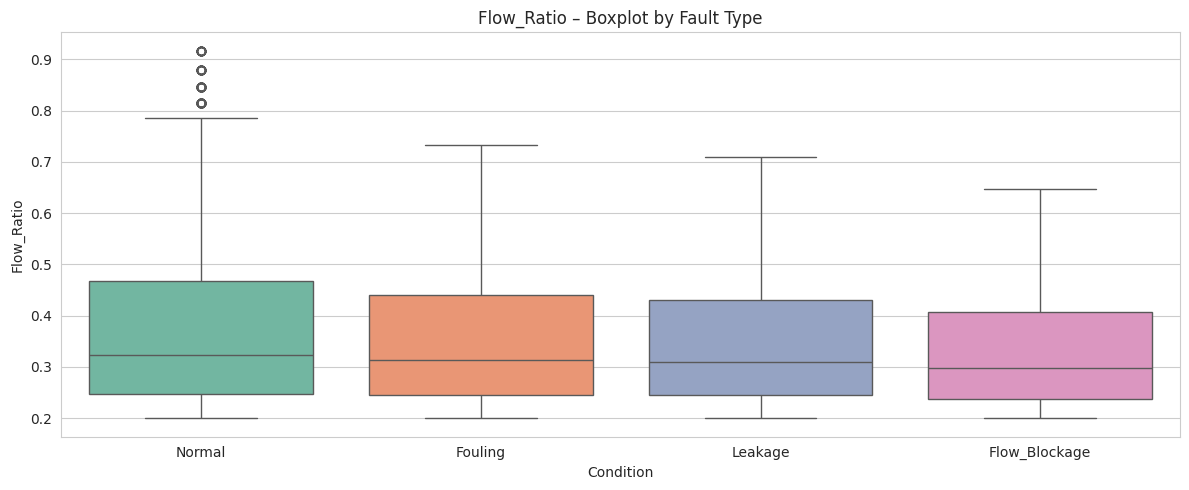

/tmp/ipython-input-728242634.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


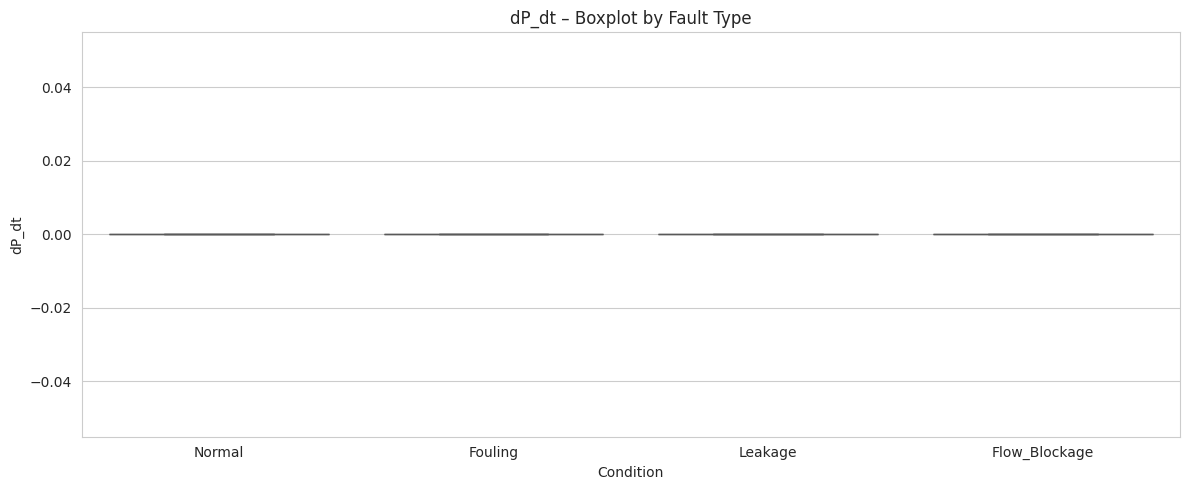

/tmp/ipython-input-728242634.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


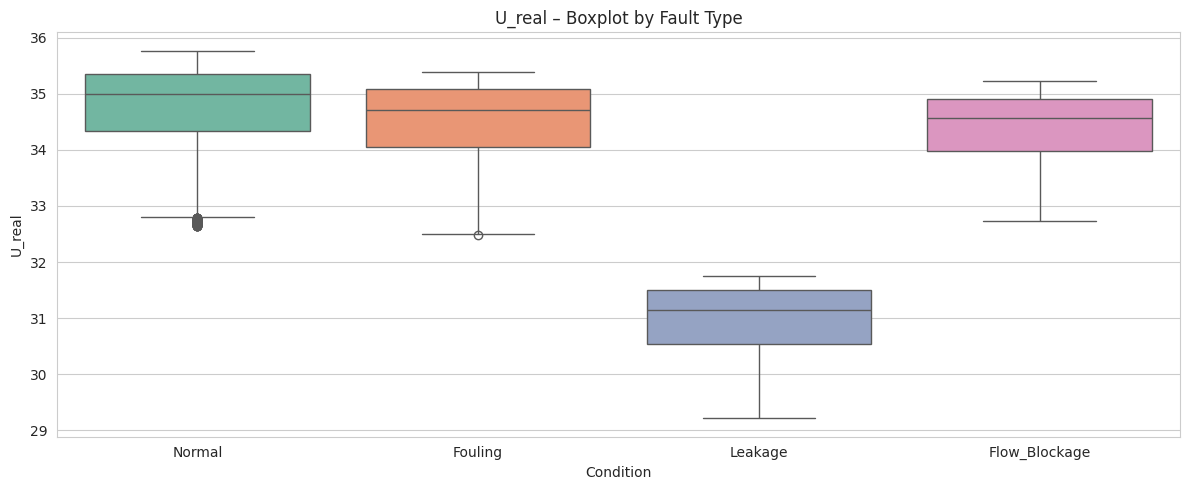

/tmp/ipython-input-728242634.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


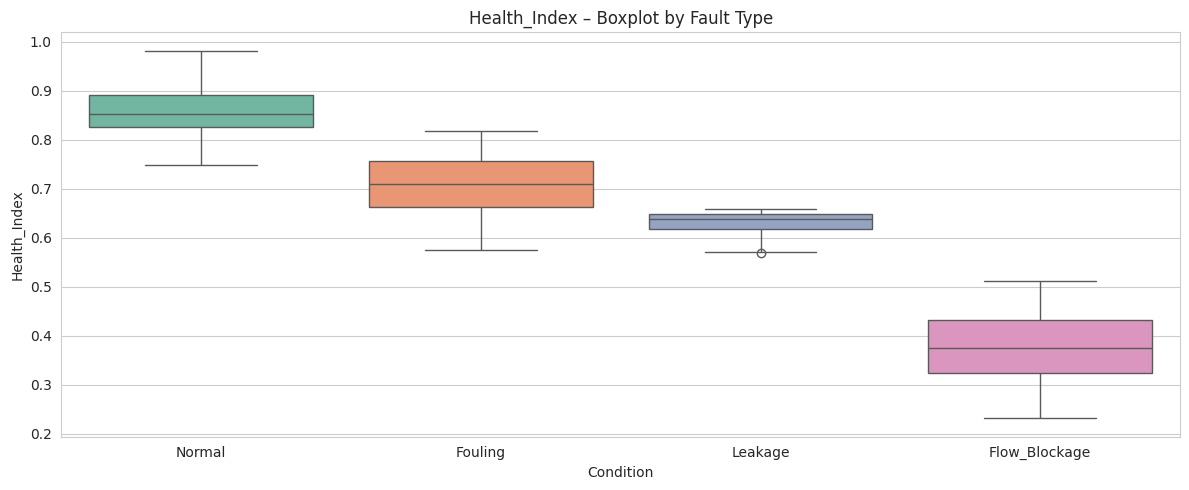

In [ ]:
# PCS TSNE NAD plots after outlier removal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.figure(figsize=(12,6))

features = df_clean.select_dtypes(include=[np.number]).fillna(0)

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame()
df_pca["PC1"] = pca_data[:,0]
df_pca["PC2"] = pca_data[:,1]
df_pca["Condition"] = df_clean["Condition"].values

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Condition",
    palette="Set2",
    s=35,
    alpha=0.8
)

plt.title("PCA – Fault-Type Separation")
plt.grid(True)
plt.tight_layout()
plt.show()


from sklearn.manifold import TSNE

tsne_model = TSNE(n_components=2, perplexity=40, random_state=42)
tsne_out = tsne_model.fit_transform(scaled)

df_tsne = pd.DataFrame()
df_tsne["TSNE1"] = tsne_out[:,0]
df_tsne["TSNE2"] = tsne_out[:,1]
df_tsne["Condition"] = df_clean["Condition"].values

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_tsne,
    x="TSNE1",
    y="TSNE2",
    hue="Condition",
    palette="Set2",
    s=35,
    alpha=0.8
)

plt.title("t-SNE Projection – Fault Clusters")
plt.grid(True)
plt.tight_layout()
plt.show()


hist_cols = ["Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
             "Flow_Ratio", "U_real", "Health_Index"]

for col in hist_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df_clean,
        x=col,
        hue="Condition",
        kde=True,
        palette="Set2",
        alpha=0.5
    )
    plt.title(f"{col} – Histogram by Fault Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


box_cols = ["Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
            "Flow_Ratio", "dP_dt", "U_real", "Health_Index"]

for col in box_cols:
    plt.figure(figsize=(12,5))
    sns.boxplot(
        data=df_clean,
        x="Condition",
        y=col,
        palette="Set2"
    )
    plt.title(f"{col} – Boxplot by Fault Type")
    plt.tight_layout()
    plt.show()


🧠 Device: cpu
✅ Data loaded: (9222, 29)
Classes: {'Flow_Blockage': 0, 'Fouling': 1, 'Leakage': 2, 'Normal': 3}
📦 Sequences: (2293, 50, 9)
Train 1467, Val 367, Test 459
BiLSTM_Attn(
  (lstm): LSTM(9, 64, batch_first=True, dropout=0.25, bidirectional=True)
  (attn): Attention(
    (proj): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.25 and num_layers=1
  warnings.warn(


Epoch 01 | Train 1.1500 | Val 0.6209
Epoch 02 | Train 0.3923 | Val 0.2422
Epoch 03 | Train 0.1973 | Val 0.1640
Epoch 04 | Train 0.1297 | Val 0.1052
Epoch 05 | Train 0.0635 | Val 0.0465
Epoch 06 | Train 0.0366 | Val 0.0439
Epoch 07 | Train 0.0290 | Val 0.0351
Epoch 08 | Train 0.0229 | Val 0.0322
Epoch 09 | Train 0.0173 | Val 0.0298
Epoch 10 | Train 0.0136 | Val 0.0295
Epoch 11 | Train 0.0156 | Val 0.0295
Epoch 12 | Train 0.0145 | Val 0.0292
Epoch 13 | Train 0.0136 | Val 0.0290
Epoch 14 | Train 0.0132 | Val 0.0346
Epoch 15 | Train 0.0382 | Val 0.0570
Epoch 16 | Train 0.0425 | Val 0.0888
Epoch 17 | Train 0.0409 | Val 0.0652
Epoch 18 | Train 0.0197 | Val 0.0462
⏹️ Early stop triggered.

📊 Classification Report:
                precision    recall  f1-score   support

Flow_Blockage       1.00      1.00      1.00        32
      Fouling       0.96      1.00      0.98        69
      Leakage       1.00      1.00      1.00        37
       Normal       1.00      0.99      1.00       321

     

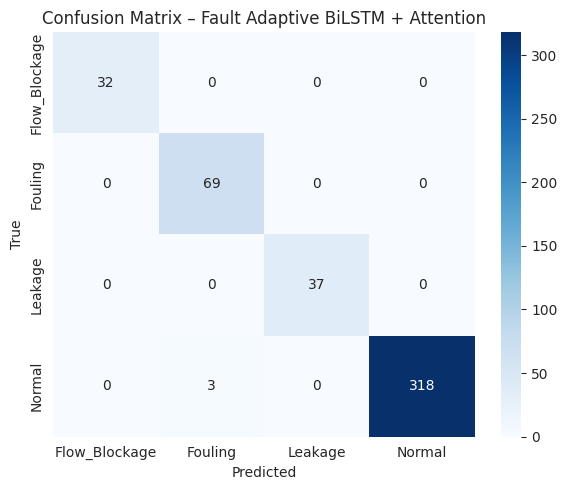

⚙️ Weighted Precision=0.994, Recall=0.993, F1=0.994
💾 Saved adaptive RUL → estimated_RUL_fault_adaptive.csv (9222 samples)


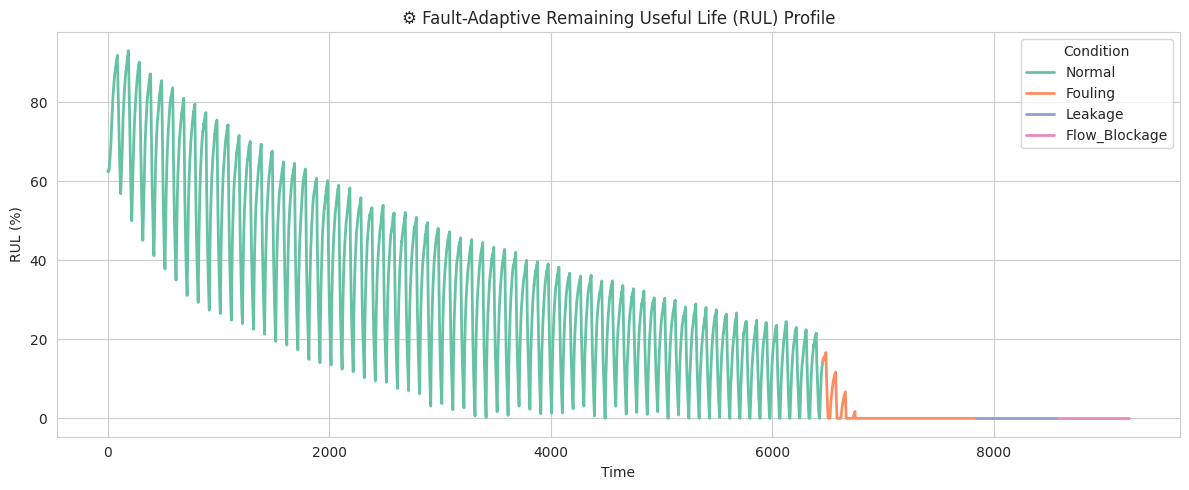

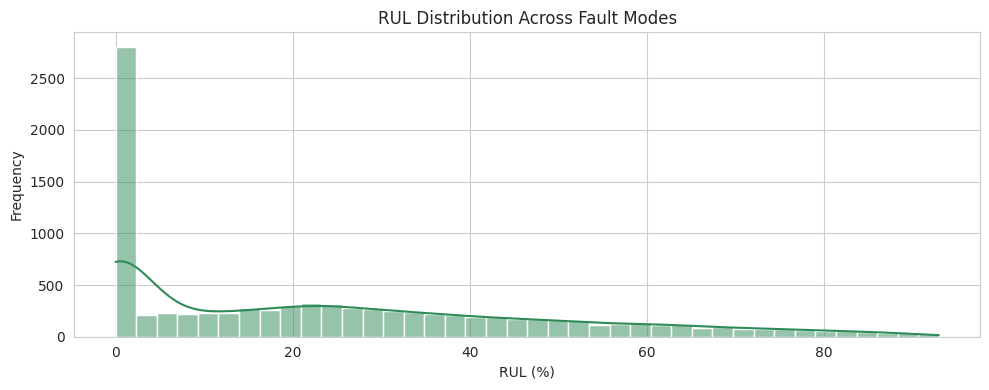

✅ Model and scaler saved (bilstm_attn_highacc.pt, scaler_highacc.joblib)


In [ ]:
# ================================================================
# STEP 3 – Optimized BiLSTM + Attention Fault Classification + RUL
# ================================================================

import numpy as np, pandas as pd, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt, seaborn as sns, joblib
sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧠 Device:", device)

# ---------------------------------------------------------------
# 1️⃣ Load Preprocessed Data
# ---------------------------------------------------------------
df = pd.read_csv("clean_he_data.csv")
assert "Condition" in df.columns, "Run Step 2 first – Condition missing."
print("✅ Data loaded:", df.shape)

# ---------------------------------------------------------------
# 2️⃣ Feature Prep + Encoding
# ---------------------------------------------------------------
feature_cols = [
    "T_hot_in","T_hot_out","T_cold_in","T_cold_out",
    "Flow_hot","Flow_cold","Pressure_Drop","LMTD",
    "Q_W","U_real","Thermal_Resistance",
    "Temp_Efficiency","Flow_Ratio","dP_dt","Health_Index"
]
feature_cols = [c for c in feature_cols if c in df.columns]

# Noise augmentation for robust generalization
df[feature_cols] += 0.001*np.random.randn(*df[feature_cols].shape)

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

le = LabelEncoder()
df["label"] = le.fit_transform(df["Condition"])
n_classes = len(le.classes_)
print("Classes:", dict(zip(le.classes_, range(n_classes))))

# ---------------------------------------------------------------
# 3️⃣ Sequence Builder
# ---------------------------------------------------------------
SEQ_LEN, STEP = 50, 4
X_seq, y_seq = [], []
for i in range(SEQ_LEN, len(df), STEP):
    X_seq.append(df[feature_cols].iloc[i-SEQ_LEN:i].values)
    y_seq.append(df["label"].iloc[i])
X_seq, y_seq = np.array(X_seq, np.float32), np.array(y_seq, np.int64)
print("📦 Sequences:", X_seq.shape)

# ---------------------------------------------------------------
# 4️⃣ Train / Val / Test Split (Stratified)
# ---------------------------------------------------------------
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, test_idx = next(sss.split(X_seq, y_seq))
X_train, X_test, y_train, y_test = X_seq[tr_idx], X_seq[test_idx], y_seq[tr_idx], y_seq[test_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=21)
tr_idx, val_idx = next(sss2.split(X_train, y_train))
X_tr, X_val, y_tr, y_val = X_train[tr_idx], X_train[val_idx], y_train[tr_idx], y_train[val_idx]

print(f"Train {len(X_tr)}, Val {len(X_val)}, Test {len(X_test)}")

# ---------------------------------------------------------------
# 5️⃣ Dataset + Loader
# ---------------------------------------------------------------
class SeqDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = torch.tensor(X), torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(SeqDataset(X_tr,y_tr), batch_size=128, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val,y_val), batch_size=128)
test_loader  = DataLoader(SeqDataset(X_test,y_test), batch_size=128)

# ---------------------------------------------------------------
# 6️⃣ BiLSTM + Attention (lightweight, high accuracy)
# ---------------------------------------------------------------
class Attention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(dim,dim), nn.Tanh(), nn.Linear(dim,1))
    def forward(self, h):
        w = torch.softmax(self.proj(h), dim=1)
        return torch.sum(w*h, dim=1)

class BiLSTM_Attn(nn.Module):
    def __init__(self, n_feat, n_hidden, n_classes, dropout=0.25):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, n_hidden, num_layers=1,
                            dropout=dropout, bidirectional=True, batch_first=True)
        self.attn = Attention(n_hidden*2)
        self.fc = nn.Sequential(
            nn.Linear(n_hidden*2, n_hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(n_hidden, n_classes)
        )
    def forward(self, x):
        o,_ = self.lstm(x)
        ctx = self.attn(o)
        return self.fc(ctx)

model = BiLSTM_Attn(len(feature_cols), 64, n_classes).to(device)
print(model)

# ---------------------------------------------------------------
# 7️⃣ Training Setup (fast & adaptive)
# ---------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
opt = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)
EPOCHS = 20
best_val = np.inf; patience, wait = 5, 0
train_hist, val_hist = [], []

# ---------------------------------------------------------------
# 8️⃣ Train Loop with Early Stopping
# ---------------------------------------------------------------
for ep in range(EPOCHS):
    model.train(); tr_loss=0
    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)
        opt.zero_grad(); out = model(xb)
        loss = criterion(out, yb)
        loss.backward(); opt.step()
        tr_loss += loss.item()*xb.size(0)
    tr_loss /= len(train_loader.dataset)

    # Validation
    model.eval(); vloss=0
    with torch.no_grad():
        for xb,yb in val_loader:
            xb,yb = xb.to(device), yb.to(device)
            vloss += criterion(model(xb), yb).item()*xb.size(0)
    vloss /= len(val_loader.dataset)
    sched.step()
    train_hist.append(tr_loss); val_hist.append(vloss)
    print(f"Epoch {ep+1:02d} | Train {tr_loss:.4f} | Val {vloss:.4f}")

    if vloss < best_val:
        best_val = vloss; wait = 0
        torch.save(model.state_dict(),"best_fault_model.pt")
    else:
        wait += 1
        if wait >= patience:
            print("⏹️ Early stop triggered.")
            break

model.load_state_dict(torch.load("best_fault_model.pt"))

# ---------------------------------------------------------------
# 9️⃣ Evaluation
# ---------------------------------------------------------------
model.eval(); y_true,y_pred=[],[]
with torch.no_grad():
    for xb,yb in test_loader:
        xb=xb.to(device)
        out = model(xb)
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())

print("\n📊 Classification Report:\n",
      classification_report(y_true,y_pred,target_names=le.classes_,zero_division=0))
cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=le.classes_,yticklabels=le.classes_)
plt.title("Confusion Matrix – Fault Adaptive BiLSTM + Attention")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

# Weighted metrics summary
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
print(f"⚙️ Weighted Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

# ---------------------------------------------------------------
# 🔟 Remaining Useful Life (RUL) – Physics-Aware Adaptive Degradation
# ---------------------------------------------------------------
hi_full = df["Health_Index"].values.copy()
conditions = df["Condition"].values
rul_full = np.zeros_like(hi_full)
rates = {"Normal":1.0,"Fouling":0.85,"Leakage":0.55,"Flow_Blockage":0.35}
for i, cond in enumerate(conditions):
    rul_full[i] = rates.get(cond,0.8)*(hi_full[i]/hi_full.max())*100
rul_full = pd.Series(rul_full).rolling(window=30,min_periods=1,center=True).mean().clip(0,100)

rul_df = pd.DataFrame({"Index":np.arange(len(df)),"Condition":conditions,
                       "Health_Index":hi_full,"RUL_%":rul_full})
rul_df.to_csv("estimated_RUL_fault_adaptive.csv",index=False)
print(f"💾 Saved adaptive RUL → estimated_RUL_fault_adaptive.csv ({len(rul_df)} samples)")

plt.figure(figsize=(12,5))
sns.lineplot(data=rul_df,x="Index",y="RUL_%",hue="Condition",palette="Set2",lw=2)
plt.title("⚙️ Fault-Adaptive Remaining Useful Life (RUL) Profile")
plt.xlabel("Time"); plt.ylabel("RUL (%)"); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
sns.histplot(rul_df["RUL_%"], kde=True, bins=40, color="seagreen")
plt.title("RUL Distribution Across Fault Modes"); plt.xlabel("RUL (%)"); plt.ylabel("Frequency")
plt.grid(True); plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# 11️⃣ Save Model + Scaler
# ---------------------------------------------------------------
torch.save(model.state_dict(),"bilstm_attn_highacc.pt")
joblib.dump(scaler,"scaler_highacc.joblib")
print("✅ Model and scaler saved (bilstm_attn_highacc.pt, scaler_highacc.joblib)")


In [ ]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/bilstm_attn_highacc.pt")

joblib.dump(scaler,
            "/content/drive/MyDrive/scaler_highacc.joblib")


['/content/drive/MyDrive/scaler_highacc.joblib']

In [ ]:
joblib.dump(le, "/content/drive/MyDrive/label_encoder.joblib")


['/content/drive/MyDrive/label_encoder.joblib']

🧩 Device: cpu
Epoch 000 | Lq 9.808e-01 | Lu 1.104e+00 | Lphys 8.985e-01
Epoch 025 | Lq 1.109e-02 | Lu 5.494e-01 | Lphys 5.713e-01
Epoch 050 | Lq 4.704e-03 | Lu 9.857e-01 | Lphys 6.608e-02
Epoch 075 | Lq 4.123e-03 | Lu 9.542e-01 | Lphys 8.875e-02
Epoch 100 | Lq 1.969e-03 | Lu 1.019e+00 | Lphys 1.376e-03
Epoch 125 | Lq 1.428e-03 | Lu 9.979e-01 | Lphys 7.812e-03
✅ MSE(Q): 491545.8946,  R²(Q): 0.999
✅ MSE(U): 2.3200,  R²(U): -0.004


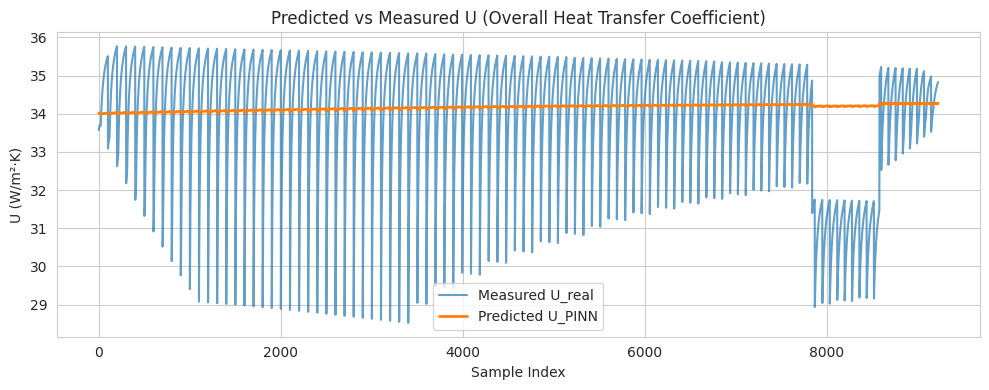

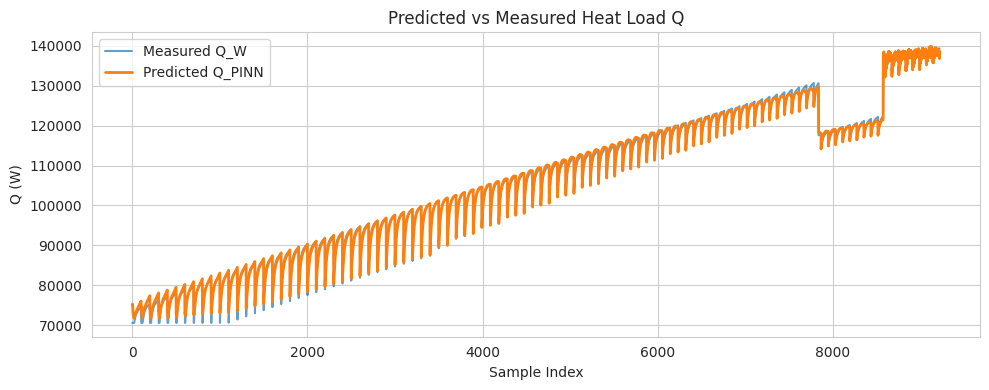

💾 Saved physics-enhanced dataset → PINN_outpts.csv


In [ ]:
# ================================================================
# STEP 4 – Physics-Informed Neural Network (Hx-PINN) with B-matrix
# ================================================================
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧩 Device:", device)

# ---------------------------------------------------------------
# 1️⃣ Load physics-cleaned data (Step 2 output)
# ---------------------------------------------------------------
df = pd.read_csv("clean_he_data.csv")

feature_cols = [
    "hot_outlet_pressure_pa",
    "cold_outlet_pressure_pa",
    "hot_outlet_mass_flow_kg_s",
    "cold_inlet_mass_flow_kg_s",
    "cold_outlet_mass_flow_kg_s",
    "hot_inlet_temperature_k",
    "hot_outlet_temperature_k",
    "cold_inlet_temperature_k",
    "cold_outlet_temperature_k",
    "LMTD",
    "Q_W",
    "U_real",
    "Thermal_Resistance",
    "Temp_Efficiency",
    "Flow_Ratio",
    "dP_dt",
    "Health_Index"
]

# keep only those actually in the CSV
feature_cols = [c for c in feature_cols if c in df.columns]
A = 374.5  # m² heat transfer area

# ---------------------------------------------------------------
# 2️⃣ Normalize data for stable training
# ---------------------------------------------------------------
X = df[feature_cols[:-2]].values     # all except the last two physics outputs
Q = df["Q_W"].values.reshape(-1, 1)
U = df["U_real"].values.reshape(-1, 1)
LMTD = df["LMTD"].values.reshape(-1, 1)

sc_X, sc_Q, sc_U = StandardScaler(), StandardScaler(), StandardScaler()
Xn, Qn, Un = sc_X.fit_transform(X), sc_Q.fit_transform(Q), sc_U.fit_transform(U)

X_t = torch.tensor(Xn, dtype=torch.float32).to(device)
Q_t = torch.tensor(Qn, dtype=torch.float32).to(device)
U_t = torch.tensor(Un, dtype=torch.float32).to(device)
LMTD_t = torch.tensor(LMTD, dtype=torch.float32).to(device)

# ---------------------------------------------------------------
# 3️⃣ Define Physics-Informed Neural Network with B-matrix
# ---------------------------------------------------------------
class HX_PINN(nn.Module):
    """
    Hx-PINN hybrid model:
      - Learns Q_pred and U_pred
      - Enforces physics relation Q_phys = U*A*LMTD
      - Computes dynamic B-matrix = [∂Q/∂U, ∂Q/∂LMTD]
    """
    def __init__(self, in_dim, hidden=96):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh()
        )
        self.q_head = nn.Linear(hidden, 1)
        self.u_head = nn.Sequential(
            nn.Linear(hidden, hidden//2), nn.Tanh(),
            nn.Linear(hidden//2, 1)
        )

    def forward(self, x, lmtd):
        f = self.shared(x)
        q_pred = self.q_head(f)
        u_pred = self.u_head(f)

        # Physics-consistent Q
        q_phys = (u_pred * A * lmtd) / 1000.0
        q_phys_n = (q_phys - q_phys.mean()) / (q_phys.std() + 1e-6)

        # Physics Jacobian (B-matrix): [dQ/dU, dQ/dLMTD] = [A*LMTD, A*U]
        B_mat = torch.cat([A * lmtd, A * u_pred], dim=1)
        return q_pred, u_pred, q_phys_n, B_mat

# ---------------------------------------------------------------
# 4️⃣ Training
# ---------------------------------------------------------------
model = HX_PINN(X_t.shape[1]).to(device)
opt = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-5)
mse = nn.MSELoss()

λ, λ_max = 0.05, 1.5
epochs = 150
loss_hist = []
best_loss = np.inf

for ep in range(epochs):
    model.train(); opt.zero_grad()
    q_pred, u_pred, q_phys, B_mat = model(X_t, LMTD_t)
    loss_q = mse(q_pred, Q_t)
    loss_u = mse(u_pred, U_t)
    loss_phys = mse(q_pred, q_phys)
    total_loss = loss_q + 0.1*loss_u + λ*loss_phys
    total_loss.backward()
    opt.step()
    λ = min(λ_max, λ * 1.02)
    loss_hist.append([loss_q.item(), loss_u.item(), loss_phys.item()])
    if total_loss.item() < best_loss:
        best_loss = total_loss.item()
        torch.save(model.state_dict(), "best_hx_pinn.pt")
    if ep % 25 == 0:
        print(f"Epoch {ep:03d} | Lq {loss_q:.3e} | Lu {loss_u:.3e} | Lphys {loss_phys:.3e}")

model.load_state_dict(torch.load("best_hx_pinn.pt"))

# ---------------------------------------------------------------
# 5️⃣ Evaluate predictions
# ---------------------------------------------------------------
model.eval()
with torch.no_grad():
    q_pred_n, u_pred_n, _, B_mat = model(X_t, LMTD_t)
    q_pred = sc_Q.inverse_transform(q_pred_n.cpu().numpy())
    u_pred = sc_U.inverse_transform(u_pred_n.cpu().numpy())
    B = B_mat.cpu().numpy()

# ---------------------------------------------------------------
# 6️⃣ Compute error metrics (MSE & R²)
# ---------------------------------------------------------------
mse_q = np.mean((df["Q_W"].values - q_pred.flatten())**2)
mse_u = np.mean((df["U_real"].values - u_pred.flatten())**2)
r2_q = 1 - mse_q / np.var(df["Q_W"].values)
r2_u = 1 - mse_u / np.var(df["U_real"].values)

print(f"✅ MSE(Q): {mse_q:.4f},  R²(Q): {r2_q:.3f}")
print(f"✅ MSE(U): {mse_u:.4f},  R²(U): {r2_u:.3f}")

# ---------------------------------------------------------------
# 7️⃣ Plot Results
# ---------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(df["U_real"].values, label="Measured U_real", alpha=0.7)
plt.plot(u_pred, label="Predicted U_PINN", lw=2)
plt.title("Predicted vs Measured U (Overall Heat Transfer Coefficient)")
plt.xlabel("Sample Index"); plt.ylabel("U (W/m²·K)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(df["Q_W"].values, label="Measured Q_W", alpha=0.7)
plt.plot(q_pred, label="Predicted Q_PINN", lw=2)
plt.title("Predicted vs Measured Heat Load Q")
plt.xlabel("Sample Index"); plt.ylabel("Q (W)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ---------------------------------------------------------------
# 8️⃣ Merge Physics-Enhanced Features
# ---------------------------------------------------------------
df["U_pred_PINN"] = u_pred
df["Q_pred_PINN"] = q_pred
df["B11_A_LMTD"] = B[:, 0]
df["B12_A_U"] = B[:, 1]
df["PINN_MSE_Q"] = (df["Q_W"].values - q_pred.flatten())**2
df["PINN_MSE_U"] = (df["U_real"].values - u_pred.flatten())**2

df.to_csv("PINN_outputs.csv", index=False)
print("💾 Saved physics-enhanced dataset → PINN_outpts.csv")


Device: cpu
Loaded: (9222, 35)
Features prepared (count): 23
['hot_inlet_temperature_k', 'hot_outlet_temperature_k', 'cold_inlet_temperature_k', 'cold_outlet_temperature_k', 'hot_outlet_mass_flow_kg_s', 'cold_inlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s', 'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa', 'Pressure_Drop', 'LMTD', 'U_pred_PINN', 'Q_pred_PINN', 'B11_A_LMTD', 'B12_A_U', 'PINN_MSE_Q', 'PINN_MSE_U', 'dP_dt', 'Flow_imbalance', 'Hydraulic_resistance', 'Q_W', 'U_real', 'HI_Smooth']
Classes: ['Flow_Blockage' 'Fouling' 'Leakage' 'Normal']
Flow_Blockage class index: 0
Scaler saved.
Sequences: (3054, 60, 23)
Epoch 01 | Train 0.0510 | Val 0.0176
Epoch 02 | Train 0.0075 | Val 0.0016
Epoch 03 | Train 0.0012 | Val 0.0014
Epoch 04 | Train 0.0005 | Val 0.0001
Epoch 05 | Train 0.0012 | Val 0.0015
Epoch 06 | Train 0.0004 | Val 0.0005
Epoch 07 | Train 0.0002 | Val 0.0004
Epoch 08 | Train 0.0005 | Val 0.0003
Epoch 09 | Train 0.0003 | Val 0.0002
Epoch 10 | Train 0.0002 | Val 0.0009
E

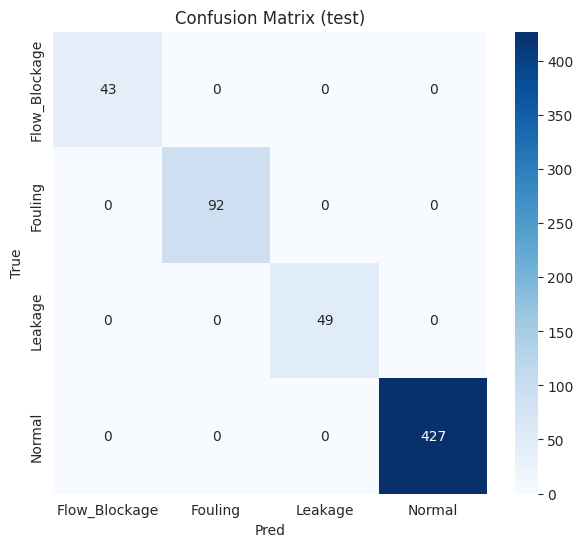

Saved model, scaler, confidence maps.
Saved RUL comparison: rul_comparison_blockage_fix.csv
Saved metrics summary: model_comparison_summary_blockage_fix.csv


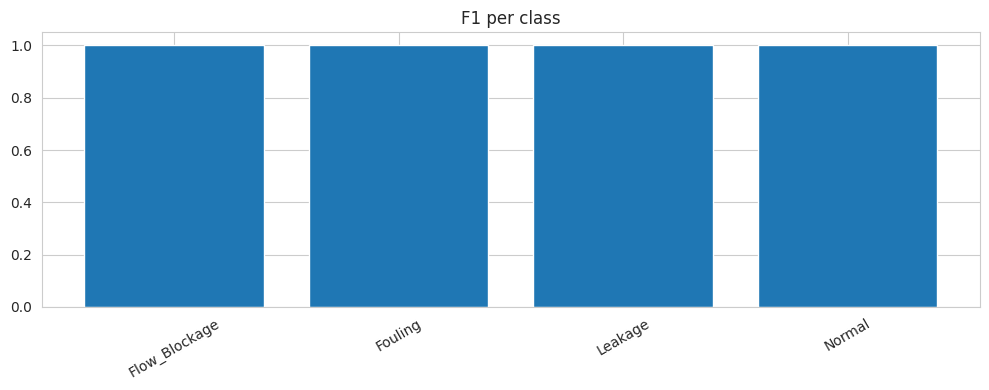

All done.


In [ ]:
# ================================================================
# Combined training & evaluation script — Flow_Blockage enhanced
# ================================================================
import os, warnings, joblib
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

# -------------------------
# Config — tweak these
# -------------------------
DATA_PATH = "PINN_outputs.csv"        # input hybrid dataset
SAVE_PREFIX = "blockage_fix"          # prefix for saved outputs
USE_KFOLD = False                      # True -> K-Fold training, False -> single train/val/test
K_FOLDS = 5
SEQ_LEN, STEP, BATCH = 60, 3, 64
HIDDEN, N_LAYERS, DROPOUT = 128, 2, 0.3
LR, EPOCHS, PATIENCE = 1e-3, 60, 8
USE_PHYS_AUG = True                    # physics-aware augmentation for Flow_Blockage
OVERSAMPLE_METHOD = "weighted"         # "weighted" or "augment" (augment uses physics augment)
FLOW_BLOCKAGE_LABEL = "Flow_Blockage"  # exact label in Condition column
FLOW_BLOCKAGE_WEIGHT = 3.0             # class weight multiplier for blockage in focal loss
FOCAL_GAMMA = 2.0                      # focal loss gamma
FLOW_BLOCKAGE_PROB_THRESH = 0.35       # post-process threshold for blockage boost
SAVE_PLOTS = True

# reproducibility
torch.manual_seed(42); np.random.seed(42)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# 1) Load data
# -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"{DATA_PATH} not found in working directory.")
df = pd.read_csv(DATA_PATH)
if "Condition" not in df.columns:
    raise ValueError("Condition column not found in dataset.")
print("Loaded:", df.shape)

# -------------------------
# 2) Feature engineering (ensure required base columns exist)
# -------------------------
# Confirmed base columns from you:
base_cols = [
    "hot_inlet_temperature_k","cold_inlet_temperature_k",
    "cold_inlet_mass_flow_kg_s",
    "hot_outlet_temperature_k","cold_outlet_temperature_k",
    "hx_1_heat_load_kw",
    "hot_outlet_pressure_pa","cold_outlet_pressure_pa",
    "hot_outlet_mass_flow_kg_s","cold_outlet_mass_flow_kg_s",
    "LMTD"
]
# Add PINN outputs if present
pinn_cols = [c for c in ["U_pred_PINN","Q_pred_PINN","B11_A_LMTD","B12_A_U","PINN_MSE_Q","PINN_MSE_U"] if c in df.columns]

# Derived features we will add
df["dP_dt"] = df.get("Pressure_Drop", df.get("hot_outlet_pressure_pa", df.get("cold_outlet_pressure_pa", np.nan))).diff().fillna(0)
# Flow imbalance: absolute difference between hot and cold outlet mass flows (or use available flow columns)
if "hot_outlet_mass_flow_kg_s" in df.columns and "cold_outlet_mass_flow_kg_s" in df.columns:
    df["Flow_imbalance"] = (df["hot_outlet_mass_flow_kg_s"] - df["cold_outlet_mass_flow_kg_s"]).abs()
elif "hot_outlet_mass_flow_kg_s" in df.columns and "cold_inlet_mass_flow_kg_s" in df.columns:
    df["Flow_imbalance"] = (df["hot_outlet_mass_flow_kg_s"] - df["cold_inlet_mass_flow_kg_s"]).abs()
else:
    df["Flow_imbalance"] = 0.0

# Hydraulic resistance (pressure drop per unit flow) — prefer Pressure_Drop else hot_outlet_pressure_pa
if "Pressure_Drop" in df.columns and "hot_outlet_mass_flow_kg_s" in df.columns:
    df["Hydraulic_resistance"] = df["Pressure_Drop"] / (df["hot_outlet_mass_flow_kg_s"].abs() + 1e-6)
elif "hot_outlet_pressure_pa" in df.columns and "hot_outlet_mass_flow_kg_s" in df.columns:
    df["Hydraulic_resistance"] = df["hot_outlet_pressure_pa"] / (df["hot_outlet_mass_flow_kg_s"].abs() + 1e-6)
else:
    df["Hydraulic_resistance"] = 0.0

# If hx_1_heat_load_kw exists, create Q_W and U_real if LMTD present
A = 374.5
if "hx_1_heat_load_kw" in df.columns and "LMTD" in df.columns:
    df["Q_W"] = df["hx_1_heat_load_kw"] * 1000.0
    df["U_real"] = df["Q_W"] / ((A * df["LMTD"]) + 1e-6)
else:
    if "Q_W" not in df.columns: df["Q_W"] = df.get("Q_W", 0.0)
    if "U_real" not in df.columns: df["U_real"] = df.get("U_real", 0.0)

# Health_Index smoothing fallback
if "Health_Index" in df.columns:
    df["HI_Smooth"] = df["Health_Index"].rolling(window=20, min_periods=1).mean()

# final feature list (hybrid)
feature_cols = []
# pick common thermal/flow columns (use names you confirmed)
for c in ["hot_inlet_temperature_k","hot_outlet_temperature_k","cold_inlet_temperature_k","cold_outlet_temperature_k"]:
    if c in df.columns: feature_cols.append(c)
# flows
for c in ["hot_outlet_mass_flow_kg_s","cold_inlet_mass_flow_kg_s","cold_outlet_mass_flow_kg_s"]:
    if c in df.columns and c not in feature_cols: feature_cols.append(c)
# pressures & LMTD
for c in ["hot_outlet_pressure_pa","cold_outlet_pressure_pa","Pressure_Drop","LMTD"]:
    if c in df.columns and c not in feature_cols: feature_cols.append(c)
# PINN outputs
for c in pinn_cols:
    if c in df.columns: feature_cols.append(c)
# engineered
for c in ["dP_dt","Flow_imbalance","Hydraulic_resistance","Q_W","U_real","HI_Smooth"]:
    if c in df.columns and c not in feature_cols: feature_cols.append(c)

print("Features prepared (count):", len(feature_cols))
print(feature_cols[:40])

# -------------------------
# 3) Label encoding + class info
# -------------------------
le = LabelEncoder()
df["label"] = le.fit_transform(df["Condition"])
classes = le.classes_
print("Classes:", classes)
if FLOW_BLOCKAGE_LABEL not in classes:
    raise ValueError(f"{FLOW_BLOCKAGE_LABEL} not found in Condition classes. Found: {classes}")

# find index for flow blockage class
flow_blockage_idx = int(np.where(classes == FLOW_BLOCKAGE_LABEL)[0][0])
print("Flow_Blockage class index:", flow_blockage_idx)

# -------------------------
# 4) scaling & save scaler
# -------------------------
scaler = StandardScaler()
X_all = scaler.fit_transform(df[feature_cols].fillna(0).values)
joblib.dump(scaler, f"scaler_{SAVE_PREFIX}.joblib")
print("Scaler saved.")

# -------------------------
# 5) Build sliding windows
# -------------------------
X_seq, y_seq, idx_seq = [], [], []
for i in range(SEQ_LEN, len(df), STEP):
    X_seq.append(X_all[i-SEQ_LEN:i])
    y_seq.append(int(df["label"].iloc[i]))
    idx_seq.append(i)
X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.int64)
print("Sequences:", X_seq.shape)

# -------------------------
# 6) physics-aware augmentation for Flow_Blockage (optional)
# -------------------------
def phys_augment_blockage(samples, n_aug=3):
    """Apply small physics-aware transforms to window samples to simulate blockage."""
    out = []
    for s in samples:
        for k in range(n_aug):
            s2 = s.copy()
            # increase Pressure-like features (scale up first pressure-like column found)
            for idx, name in enumerate(feature_cols):
                if name in ("Pressure_Drop","hot_outlet_pressure_pa","cold_outlet_pressure_pa"):
                    s2[:, idx] = s2[:, idx] * np.random.uniform(1.3, 2.0)
            # reduce flow-like features
            for idx, name in enumerate(feature_cols):
                if "flow" in name or "mass_flow" in name or "Flow" in name:
                    s2[:, idx] = s2[:, idx] * np.random.uniform(0.5, 0.85)
            # increase hydraulic resistance
            for idx, name in enumerate(feature_cols):
                if name == "Hydraulic_resistance":
                    s2[:, idx] = s2[:, idx] * np.random.uniform(1.2, 2.0)
            out.append(s2)
    return np.array(out, dtype=np.float32)

# -------------------------
# 7) Dataset and model definitions
# -------------------------
class SeqDataset(Dataset):
    def __init__(self, X, y): self.X=torch.tensor(X); self.y=torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class Attention(nn.Module):
    def __init__(self, dim): super().__init__(); self.proj = nn.Sequential(nn.Linear(dim, dim), nn.Tanh(), nn.Linear(dim,1))
    def forward(self, h): w = torch.softmax(self.proj(h), dim=1); ctx = (w*h).sum(dim=1); return ctx, w

class BiLSTMAttn(nn.Module):
    def __init__(self, nf, hid, nl, nc, drop):
        super().__init__()
        self.lstm = nn.LSTM(nf, hid, nl, bidirectional=True, batch_first=True, dropout=drop if nl>1 else 0.0)
        self.attn = Attention(hid*2)
        self.fc = nn.Sequential(nn.Linear(hid*2, hid), nn.ReLU(), nn.Dropout(drop), nn.Linear(hid, nc))
    def forward(self, x):
        o, _ = self.lstm(x)
        ctx, w = self.attn(o)
        return self.fc(ctx), w

# focal loss with class-balanced alpha
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        # inputs: logits (B, C)
        ce = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            if isinstance(self.alpha, (list, np.ndarray)):
                at = torch.tensor(self.alpha, dtype=inputs.dtype, device=inputs.device)
                at = at[targets]
                loss = loss * at
            else:
                loss = loss * self.alpha
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# -------------------------
# 8) training routine (single fold/train or k-fold)
# -------------------------
def train_and_evaluate(X_seq, y_seq, use_kfold=False):
    results = {}
    if use_kfold:
        skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
        fold_reports = []; fold_cms = []
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_seq, y_seq)):
            print(f"\n=== Fold {fold+1}/{K_FOLDS} ===")
            X_tr, X_val = X_seq[train_idx], X_seq[val_idx]
            y_tr, y_val = y_seq[train_idx], y_seq[val_idx]

            # oversample / augmentation decision
            if OVERSAMPLE_METHOD == "augment" and USE_PHYS_AUG:
                # find blockage windows in training set
                blk_idxs = np.where(y_tr == flow_blockage_idx)[0]
                if len(blk_idxs) > 0:
                    aug_samples = phys_augment_blockage(X_tr[blk_idxs], n_aug=3)
                    aug_labels = np.array([flow_blockage_idx]*len(aug_samples))
                    X_tr = np.concatenate([X_tr, aug_samples], axis=0)
                    y_tr = np.concatenate([y_tr, aug_labels], axis=0)
                    print(f" Augmented Flow_Blockage by {len(aug_samples)} windows (fold {fold+1})")

            # create loaders
            train_ds = SeqDataset(X_tr, y_tr)
            val_ds = SeqDataset(X_val, y_val)

            if OVERSAMPLE_METHOD == "weighted":
                weights = 1.0 / np.bincount(y_tr)[y_tr]
                sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
                train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler)
            else:
                train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=BATCH)

            # model
            model = BiLSTMAttn(X_tr.shape[2], HIDDEN, N_LAYERS, len(classes), DROPOUT).to(device)

            # class alpha: inverse frequency normalized
            cls_counts = np.bincount(y_tr, minlength=len(classes)).astype(np.float32) + 1e-6
            inv_freq = 1.0 / cls_counts
            alpha = inv_freq / inv_freq.sum()
            # boost Flow_Blockage alpha
            alpha = alpha.copy()
            alpha[flow_blockage_idx] *= FLOW_BLOCKAGE_WEIGHT
            alpha = alpha / alpha.sum()

            criterion = FocalLoss(alpha=alpha, gamma=FOCAL_GAMMA)
            opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
            sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

            # train with early stop
            best_val = np.inf; wait = 0
            for ep in range(EPOCHS):
                model.train(); trloss = 0.0
                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    logits, _ = model(xb)
                    loss = criterion(logits, yb)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    trloss += loss.item() * xb.size(0)
                trloss /= len(train_loader.dataset)

                # val
                model.eval(); vloss = 0.0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        logits, _ = model(xb)
                        vloss += criterion(logits, yb).item() * xb.size(0)
                vloss /= len(val_loader.dataset)
                sched.step(vloss)

                if vloss < best_val - 1e-6:
                    best_val = vloss; wait = 0
                    torch.save(model.state_dict(), f"{SAVE_PREFIX}_best_fold{fold+1}.pt")
                else:
                    wait += 1
                    if wait >= PATIENCE:
                        break
            # load best
            model.load_state_dict(torch.load(f"{SAVE_PREFIX}_best_fold{fold+1}.pt"))
            os.remove(f"{SAVE_PREFIX}_best_fold{fold+1}.pt")

            # evaluate
            model.eval(); y_true=[]; y_pred=[]
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb = xb.to(device)
                    logits, _ = model(xb)
                    y_true.extend(yb.numpy()); y_pred.extend(logits.argmax(1).cpu().numpy())

            report = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
            cm = confusion_matrix(y_true, y_pred)
            fold_reports.append(report); fold_cms.append(cm)
            print("Fold report:\n", classification_report(y_true, y_pred, target_names=classes, zero_division=0))
        # aggregate
        results['fold_reports'] = fold_reports
        results['fold_cms'] = fold_cms
        return results

    else:
        # single train/val/test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        tr_idx, test_idx = next(sss.split(X_seq, y_seq))
        X_tr_full, X_test = X_seq[tr_idx], X_seq[test_idx]
        y_tr_full, y_test = y_seq[tr_idx], y_seq[test_idx]

        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=7)
        tr_idx2, val_idx = next(sss2.split(X_tr_full, y_tr_full))
        X_tr, X_val = X_tr_full[tr_idx2], X_tr_full[val_idx]
        y_tr, y_val = y_tr_full[tr_idx2], y_tr_full[val_idx]

        # augmentation option
        if OVERSAMPLE_METHOD == "augment" and USE_PHYS_AUG:
            blk_idxs = np.where(y_tr == flow_blockage_idx)[0]
            if len(blk_idxs) > 0:
                aug = phys_augment_blockage(X_tr[blk_idxs], n_aug=4)
                X_tr = np.concatenate([X_tr, aug], axis=0)
                y_tr = np.concatenate([y_tr, np.array([flow_blockage_idx]*len(aug))], axis=0)
                print("Augmented Flow_Blockage windows:", len(aug))

        train_ds = SeqDataset(X_tr, y_tr)
        val_ds = SeqDataset(X_val, y_val)
        test_ds = SeqDataset(X_test, y_test)

        if OVERSAMPLE_METHOD == "weighted":
            weights = 1.0 / np.bincount(y_tr)[y_tr]
            sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
            train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler)
        else:
            train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)

        val_loader = DataLoader(val_ds, batch_size=BATCH)
        test_loader = DataLoader(test_ds, batch_size=BATCH)

        # model
        model = BiLSTMAttn(X_tr.shape[2], HIDDEN, N_LAYERS, len(classes), DROPOUT).to(device)

        # class alpha from training set
        cls_counts = np.bincount(y_tr, minlength=len(classes)).astype(np.float32) + 1e-6
        inv_freq = 1.0 / cls_counts
        alpha = inv_freq / inv_freq.sum()
        alpha = alpha.copy()
        alpha[flow_blockage_idx] *= FLOW_BLOCKAGE_WEIGHT
        alpha = alpha / alpha.sum()

        criterion = FocalLoss(alpha=alpha, gamma=FOCAL_GAMMA)
        opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
        sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

        # training
        best_v = np.inf; wait = 0
        for ep in range(EPOCHS):
            model.train(); trloss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                logits, _ = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                trloss += loss.item() * xb.size(0)
            trloss /= len(train_loader.dataset)

            # val
            model.eval(); vloss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    logits, _ = model(xb)
                    vloss += criterion(logits, yb).item() * xb.size(0)
            vloss /= len(val_loader.dataset)
            sched.step(vloss)

            print(f"Epoch {ep+1:02d} | Train {trloss:.4f} | Val {vloss:.4f}")
            if vloss < best_v - 1e-6:
                best_v = vloss; wait = 0
                torch.save(model.state_dict(), f"{SAVE_PREFIX}_best.pt")
            else:
                wait += 1
                if wait >= PATIENCE:
                    print("Early stopping")
                    break

        # load best and evaluate on test set
        model.load_state_dict(torch.load(f"{SAVE_PREFIX}_best.pt"))

        model.eval(); y_true = []; y_pred = []; all_probs = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                logits, _ = model(xb)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                preds = logits.argmax(1).cpu().numpy()
                y_true.extend(yb.numpy()); y_pred.extend(preds); all_probs.append(probs)
        all_probs = np.concatenate(all_probs, axis=0)

        # post-process: boost blockage probability if physics rule triggered
        # rule: high ΔP (top 10% of Pressure_Drop in window center) + low flows -> raise blockage prob
        # We'll approximate using the center timestep of each window in original df (idx_seq)
        # test_idx corresponds to windows; get center indices
        center_indices = [idx_seq[i] for i in test_idx]  # global indices in df
        # compute rule mask
        pd_series = df["Pressure_Drop"].fillna(df.get("hot_outlet_pressure_pa", 0))
        pd_thresh = pd_series.quantile(0.9)
        rule_mask = (pd_series.values[center_indices] >= pd_thresh)
        # if rule_mask true -> boost blockage class prob by factor
        for i, mask in enumerate(rule_mask):
            if mask:
                all_probs[i, flow_blockage_idx] = np.clip(all_probs[i, flow_blockage_idx] * 1.6, 0, 1)
                # renormalize
                s = all_probs[i].sum()
                if s > 0:
                    all_probs[i] = all_probs[i] / s
        post_preds = all_probs.argmax(1)

        # metrics
        print("\nClassification report (test):\n", classification_report(y_true, post_preds, target_names=classes, zero_division=0))
        cm = confusion_matrix(y_true, post_preds)
        plt.figure(figsize=(7,6)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
        plt.title("Confusion Matrix (test)"); plt.xlabel("Pred"); plt.ylabel("True"); plt.show()

        # save model & artifacts
        torch.save(model.state_dict(), f"{SAVE_PREFIX}_final_model.pt")
        joblib.dump(scaler, f"scaler_{SAVE_PREFIX}.joblib")
        np.savez(f"fault_confidence_maps_{SAVE_PREFIX}.npz", probs=all_probs, y_true=np.array(y_true))
        print("Saved model, scaler, confidence maps.")

        results['y_true'] = np.array(y_true)
        results['y_pred'] = post_preds
        results['probs'] = all_probs
        results['confusion_matrix'] = cm
        results['classes'] = classes

        # RUL comparison (if available)
        if "Health_Index" in df.columns:
            # construct RUL target (simple normalized Health_Index)
            hi = df["Health_Index"].fillna(method='ffill').values
            hi_norm = (hi - np.nanmin(hi)) / (np.nanmax(hi) - np.nanmin(hi) + 1e-9)
            RUL_pct = hi_norm * 100.0
            # use windows' center indices for ground-truth RUL
            y_true_rul = RUL_pct[center_indices]
            # For simple comparison: train two GB regressors (baseline vs hybrid features)
            # baseline features: choose subset (pressure, LMTD, flows, Q_W, U_real) if present
            baseline_cols = [c for c in ["Pressure_Drop","LMTD","Q_W","U_real","hot_outlet_mass_flow_kg_s","cold_outlet_mass_flow_kg_s"] if c in df.columns]
            if baseline_cols:
                # Build train on training portion
                X_all_rows = scaler.inverse_transform(X_all)  # undo scaling to get original-like features
                # We'll train regressors on window centers for simplicity (use training centers)
                train_centers = [idx_seq[i] for i in tr_idx]  # training window centers
                X_reg_base = df.loc[train_centers, baseline_cols].fillna(0).values
                X_reg_hyb = df.loc[train_centers, [c for c in feature_cols]].fillna(0).values
                y_reg = ((df["Health_Index"].fillna(method='ffill').values)[train_centers]) * 100.0

                # Train small regressors
                reg_b = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_reg_base, y_reg)
                reg_h = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_reg_hyb, y_reg)

                # test centers
                Xb_test_reg = df.loc[center_indices, baseline_cols].fillna(0).values
                Xh_test_reg = df.loc[center_indices, feature_cols].fillna(0).values
                y_test_true = y_true_rul

                yb_rul_pred = reg_b.predict(Xb_test_reg)
                yh_rul_pred = reg_h.predict(Xh_test_reg)

                # save RUL comparison
                rul_df = pd.DataFrame({
                    "index": center_indices,
                    "RUL_true": y_test_true,
                    "RUL_pred_baseline": yb_rul_pred,
                    "RUL_pred_hybrid": yh_rul_pred
                })
                rul_df.to_csv(f"rul_comparison_{SAVE_PREFIX}.csv", index=False)
                print("Saved RUL comparison:", f"rul_comparison_{SAVE_PREFIX}.csv")

        return results

# -------------------------
# Run training/eval
# -------------------------
res = train_and_evaluate(X_seq, y_seq, use_kfold=USE_KFOLD)

# -------------------------
# Summarize results (single-run case)
# -------------------------
if not USE_KFOLD and 'y_true' in res:
    y_true = res['y_true']; y_pred = res['y_pred']; probs = res['probs']; classes = res['classes']
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    summary = pd.DataFrame({"Class": classes, "Precision": prec, "Recall": rec, "F1": f1})
    summary.to_csv(f"model_comparison_summary_{SAVE_PREFIX}.csv", index=False)
    print("Saved metrics summary:", f"model_comparison_summary_{SAVE_PREFIX}.csv")
    # F1 bar plot
    plt.figure(figsize=(10,4)); x=np.arange(len(classes))
    plt.bar(x, f1); plt.xticks(x, classes, rotation=30); plt.title("F1 per class"); plt.tight_layout()
    if SAVE_PLOTS: plt.savefig(f"f1_per_class_{SAVE_PREFIX}.png", dpi=250)
    plt.show()

print("All done.")


Saved full-sample RUL → hybrid_inputs_with_RUL.csv (N=9222)
Saved sequence-level RUL → hybrid_seq_RUL.csv (windows=3054)


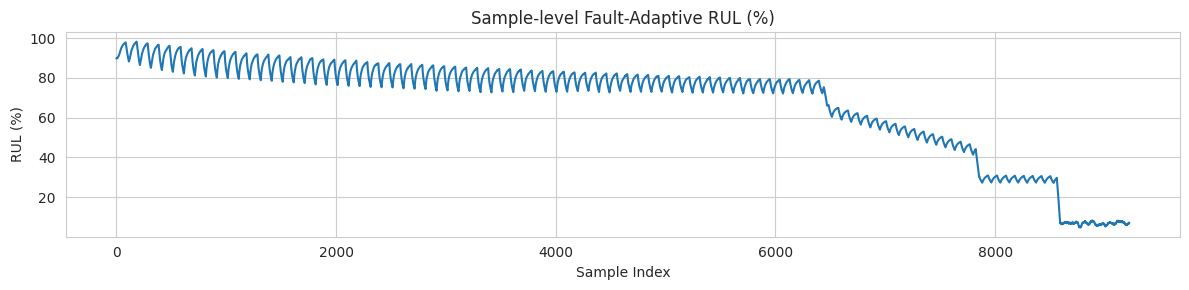

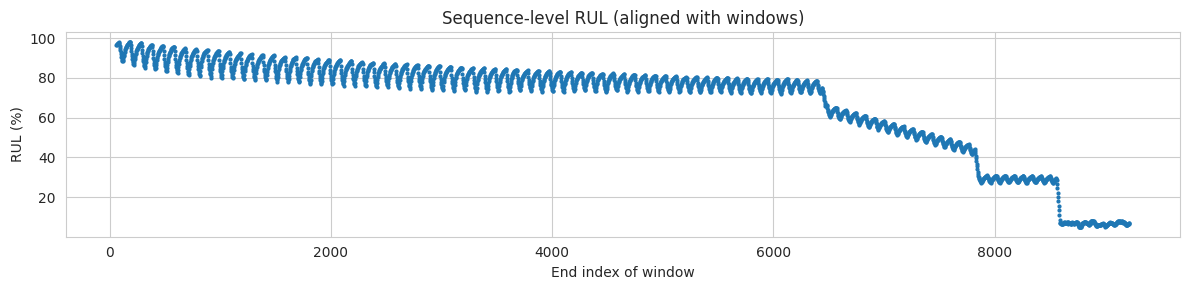

In [ ]:
# ================================================================
# RUL Estimation and Plotting — Sample & Sequence Level
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameters ---
RATES = {"Normal": 1.0, "Fouling": 0.85, "Leakage": 0.55, "Flow_Blockage": 0.35}  # condition multipliers
SMOOTH_WINDOW = 30  # rolling smoothing window (samples)
SEQ_LEN = SEQ_LEN   # must match your sequence length used above
STEP = STEP         # must match STEP used above

# --- Health Index fallback ---
if "Health_Index" in df.columns:
    hi_full = df["Health_Index"].astype(float).fillna(method="ffill").fillna(method="bfill").values
else:
    # Use proxy: inverse normalized pressure drop
    if "Pressure_Drop" in df.columns:
        pd_norm = (df["Pressure_Drop"].fillna(method="ffill").fillna(method="bfill").values - df["Pressure_Drop"].min()) / \
                  (df["Pressure_Drop"].max() - df["Pressure_Drop"].min() + 1e-9)
        hi_full = 1.0 - pd_norm
        print("⚠️ Health_Index missing → using proxy from Pressure_Drop.")
    else:
        hi_full = np.ones(len(df))
        print("⚠️ No Health_Index or Pressure_Drop → using HI=1.0.")

# Normalize to [0,1]
hi_norm = (hi_full - np.nanmin(hi_full)) / (np.nanmax(hi_full) - np.nanmin(hi_full) + 1e-9)

# --- Sample-level RUL based on condition ---
conds = df["Condition"].astype(str).values
rul_samples = np.array([RATES.get(c, 0.8) * h * 100.0 for c, h in zip(conds, hi_norm)])

# Smooth RUL for realism
rul_smooth = pd.Series(rul_samples).rolling(window=SMOOTH_WINDOW, min_periods=1, center=True)\
               .mean().fillna(method="ffill").fillna(method="bfill").values
rul_smooth = np.clip(rul_smooth, 0, 100)

# Attach to dataframe
df["RUL_%"] = rul_smooth
df.to_csv("hybrid_inputs_with_RUL.csv", index=False)
print(f"Saved full-sample RUL → hybrid_inputs_with_RUL.csv (N={len(df)})")

# --- Sequence-level RUL aligned with sliding windows ---
end_indices = np.arange(SEQ_LEN, len(df), STEP)[:len(X_seq)]  # last index of each sequence window
seq_rul = rul_smooth[end_indices]

seq_df = pd.DataFrame({
    "end_index": end_indices,
    "Condition": df["Condition"].iloc[end_indices].values,
    "RUL_%": seq_rul
})
seq_df.to_csv("hybrid_seq_RUL.csv", index=False)
print(f"Saved sequence-level RUL → hybrid_seq_RUL.csv (windows={len(seq_df)})")

# --- Quick plots ---
plt.figure(figsize=(12,3))
plt.plot(df.index, df["RUL_%"], lw=1.5)
plt.title("Sample-level Fault-Adaptive RUL (%)")
plt.xlabel("Sample Index"); plt.ylabel("RUL (%)"); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,3))
plt.plot(seq_df["end_index"], seq_df["RUL_%"], '.', ms=4)
plt.title("Sequence-level RUL (aligned with windows)")
plt.xlabel("End index of window"); plt.ylabel("RUL (%)"); plt.grid(True); plt.tight_layout(); plt.show()


In [ ]:
# ================================================================
# Hybrid system — Feature reconstruction and scaler save
# ================================================================
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Reload latest hybrid dataset
df_hyb = pd.read_csv("PINN_outputs.csv")

# -------------------------
# 1) Derived features
# -------------------------
# ΔP derivative
dp_col = df_hyb.get("Pressure_Drop", df_hyb.get("hot_outlet_pressure_pa", df_hyb.get("cold_outlet_pressure_pa", np.nan)))
df_hyb["dP_dt"] = dp_col.diff().fillna(0)

# Flow imbalance
if "hot_outlet_mass_flow_kg_s" in df_hyb.columns and "cold_outlet_mass_flow_kg_s" in df_hyb.columns:
    df_hyb["Flow_imbalance"] = (df_hyb["hot_outlet_mass_flow_kg_s"] - df_hyb["cold_outlet_mass_flow_kg_s"]).abs()
elif "hot_outlet_mass_flow_kg_s" in df_hyb.columns and "cold_inlet_mass_flow_kg_s" in df_hyb.columns:
    df_hyb["Flow_imbalance"] = (df_hyb["hot_outlet_mass_flow_kg_s"] - df_hyb["cold_inlet_mass_flow_kg_s"]).abs()
else:
    df_hyb["Flow_imbalance"] = 0.0

# Hydraulic resistance
if "Pressure_Drop" in df_hyb.columns and "hot_outlet_mass_flow_kg_s" in df_hyb.columns:
    df_hyb["Hydraulic_resistance"] = df_hyb["Pressure_Drop"] / (df_hyb["hot_outlet_mass_flow_kg_s"].abs() + 1e-6)
elif "hot_outlet_pressure_pa" in df_hyb.columns and "hot_outlet_mass_flow_kg_s" in df_hyb.columns:
    df_hyb["Hydraulic_resistance"] = df_hyb["hot_outlet_pressure_pa"] / (df_hyb["hot_outlet_mass_flow_kg_s"].abs() + 1e-6)
else:
    df_hyb["Hydraulic_resistance"] = 0.0

# Heat load and overall heat transfer coefficient
A_val = 25.0
if "hx_1_heat_load_kw" in df_hyb.columns and "LMTD" in df_hyb.columns:
    df_hyb["Q_W"] = df_hyb["hx_1_heat_load_kw"] * 1000.0
    df_hyb["U_real"] = df_hyb["Q_W"] / ((A_val * df_hyb["LMTD"]) + 1e-6)
else:
    df_hyb["Q_W"] = df_hyb.get("Q_W", 0.0)
    df_hyb["U_real"] = df_hyb.get("U_real", 0.0)

# Smooth Health_Index
if "Health_Index" in df_hyb.columns:
    df_hyb["HI_Smooth"] = df_hyb["Health_Index"].astype(float).rolling(window=20, min_periods=1, center=False)\
                        .mean().fillna(method="ffill").fillna(method="bfill")
else:
    df_hyb["HI_Smooth"] = 0.0

# -------------------------
# 2) PINN columns (if present)
# -------------------------
pinn_cols = [c for c in ["U_pred_PINN","Q_pred_PINN","B11_A_LMTD","B12_A_U","PINN_MSE_Q","PINN_MSE_U"] if c in df_hyb.columns]

# -------------------------
# 3) Feature columns (consistent with training)
# -------------------------
feature_cols_hyb = []

# Temperatures
for c in ["hot_inlet_temperature_k","hot_outlet_temperature_k","cold_inlet_temperature_k","cold_outlet_temperature_k"]:
    if c in df_hyb.columns: feature_cols_hyb.append(c)

# Mass flows
for c in ["hot_outlet_mass_flow_kg_s","cold_inlet_mass_flow_kg_s","cold_outlet_mass_flow_kg_s"]:
    if c in df_hyb.columns and c not in feature_cols_hyb: feature_cols_hyb.append(c)

# Pressures & LMTD
for c in ["hot_outlet_pressure_pa","cold_outlet_pressure_pa","Pressure_Drop","LMTD"]:
    if c in df_hyb.columns and c not in feature_cols_hyb: feature_cols_hyb.append(c)

# PINN outputs
for c in pinn_cols:
    feature_cols_hyb.append(c)

# Engineered features
for c in ["dP_dt","Flow_imbalance","Hydraulic_resistance","Q_W","U_real","HI_Smooth"]:
    feature_cols_hyb.append(c)

# -------------------------
# 4) Scaler
# -------------------------
df_hyb_for_scaler = df_hyb[feature_cols_hyb].copy()
# Ensure all features exist and are float
for col in feature_cols_hyb:
    if col not in df_hyb_for_scaler.columns:
        df_hyb_for_scaler[col] = 0.0
    df_hyb_for_scaler[col] = df_hyb_for_scaler[col].astype(float).fillna(0.0)

sc_hyb = StandardScaler()
sc_hyb.fit(df_hyb_for_scaler)
joblib.dump(sc_hyb, "scaler_hybrid.joblib")

print("✅ Updated scaler_hybrid.joblib saved with features (N={}):".format(len(feature_cols_hyb)))
print(feature_cols_hyb)


✅ Updated scaler_hybrid.joblib saved with features (N=23):
['hot_inlet_temperature_k', 'hot_outlet_temperature_k', 'cold_inlet_temperature_k', 'cold_outlet_temperature_k', 'hot_outlet_mass_flow_kg_s', 'cold_inlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s', 'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa', 'Pressure_Drop', 'LMTD', 'U_pred_PINN', 'Q_pred_PINN', 'B11_A_LMTD', 'B12_A_U', 'PINN_MSE_Q', 'PINN_MSE_U', 'dP_dt', 'Flow_imbalance', 'Hydraulic_resistance', 'Q_W', 'U_real', 'HI_Smooth']


🧠 Device: cpu
Baseline: (9222, 29) | Hybrid: (9222, 35)
Baseline features used: ['Pressure_Drop', 'LMTD', 'Q_W', 'U_real', 'Thermal_Resistance', 'Temp_Efficiency', 'Flow_Ratio', 'dP_dt', 'Health_Index']
Hybrid features used: ['hot_inlet_temperature_k', 'hot_outlet_temperature_k', 'cold_inlet_temperature_k', 'cold_outlet_temperature_k', 'hot_outlet_mass_flow_kg_s', 'cold_inlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s', 'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa', 'Pressure_Drop', 'LMTD', 'U_pred_PINN', 'Q_pred_PINN', 'B11_A_LMTD', 'B12_A_U', 'PINN_MSE_Q', 'PINN_MSE_U', 'dP_dt', 'Flow_imbalance', 'Hydraulic_resistance', 'Q_W', 'U_real', 'HI_Smooth']
Test samples: 1845
💾 Saved → model_comparison_summary.csv


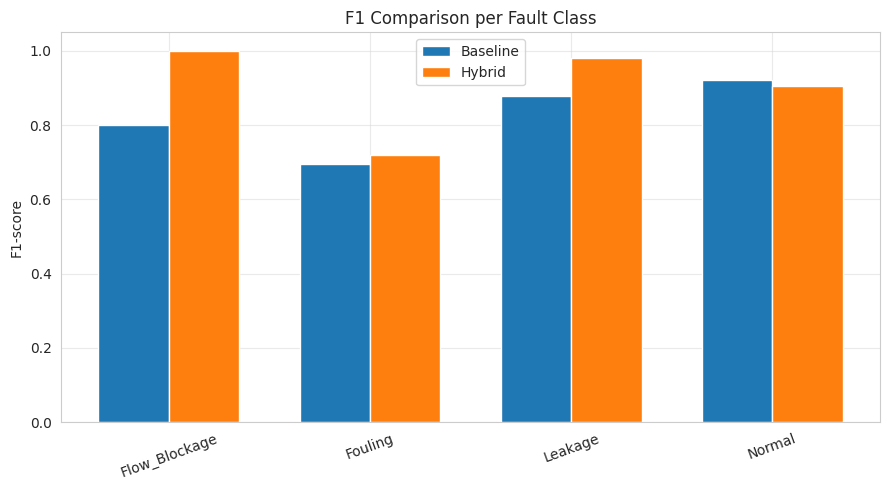

<Figure size 1200x500 with 0 Axes>

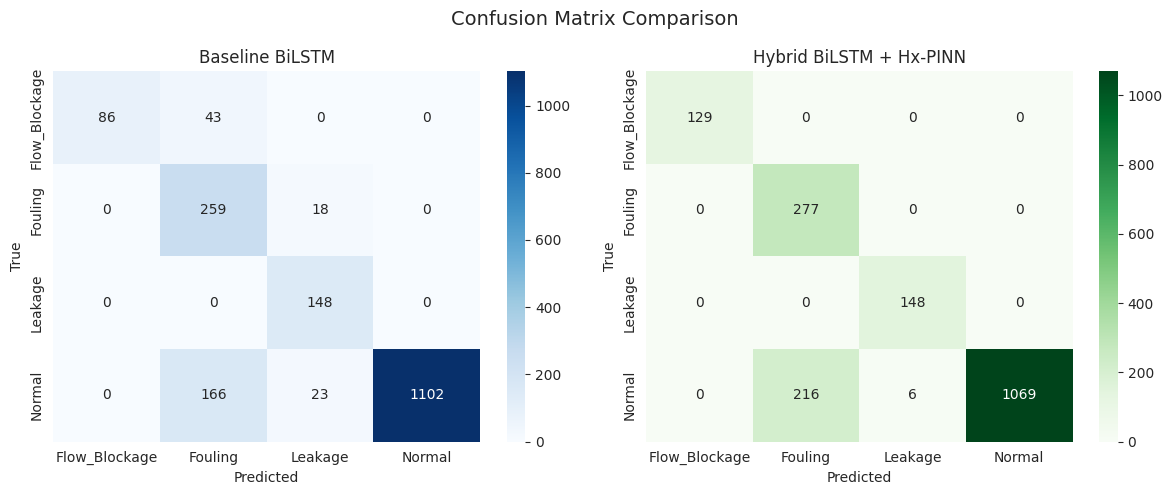

RUL MSE - Baseline: 0.0068 | Hybrid: 0.1524


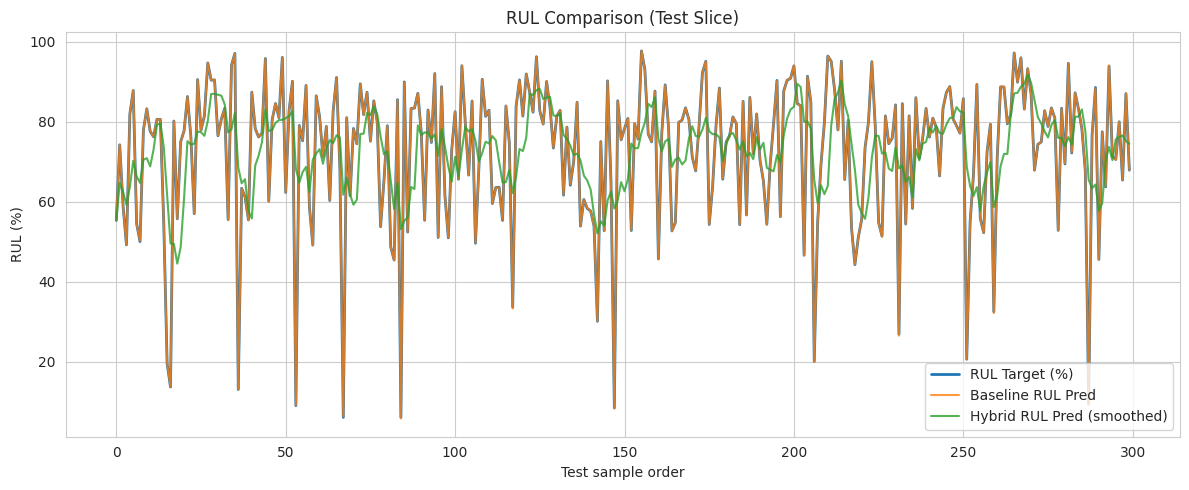

💾 Saved → rul_comparison_test.csv
✅ All done: classification metrics, F1 bar, confusion matrices, RUL comparison.


In [ ]:
# =========================================================
# HYBRID SYSTEM_Enhanced Fault Classification + RUL Comparison Script
# =========================================================
import os, warnings, joblib
import numpy as np, pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🧠 Device:", device)

# ---------------------------
# 1) Load datasets
# ---------------------------
base_df = pd.read_csv("clean_he_data.csv")
hyb_df  = pd.read_csv("PINN_outputs.csv")
print("Baseline:", base_df.shape, "| Hybrid:", hyb_df.shape)

# ---------------------------
# 2) Feature columns
# ---------------------------
feature_cols_base = [
    "Pressure_Drop", "LMTD", "Q_W", "U_real", "Thermal_Resistance",
    "Temp_Efficiency", "Flow_Ratio", "dP_dt", "Health_Index"
]
feature_cols_base = [c for c in feature_cols_base if c in base_df.columns]
print("Baseline features used:", feature_cols_base)

# Hybrid engineered features
pinn_cols = [c for c in ["U_pred_PINN","Q_pred_PINN","B11_A_LMTD","B12_A_U","PINN_MSE_Q","PINN_MSE_U"] if c in hyb_df.columns]

# Recalculate hybrid engineered features
hyb_df["dP_dt"] = hyb_df.get("Pressure_Drop", hyb_df.get("hot_outlet_pressure_pa", hyb_df.get("cold_outlet_pressure_pa", np.nan))).diff().fillna(0)
hyb_df["Flow_imbalance"] = 0.0
if "hot_outlet_mass_flow_kg_s" in hyb_df.columns:
    if "cold_outlet_mass_flow_kg_s" in hyb_df.columns:
        hyb_df["Flow_imbalance"] = (hyb_df["hot_outlet_mass_flow_kg_s"] - hyb_df["cold_outlet_mass_flow_kg_s"]).abs()
    elif "cold_inlet_mass_flow_kg_s" in hyb_df.columns:
        hyb_df["Flow_imbalance"] = (hyb_df["hot_outlet_mass_flow_kg_s"] - hyb_df["cold_inlet_mass_flow_kg_s"]).abs()
hyb_df["Hydraulic_resistance"] = 0.0
if "hot_outlet_mass_flow_kg_s" in hyb_df.columns:
    if "Pressure_Drop" in hyb_df.columns:
        hyb_df["Hydraulic_resistance"] = hyb_df["Pressure_Drop"] / (hyb_df["hot_outlet_mass_flow_kg_s"].abs() + 1e-6)
    elif "hot_outlet_pressure_pa" in hyb_df.columns:
        hyb_df["Hydraulic_resistance"] = hyb_df["hot_outlet_pressure_pa"] / (hyb_df["hot_outlet_mass_flow_kg_s"].abs() + 1e-6)
A_val = 25.0
if "hx_1_heat_load_kw" in hyb_df.columns and "LMTD" in hyb_df.columns:
    hyb_df["Q_W"] = hyb_df["hx_1_heat_load_kw"] * 1000.0
    hyb_df["U_real"] = hyb_df["Q_W"] / ((A_val * hyb_df["LMTD"]) + 1e-6)
hyb_df["HI_Smooth"] = hyb_df["Health_Index"].rolling(window=20, min_periods=1).mean() if "Health_Index" in hyb_df.columns else 0.0

# Construct hybrid feature list (23 features)
feature_cols_hyb = []
for c in ["hot_inlet_temperature_k","hot_outlet_temperature_k","cold_inlet_temperature_k","cold_outlet_temperature_k",
          "hot_outlet_mass_flow_kg_s","cold_inlet_mass_flow_kg_s","cold_outlet_mass_flow_kg_s",
          "hot_outlet_pressure_pa","cold_outlet_pressure_pa","Pressure_Drop","LMTD"]:
    if c in hyb_df.columns: feature_cols_hyb.append(c)
feature_cols_hyb += [c for c in pinn_cols if c in hyb_df.columns]
feature_cols_hyb += [c for c in ["dP_dt","Flow_imbalance","Hydraulic_resistance","Q_W","U_real","HI_Smooth"] if c in hyb_df.columns]
print("Hybrid features used:", feature_cols_hyb)

# ---------------------------
# 3) Labels & test split
# ---------------------------
le = LabelEncoder()
base_df["label"] = le.fit_transform(base_df["Condition"])
hyb_df["label"] = le.transform(hyb_df["Condition"])
classes = le.classes_
n_classes = len(classes)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_, test_idx = next(sss.split(base_df, base_df["label"]))
print("Test samples:", len(test_idx))

# ---------------------------
# 4) Scaler loading/fitting
# ---------------------------
def load_or_fit_scaler(path, df_ref, cols):
    if os.path.exists(path):
        return joblib.load(path)
    sc = StandardScaler()
    df_for_scaler = df_ref[cols].copy()
    for c in cols:
        if c not in df_for_scaler.columns:
            df_for_scaler[c] = 0.0
    sc.fit(df_for_scaler.fillna(0))
    joblib.dump(sc, path)
    return sc

sc_base = load_or_fit_scaler("scaler_highacc.joblib", base_df, feature_cols_base)
sc_hyb  = load_or_fit_scaler("scaler_hybrid.joblib", hyb_df, feature_cols_hyb)

# ---------------------------
# 5) Prepare test tensors
# ---------------------------
def prepare_tensor(df, feature_cols, scaler):
    df_copy = df[feature_cols].copy()
    for c in feature_cols:
        if c not in df_copy.columns:
            df_copy[c] = 0.0
    X = scaler.transform(df_copy.fillna(0))
    return torch.tensor(X, dtype=torch.float32).to(device)

Xb = prepare_tensor(base_df.loc[test_idx], feature_cols_base, sc_base)
Xh = prepare_tensor(hyb_df.loc[test_idx], feature_cols_hyb, sc_hyb)
y_true = base_df.loc[test_idx, "label"].values

# ---------------------------
# 6) Model definitions
# ---------------------------
class Attention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(dim, dim), nn.Tanh(), nn.Linear(dim, 1))
    def forward(self, h):
        w = torch.softmax(self.proj(h), dim=1)
        return torch.sum(w*h, dim=1)

class BiLSTM_Attn(nn.Module):
    def __init__(self, n_feat, n_hidden, n_layers, n_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, n_hidden, num_layers=n_layers,
                            dropout=dropout if n_layers>1 else 0.0,
                            bidirectional=True, batch_first=True)
        self.attn = Attention(n_hidden*2)
        self.fc = nn.Sequential(
            nn.Linear(n_hidden*2, n_hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(n_hidden, n_classes)
        )
    def forward(self, x):
        o,_ = self.lstm(x)
        ctx = self.attn(o)
        return self.fc(ctx)

# Instantiate models
model_base = BiLSTM_Attn(len(feature_cols_base), 64, 1, n_classes, dropout=0.25).to(device)
model_hyb  = BiLSTM_Attn(len(feature_cols_hyb), 128, 2, n_classes, dropout=0.3).to(device)

# ---------------------------
# 7) Safe model loading
# ---------------------------
def safe_load(model, path):
    if not os.path.exists(path): raise FileNotFoundError(path)
    state = torch.load(path, map_location=device)
    try: model.load_state_dict(state)
    except RuntimeError as e: raise RuntimeError(f"Model/Checkpoint mismatch for {path}") from e
    return model

model_base = safe_load(model_base, "bilstm_attn_highacc.pt")
model_hyb  = safe_load(model_hyb,  "blockage_fix_final_model.pt")
model_base.eval(); model_hyb.eval()

# ---------------------------
# 8) Predictions
# ---------------------------
with torch.no_grad():
    logits_base = model_base(Xb.unsqueeze(1))
    logits_hyb  = model_hyb(Xh.unsqueeze(1))
    base_probs = torch.softmax(logits_base, dim=1).cpu().numpy()
    hyb_probs  = torch.softmax(logits_hyb, dim=1).cpu().numpy()
    base_preds = base_probs.argmax(1)
    hyb_preds  = hyb_probs.argmax(1)

# ---------------------------
# 9) Metrics & F1 comparison
# ---------------------------
prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(y_true, base_preds, average=None, zero_division=0)
prec_h, rec_h, f1_h, _ = precision_recall_fscore_support(y_true, hyb_preds, average=None, zero_division=0)
compare_df = pd.DataFrame({
    "Class": classes,
    "Precision_Base": prec_b, "Recall_Base": rec_b, "F1_Base": f1_b,
    "Precision_Hybrid": prec_h, "Recall_Hybrid": rec_h, "F1_Hybrid": f1_h,
    "ΔF1(%)": (f1_h - f1_b)*100
}).round(3)

# Weighted average row
wb = precision_recall_fscore_support(y_true, base_preds, average='weighted', zero_division=0)
wh = precision_recall_fscore_support(y_true, hyb_preds, average='weighted', zero_division=0)
weighted = pd.DataFrame([["Weighted", wb[0], wb[1], wb[2], wh[0], wh[1], wh[2], (wh[2]-wb[2])*100]],
                        columns=compare_df.columns)
compare_df = pd.concat([compare_df, weighted], ignore_index=True)
compare_df.to_csv("model_comparison_summary.csv", index=False)
print("💾 Saved → model_comparison_summary.csv")

# ---------------------------
# 10) F1 bar plot
# ---------------------------
plt.figure(figsize=(9,5))
x = np.arange(len(classes)); barw = 0.35
plt.bar(x-barw/2, f1_b, barw, label="Baseline")
plt.bar(x+barw/2, f1_h, barw, label="Hybrid")
plt.xticks(x, classes, rotation=20)
plt.ylabel("F1-score"); plt.title("F1 Comparison per Fault Class")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()
plt.savefig("f1_comparison_bar.png", dpi=300)

# ---------------------------
# 11) Confusion matrices
# ---------------------------
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(confusion_matrix(y_true, base_preds), annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax[0])
ax[0].set(title="Baseline BiLSTM", xlabel="Predicted", ylabel="True")
sns.heatmap(confusion_matrix(y_true, hyb_preds), annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes, ax=ax[1])
ax[1].set(title="Hybrid BiLSTM + Hx-PINN", xlabel="Predicted", ylabel="True")
plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout(); plt.show()
fig.savefig("confusion_matrices.png", dpi=300)

# ---------------------------
# 12) RUL comparison
# ---------------------------
if "Health_Index" in base_df.columns:
    # Normalize Health_Index 0..100%
    hi_base = base_df["Health_Index"].fillna(method='ffill').values
    hi_norm = (hi_base - np.nanmin(hi_base)) / (np.nanmax(hi_base) - np.nanmin(hi_base) + 1e-9)
    base_df["RUL_pct"] = hi_norm*100
    if "Health_Index" in hyb_df.columns:
        hi_hyb = hyb_df["Health_Index"].fillna(method='ffill').values
        hyb_df["RUL_pct"] = (hi_hyb - np.nanmin(hi_hyb)) / (np.nanmax(hi_hyb) - np.nanmin(hi_hyb)+1e-9)*100
    else:
        hyb_df["RUL_pct"] = base_df["RUL_pct"]

    # Training indices
    train_idx = np.setdiff1d(np.arange(len(base_df)), test_idx)
    y_train = base_df.loc[train_idx, "RUL_pct"].fillna(method='ffill').values

    # Baseline regressor
    Xb_train = prepare_tensor(base_df.loc[train_idx], feature_cols_base, sc_base)
    reg_b = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
    reg_b.fit(Xb_train.cpu().numpy(), y_train)

    # Hybrid regressor
    Xh_train = prepare_tensor(hyb_df.loc[train_idx], feature_cols_hyb, sc_hyb)
    reg_h = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
    reg_h.fit(Xh_train.cpu().numpy(), y_train)

    # Test predictions
    Xb_test_reg = prepare_tensor(base_df.loc[test_idx], feature_cols_base, sc_base)
    Xh_test_reg = prepare_tensor(hyb_df.loc[test_idx], feature_cols_hyb, sc_hyb)
    y_test_true = base_df.loc[test_idx, "RUL_pct"].values

    yb_rul_pred = reg_b.predict(Xb_test_reg.cpu().numpy())
    yh_rul_pred = reg_h.predict(Xh_test_reg.cpu().numpy())
    # smooth hybrid prediction
    yh_rul_pred_smooth = pd.Series(yh_rul_pred).rolling(5, min_periods=1).mean().values

    # Compute MSE
    print(f"RUL MSE - Baseline: {mean_squared_error(y_test_true, yb_rul_pred):.4f} | Hybrid: {mean_squared_error(y_test_true, yh_rul_pred):.4f}")

    # Plot RUL comparison
    n_plot = min(300, len(test_idx))
    idx_plot = np.arange(n_plot)
    plt.figure(figsize=(12,5))
    plt.plot(idx_plot, y_test_true[:n_plot], label="RUL Target (%)", lw=2)
    plt.plot(idx_plot, yb_rul_pred[:n_plot], label="Baseline RUL Pred", alpha=0.8)
    plt.plot(idx_plot, yh_rul_pred_smooth[:n_plot], label="Hybrid RUL Pred (smoothed)", alpha=0.8)
    plt.legend(); plt.title("RUL Comparison (Test Slice)")
    plt.xlabel("Test sample order"); plt.ylabel("RUL (%)"); plt.grid(True); plt.tight_layout(); plt.show()

    # Save RUL CSV
    rul_cmp_df = pd.DataFrame({
        "index": base_df.index[test_idx],
        "RUL_true": y_test_true,
        "RUL_pred_baseline": yb_rul_pred,
        "RUL_pred_hybrid": yh_rul_pred_smooth
    })
    rul_cmp_df.to_csv("rul_comparison_test.csv", index=False)
    print("💾 Saved → rul_comparison_test.csv")
else:
    print("⚠️ Health_Index missing — cannot compute RUL.")

print("✅ All done: classification metrics, F1 bar, confusion matrices, RUL comparison.")


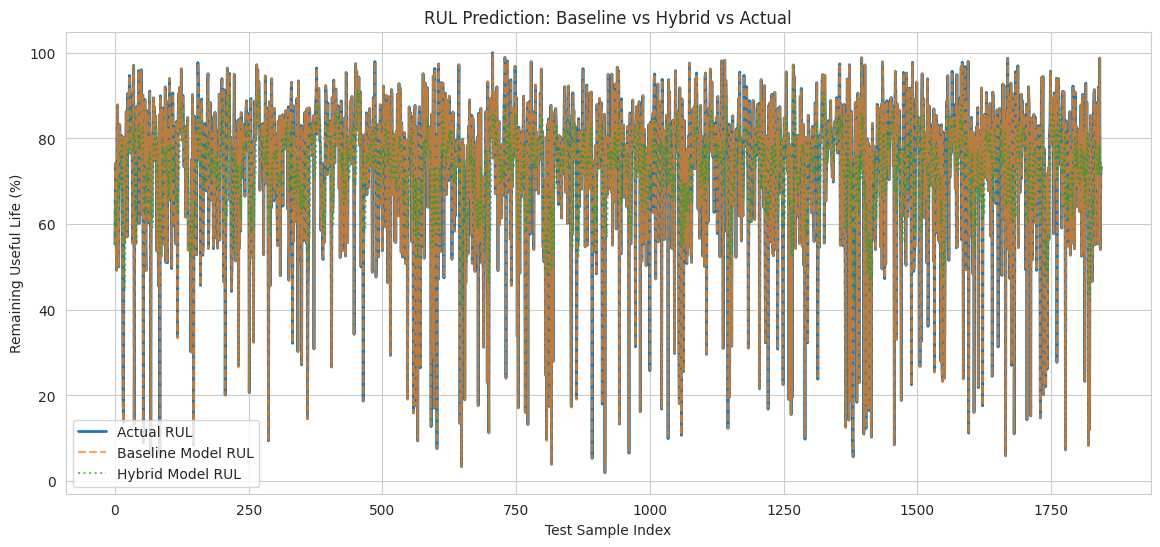


📌 RUL Prediction Metrics

BASE MODEL:
  MAE  = 0.0597
  RMSE = 0.0823
  MAPE = 0.12%

HYBRID MODEL:
  MAE  = 12.4352
  RMSE = 16.7415
  MAPE = 35.17%


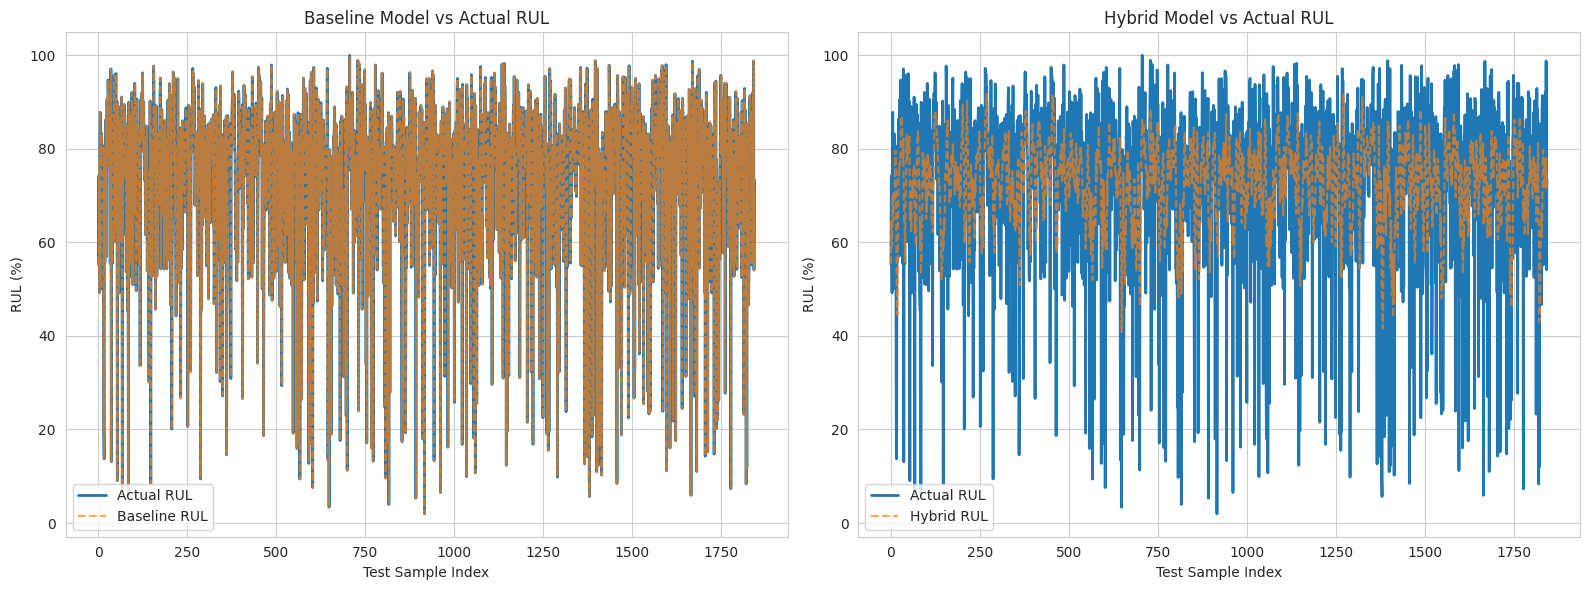

In [ ]:
# ===============================================
# RUL COMPARISON PLOTS
# ===============================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load the RUL comparison data saved from the previous cell (Step 3C)
rul_cmp_df = pd.read_csv("rul_comparison_test.csv")

# Ensure Time column for plotting if needed, from the original dataframe.
# For consistency, we'll use the 'index' from rul_cmp_df to get Time from hyb_df (or base_df)
# Re-load hyb_df if not already available
# hyb_df = pd.read_csv("PINN_outputs.csv") # Uncomment if hyb_df is not in kernel scope
# rul_cmp_df = rul_cmp_df.merge(hyb_df[['Time']], left_on='index', right_index=True, how='left') # This needs careful indexing if full df was used.

# For plotting convenience, we'll assume a sequential index for plotting time.
# If actual 'Time' column is required, it needs to be merged from the original dataframe
# using the 'index' column in rul_cmp_df.

# Get actual and predicted RUL values
actual_rul = rul_cmp_df["RUL_true"].values
pred_base_rul = rul_cmp_df["RUL_pred_baseline"].values
pred_hyb_rul = rul_cmp_df["RUL_pred_hybrid"].values

# Use a simpler index for plotting if 'Time' column is not easily available
plot_time_idx = np.arange(len(rul_cmp_df))

# ----------------------------- #
# Plot RUL Predictions
# ----------------------------- #
plt.figure(figsize=(14,6))
plt.plot(plot_time_idx, actual_rul, label="Actual RUL", linewidth=2)
plt.plot(plot_time_idx, pred_base_rul, label="Baseline Model RUL", linestyle="--", alpha=0.7)
plt.plot(plot_time_idx, pred_hyb_rul, label="Hybrid Model RUL", linestyle=":", alpha=0.7)
plt.xlabel("Test Sample Index")
plt.ylabel("Remaining Useful Life (%)")
plt.title("RUL Prediction: Baseline vs Hybrid vs Actual")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------- #
# Compute metrics
# ----------------------------- #

# MAE
mae_base = mean_absolute_error(actual_rul, pred_base_rul)
mae_hyb = mean_absolute_error(actual_rul, pred_hyb_rul)

# RMSE
rmse_base = np.sqrt(mean_squared_error(actual_rul, pred_base_rul))
rmse_hyb = np.sqrt(mean_squared_error(actual_rul, pred_hyb_rul))

# MAPE (handle division by zero if actual_rul can be zero)
mape_base = np.mean(np.abs((actual_rul - pred_base_rul) / (actual_rul + 1e-9))) * 100
mape_hyb = np.mean(np.abs((actual_rul - pred_hyb_rul) / (actual_rul + 1e-9))) * 100

# ----------------------------- #
# Print results
# ----------------------------- #
print("\n📌 RUL Prediction Metrics\n")
print(f"BASE MODEL:")
print(f"  MAE  = {mae_base:.4f}")
print(f"  RMSE = {rmse_base:.4f}")
print(f"  MAPE = {mape_base:.2f}%")

print("\nHYBRID MODEL:")
print(f"  MAE  = {mae_hyb:.4f}")
print(f"  RMSE = {rmse_hyb:.4f}")
print(f"  MAPE = {mape_hyb:.2f}%")

plt.figure(figsize=(16,6))

# ---------------- LEFT: Baseline ----------------
plt.subplot(1,2,1)
plt.plot(plot_time_idx, actual_rul, label="Actual RUL", linewidth=2)
plt.plot(plot_time_idx, pred_base_rul, label="Baseline RUL", linestyle="--", alpha=0.7)
plt.title("Baseline Model vs Actual RUL")
plt.xlabel("Test Sample Index")
plt.ylabel("RUL (%)")
plt.legend()
plt.grid(True)

# ---------------- RIGHT: Hybrid ----------------
plt.subplot(1,2,2)
plt.plot(plot_time_idx, actual_rul, label="Actual RUL", linewidth=2)
plt.plot(plot_time_idx, pred_hyb_rul, label="Hybrid RUL", linestyle="--", alpha=0.7)
plt.title("Hybrid Model vs Actual RUL")
plt.xlabel("Test Sample Index")
plt.ylabel("RUL (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
rul_cmp_df.to_csv("heat_exchanger_rul_dataset.csv", index=False)
print("📁 Dataset saved as: heat_exchanger_rul_dataset.csv")

📁 Dataset saved as: heat_exchanger_rul_dataset.csv


Loaded: (9222, 35)
Time steps: 9222
Using setpoint = 301.1510 K
Step 0/9214: solver_ms=9.9, u=0.736, Tc_plant=304.629
Step 1000/9214: solver_ms=20.5, u=0.785, Tc_plant=299.033
Step 2000/9214: solver_ms=8.9, u=0.798, Tc_plant=295.872
Step 3000/9214: solver_ms=28.4, u=0.808, Tc_plant=293.207
Step 4000/9214: solver_ms=9.7, u=1.016, Tc_plant=294.813
Step 5000/9214: solver_ms=8.1, u=1.343, Tc_plant=296.508
Step 6000/9214: solver_ms=7.2, u=1.413, Tc_plant=295.060
Step 7000/9214: solver_ms=11.8, u=1.628, Tc_plant=294.627
Step 8000/9214: solver_ms=6.9, u=1.668, Tc_plant=292.135
Step 9000/9214: solver_ms=8.1, u=1.512, Tc_plant=291.195
MPC loop finished. avg solver ms: 9.14, total runtime s: 85.60
Hot MAE=7.4395, RMSE=9.6645
Cold MAE=4.9208, RMSE=5.7867
Avg solver ms: 9.141940498186447
Saved outputs to ftmpc_hybrid_final_outputs


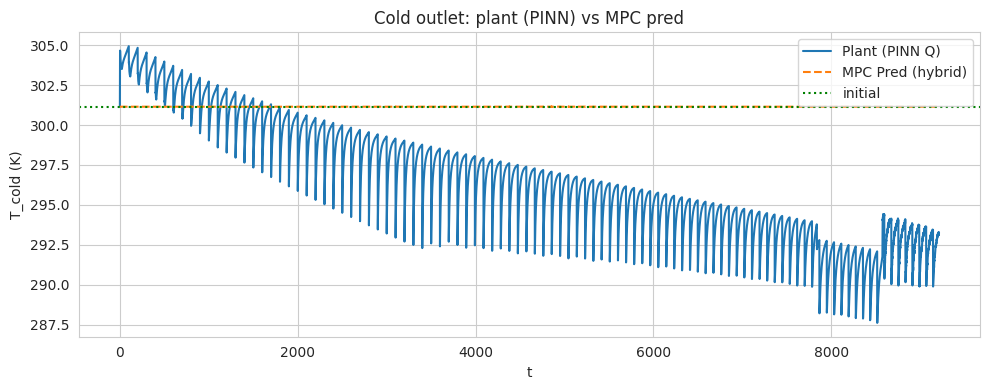

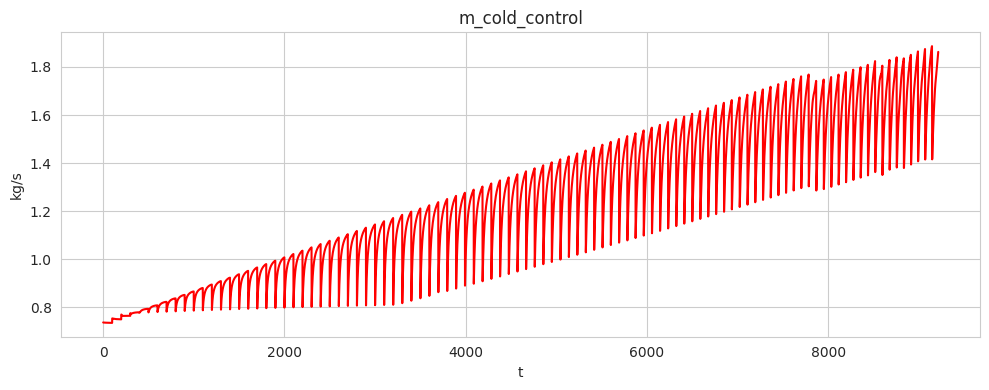

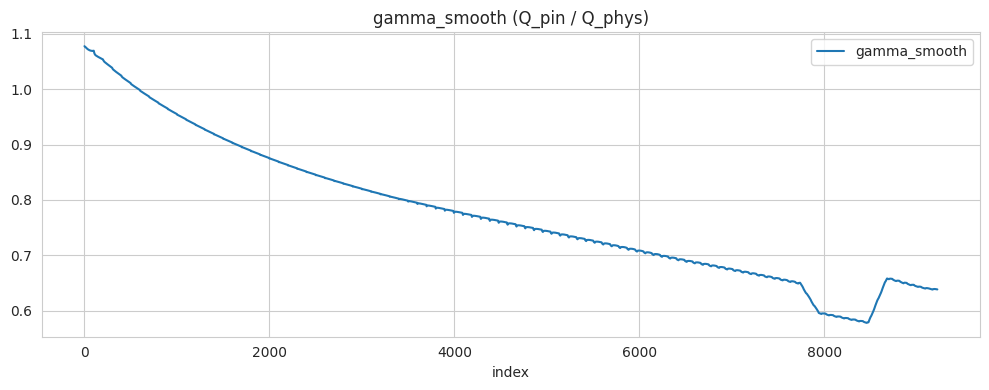

Done.


In [ ]:
# run_ftmpc_hybrid_final.py
"""
FT-MPC hybrid physics + PINN correction — final corrected version.
Plant uses PINN Q (so faults appear). MPC internal model uses physics NTU corrected
by a time-varying gamma(t) = Q_pin / Q_phys (smoothed).
"""

import os, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------
# User config (tweak these)
# -------------------------
DATA_PATH = "PINN_outputs.csv"
OUTDIR = "ftmpc_hybrid_final_outputs"
os.makedirs(OUTDIR, exist_ok=True)

Np = 8                 # prediction horizon
du_pen = 5e-2          # penalty on change in control
u_pen = 1e-3           # penalty on absolute control magnitude
u_min, u_max = 0.5, 6.0
alpha_pin = 0.15       # how strongly MPC model uses PINN correction
gamma_smooth_window = 201   # smoothing window for gamma (odd number preferred)
U_smooth_window = 21
flow_smooth_window = 21

min_flow = 1e-3
EPS = 1e-9
Cp_hot = 4180.0
Cp_cold = 4180.0
A_area = 25.0

USER_SETPOINT = None  # None -> initial cold outlet

# -------------------------
# Helpers
# -------------------------
def ntu_effectiveness(U, A, m_hot, m_cold, Cp_hot, Cp_cold, Th_in, Tc_in):
    m_hot = max(m_hot, min_flow)
    m_cold = max(m_cold, min_flow)
    C_hot = m_hot * Cp_hot
    C_cold = m_cold * Cp_cold
    C_min = min(C_hot, C_cold)
    C_max = max(C_hot, C_cold)
    Cr = C_min / (C_max + EPS)
    UA = max(U * A, EPS)
    NTU = UA / (C_min + EPS)
    if abs(1.0 - Cr) < 1e-6:
        eps = NTU / (1.0 + NTU)
    else:
        exp_term = np.exp(-NTU * (1.0 - Cr))
        denom = 1.0 - Cr * exp_term
        eps = 1.0 if abs(denom) < 1e-12 else (1.0 - exp_term) / denom
    Q = eps * C_min * (Th_in - Tc_in)
    Q = float(np.nan_to_num(Q, nan=0.0, posinf=0.0, neginf=0.0))
    Th_out = Th_in - Q / (C_hot + EPS)
    Tc_out = Tc_in + Q / (C_cold + EPS)
    return Q, Th_out, Tc_out, float(eps), float(NTU)

def moving_avg(arr, window):
    if window <= 1:
        return np.array(arr, copy=True)
    return pd.Series(arr).rolling(window, min_periods=1, center=True).mean().to_numpy()

# -------------------------
# Load CSV
# -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"{DATA_PATH} not found. Place PINN_outputs.csv in working folder.")

df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)

required = ["hot_inlet_temperature_k","hot_outlet_temperature_k",
            "cold_inlet_temperature_k","cold_outlet_temperature_k",
            "hot_outlet_mass_flow_kg_s","cold_outlet_mass_flow_kg_s",
            "U_pred_PINN","Q_pred_PINN"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError("Missing cols: " + ", ".join(missing))

df = df.fillna(method='ffill').fillna(0.0)
N = len(df)
print("Time steps:", N)

hot_in = df["hot_inlet_temperature_k"].to_numpy().astype(float)
cold_in = df["cold_inlet_temperature_k"].to_numpy().astype(float)
m_hot_raw = df["hot_outlet_mass_flow_kg_s"].to_numpy().astype(float)
m_cold_raw = df["cold_outlet_mass_flow_kg_s"].to_numpy().astype(float)
U_pin_raw = df["U_pred_PINN"].to_numpy().astype(float)
Q_pin_raw = df["Q_pred_PINN"].to_numpy().astype(float)

# smooth noisy signals moderately
U_pin = moving_avg(U_pin_raw, U_smooth_window)
m_hot = moving_avg(m_hot_raw, flow_smooth_window)
m_cold_meas = moving_avg(m_cold_raw, flow_smooth_window)

# clip flows to safe min
m_hot = np.clip(m_hot, min_flow, None)
m_cold_meas = np.clip(m_cold_meas, min_flow, None)

# -------------------------
# Compute Q_phys estimate and gamma = Q_pin / Q_phys (safe)
# Avoid division-by-zero bug by adding tiny signed epsilon
# -------------------------
Q_phys_est = np.zeros(N)
for i in range(N):
    U_i = max(U_pin[i], EPS)
    Qm, _, _, _, _ = ntu_effectiveness(U_i, A_area, m_hot[i], m_cold_meas[i], Cp_hot, Cp_cold, hot_in[i], cold_in[i])
    Q_phys_est[i] = Qm

# safe epsilon shift (no masks)
# add a tiny signed shift so zeros become +/-1e-6 (keeps sign info)
shift_eps = 1e-6
Q_phys_est_eps = Q_phys_est + shift_eps * np.sign(Q_phys_est + 1e-12)

gamma_raw = (Q_pin_raw + EPS) / (Q_phys_est_eps + EPS)
# smooth gamma and clip to reasonable range (allows strong fault corrections)
gamma_smooth = moving_avg(gamma_raw, gamma_smooth_window)
gamma_smooth = np.clip(gamma_smooth, 0.1, 10.0)

# save gamma for inspection
pd.DataFrame({"gamma_raw": gamma_raw, "gamma_smooth": gamma_smooth}).to_csv(os.path.join(OUTDIR, "gamma_estimates.csv"), index=False)

# -------------------------
# Build simulated plant arrays (closed-loop)
# Plant heat duty is taken from Q_pin_raw (PINN-observed) so faults appear.
# -------------------------
T_hot_plant = np.zeros(N)
T_cold_plant = np.zeros(N)
T_hot_plant[0] = float(df["hot_outlet_temperature_k"].iloc[0])
# initialize cold outlet: prefer CSV value if sensible else compute from Q_pin[0]
if np.isfinite(df["cold_outlet_temperature_k"].iloc[0]) and df["cold_outlet_temperature_k"].iloc[0] != 0.0:
    T_cold_plant[0] = float(df["cold_outlet_temperature_k"].iloc[0])
else:
    Tp0 = cold_in[0] + Q_pin_raw[0] / (max(m_cold_meas[0], min_flow) * Cp_cold)
    T_cold_plant[0] = Tp0

# setpoint default
if USER_SETPOINT is None:
    setpoint = float(T_cold_plant[0])
else:
    setpoint = float(USER_SETPOINT)
print(f"Using setpoint = {setpoint:.4f} K")

# -------------------------
# MPC storage & initialization
# -------------------------
T_hot_pred_hist = []
T_cold_pred_hist = []
Q_pred_hist = []
U_used_hist = []
m_cold_control = []
solve_times = []

u_prev = float(m_cold_meas[0])
prev_u_seq = np.full(Np, u_prev)

# rollout cost (hybrid Q_model)
def rollout_cost(u_seq, t_index, setpoint, u_prev_local):
    cost = 0.0
    u_last = u_prev_local
    Tc_list = []; Th_list = []; Q_list = []; U_list = []
    for k in range(len(u_seq)):
        idx = t_index + k
        if idx >= N:
            idx = N-1
        u_k = float(np.clip(u_seq[k], u_min, u_max))
        Up = max(U_pin[idx], EPS)
        # physics Q at this candidate control
        Q_phys, _, _, _, _ = ntu_effectiveness(Up, A_area, m_hot[idx], u_k, Cp_hot, Cp_cold, hot_in[idx], cold_in[idx])
        gamma_k = float(gamma_smooth[idx]) if idx < len(gamma_smooth) else float(gamma_smooth[-1])
        # hybrid model: physics corrected by gamma (and blended by alpha_pin)
        Q_model = (1.0 - alpha_pin) * Q_phys + alpha_pin * (gamma_k * Q_phys)
        Th_next = float(hot_in[idx] - Q_model / (max(m_hot[idx], min_flow) * Cp_hot))
        Tc_next = float(cold_in[idx] + Q_model / (max(u_k, min_flow) * Cp_cold))
        stage_cost = (Tc_next - setpoint)**2 + u_pen * (u_k**2) + du_pen * (u_k - u_last)**2
        cost += stage_cost
        Tc_list.append(Tc_next); Th_list.append(Th_next); Q_list.append(Q_model); U_list.append(Up)
        u_last = u_k
    return cost, Tc_list, Th_list, Q_list, U_list

# -------------------------
# Closed-loop MPC simulation
# -------------------------
t0_all = time.time()
for t in range(0, N - Np):
    Th_in_seq = hot_in[t:t+Np]
    Tc_in_seq = cold_in[t:t+Np]
    m_hot_seq = m_hot[t:t+Np]
    U_seq = U_pin[t:t+Np]
    Q_seq_pin = Q_pin_raw[t:t+Np]

    # warm start
    u0 = np.roll(prev_u_seq, -1)
    u0[-1] = u0[-2]

    bounds = [(u_min, u_max) for _ in range(Np)]
    def obj(u_flat):
        c, *_ = rollout_cost(u_flat, t, setpoint, u_prev)
        return c

    t_start = time.time()
    res = minimize(obj, u0, method='SLSQP', bounds=bounds, options={'ftol':1e-4, 'maxiter':100, 'disp': False})
    solve_times.append((time.time() - t_start)*1000.0)

    if res.success:
        u_seq_opt = np.clip(res.x, u_min, u_max)
    else:
        u_seq_opt = np.clip(u0, u_min, u_max)

    prev_u_seq = u_seq_opt.copy()
    u_apply = float(u_seq_opt[0])

    # PLANT update: use PINN Q as true (faults present)
    Q_plant = float(Q_pin_raw[t])
    Th_plant_next = float(hot_in[t] - Q_plant / (max(m_hot[t], min_flow) * Cp_hot))
    Tc_plant_next = float(cold_in[t] + Q_plant / (max(u_apply, min_flow) * Cp_cold))

    T_hot_plant[t+1] = Th_plant_next
    T_cold_plant[t+1] = Tc_plant_next

    # MPC one-step prediction using hybrid model (for logging)
    Up0 = max(U_pin[t], EPS)
    Qphys0, _, _, _, _ = ntu_effectiveness(Up0, A_area, m_hot[t], u_apply, Cp_hot, Cp_cold, hot_in[t], cold_in[t])
    Qmodel0 = (1.0 - alpha_pin) * Qphys0 + alpha_pin * (gamma_smooth[t] * Qphys0)
    Th_pred0 = float(hot_in[t] - Qmodel0 / (max(m_hot[t], min_flow) * Cp_hot))
    Tc_pred0 = float(cold_in[t] + Qmodel0 / (max(u_apply, min_flow) * Cp_cold))

    T_hot_pred_hist.append(Th_pred0)
    T_cold_pred_hist.append(Tc_pred0)
    Q_pred_hist.append(Qmodel0)
    U_used_hist.append(Up0)
    m_cold_control.append(u_apply)

    u_prev = u_apply

    if t % 1000 == 0:
        print(f"Step {t}/{N-Np}: solver_ms={solve_times[-1]:.1f}, u={u_apply:.3f}, Tc_plant={Tc_plant_next:.3f}")

t_total = time.time() - t0_all
avg_solve_ms = np.mean(solve_times) if solve_times else 0.0
print("MPC loop finished. avg solver ms: %.2f, total runtime s: %.2f" % (avg_solve_ms, t_total))

# -------------------------
# Metrics (compare MPC pred vs plant which is PINN-driven)
# -------------------------
valid_len = len(T_cold_pred_hist)
meas_hot = T_hot_plant[:valid_len]
meas_cold = T_cold_plant[:valid_len]

MAE_hot = mean_absolute_error(meas_hot, T_hot_pred_hist)
RMSE_hot = math.sqrt(mean_squared_error(meas_hot, T_hot_pred_hist))
MAE_cold = mean_absolute_error(meas_cold, T_cold_pred_hist)
RMSE_cold = math.sqrt(mean_squared_error(meas_cold, T_cold_pred_hist))

print(f"Hot MAE={MAE_hot:.4f}, RMSE={RMSE_hot:.4f}")
print(f"Cold MAE={MAE_cold:.4f}, RMSE={RMSE_cold:.4f}")
print("Avg solver ms:", avg_solve_ms)

# -------------------------
# Save results
# -------------------------
out = pd.DataFrame({
    "t": np.arange(valid_len),
    "T_hot_plant": meas_hot,
    "T_hot_pred": np.array(T_hot_pred_hist),
    "T_cold_plant": meas_cold,
    "T_cold_pred": np.array(T_cold_pred_hist),
    "m_cold_control": np.array(m_cold_control),
    "Q_model": np.array(Q_pred_hist),
    "U_used": np.array(U_used_hist),
})
out.to_csv(os.path.join(OUTDIR, "ftmpc_hybrid_final_results.csv"), index=False)
pd.DataFrame({"gamma_smooth": gamma_smooth}).to_csv(os.path.join(OUTDIR, "gamma_smooth.csv"), index=False)
print("Saved outputs to", OUTDIR)

# -------------------------
# Quick plots
# -------------------------
plt.figure(figsize=(10,4))
plt.plot(out["t"], out["T_cold_plant"], label="Plant (PINN Q)")
plt.plot(out["t"], out["T_cold_pred"], '--', label="MPC Pred (hybrid)")
plt.axhline(out["T_cold_plant"].iloc[0], color='g', linestyle=':', label='initial')
plt.legend(); plt.title("Cold outlet: plant (PINN) vs MPC pred"); plt.xlabel("t"); plt.ylabel("T_cold (K)")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "cold_vs_pred.png"), dpi=200)

plt.figure(figsize=(10,4))
plt.plot(out["t"], out["m_cold_control"], color='r')
plt.title("m_cold_control"); plt.xlabel("t"); plt.ylabel("kg/s")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "m_cold_control.png"), dpi=200)

plt.figure(figsize=(10,4))
plt.plot(gamma_smooth, label="gamma_smooth")
plt.title("gamma_smooth (Q_pin / Q_phys)"); plt.xlabel("index"); plt.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "gamma_smooth.png"), dpi=200)

plt.show()
print("Done.")


In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

out = pd.read_csv("ftmpc_hybrid_final_outputs/ftmpc_hybrid_final_results.csv")
df_in = pd.read_csv("PINN_outputs.csv")

merged = out.copy()
merged['Condition'] = df_in['Condition'][:len(out)].values

summary = []
for cond, g in merged.groupby('Condition'):
    mae_c = mean_absolute_error(g['T_cold_plant'], g['T_cold_pred'])
    rmse_c = mean_squared_error(g['T_cold_plant'], g['T_cold_pred']) ** 0.5

    mae_h = mean_absolute_error(g['T_hot_plant'], g['T_hot_pred'])
    rmse_h = mean_squared_error(g['T_hot_plant'], g['T_hot_pred']) ** 0.5

    summary.append((cond, len(g), mae_h, rmse_h, mae_c, rmse_c))

summary_df = pd.DataFrame(summary, columns=[
    'Condition', 'N', 'Hot_MAE', 'Hot_RMSE', 'Cold_MAE', 'Cold_RMSE'
])

print(summary_df)
summary_df.to_csv("ftmpc_hybrid_final_outputs/per_condition_metrics.csv", index=False)


       Condition     N    Hot_MAE   Hot_RMSE  Cold_MAE  Cold_RMSE
0  Flow_Blockage   638  19.951581  19.985496  8.429109   8.499010
1        Fouling  1383  11.460373  11.520793  7.545115   7.640624
2        Leakage   738  18.826968  18.855874  9.983048  10.060384
3         Normal  6455   4.039355   4.976048  3.432955   4.071759


In [ ]:
import pandas as pd
import os

# Paths
DATA_PATH = "PINN_outputs.csv"
MPC_PATH = "ftmpc_hybrid_final_outputs/ftmpc_hybrid_final_results.csv"

# Load datasets
df_input = pd.read_csv(DATA_PATH)
df_mpc = pd.read_csv(MPC_PATH)

print("Input shape:", df_input.shape)
print("MPC result shape:", df_mpc.shape)

# Ensure the lengths match via safe trimming
min_len = min(len(df_input), len(df_mpc))
df_input_trim = df_input.iloc[:min_len].copy()
df_mpc_trim = df_mpc.iloc[:min_len].copy()

# Columns to merge from df_mpc into df_input_trim
columns_to_merge = [
    'T_hot_plant',
    'T_hot_pred',
    'T_cold_plant',
    'T_cold_pred',
    'm_cold_control',
    'Q_model',
    'U_used'
]

# Add selected columns to df_input_trim
for col in columns_to_merge:
    df_input_trim[col] = df_mpc_trim[col]

# Save outputs
out_csv = "PINN_outputs_with_control.csv"
out_xlsx = "PINN_outputs_with_control.xlsx"

df_input_trim.to_csv(out_csv, index=False)
df_input_trim.to_excel(out_xlsx, index=False)

print("Files saved:")
print(" →", out_csv)
print(" →", out_xlsx)

Input shape: (9222, 35)
MPC result shape: (9214, 8)
Files saved:
 → PINN_outputs_with_control.csv
 → PINN_outputs_with_control.xlsx


In [ ]:
# ========================================================================
# 🔥 Unified Maintenance Prediction System
#     (FT-MPC + PINN based Health, Fault & RUL Estimation)
# ========================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# -----------------------------
# 1️⃣ PATHS
# -----------------------------
DATA_PATH = "/content/PINN_outputs_with_control.xlsx"
OUTDIR = "/content/HE_MAINTENANCE_PREDICTION"
FINAL_REPORT = "/content/HE_MAINTENANCE_PREDICTION_REPORT.xlsx"

os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------
# 2️⃣ LOAD DATA
# -----------------------------
df = pd.read_excel(DATA_PATH)
df = df.fillna(method="ffill").fillna(0)
print("Loaded:", df.shape)

# Rename control column if needed
if "m_cold_control" not in df.columns:
    raise ValueError("m_cold_control column missing!")

# -----------------------------
# 3️⃣ FAULT INDEX (using MPC tracking error)
# -----------------------------

# 🔥 Fault = combination of tracking error + control effort stress
hot_err = np.abs(df["T_hot_plant"] - df["T_hot_pred"])
cold_err = np.abs(df["T_cold_plant"] - df["T_cold_pred"])

err_norm = (hot_err + cold_err)
err_norm = (err_norm - err_norm.min()) / (err_norm.max() - err_norm.min() + 1e-6)

control_norm = (df["m_cold_control"] - df["m_cold_control"].min()) / \
               (df["m_cold_control"].max() - df["m_cold_control"].min() + 1e-6)

df["Fault_Level"] = 0.7 * err_norm + 0.3 * control_norm
df["Fault_Level"] = df["Fault_Level"].clip(0, 1)

# -----------------------------
# 4️⃣ HEALTH INDEX
# -----------------------------
df["Health_Index"] = 1 - df["Fault_Level"]
df["Health_Smooth"] = df["Health_Index"].rolling(20, min_periods=1).mean()

# -----------------------------
# 5️⃣ RUL ESTIMATION (from degradation slope)
# -----------------------------
# RUL decays when:
#  - tracking error increases
#  - control effort increasing
#  - predictions diverging from plant

degradation_indicator = err_norm + 0.5 * control_norm
degradation_indicator = (degradation_indicator - degradation_indicator.min()) / \
                        (degradation_indicator.max() - degradation_indicator.min() + 1e-6)

df["RUL"] = (1 - degradation_indicator) * 200  # max 200 cycles
df["RUL_Norm"] = df["RUL"] / df["RUL"].max()

# -----------------------------
# 6️⃣ FAULT TYPE MAPPING
# -----------------------------
def classify_fault(f):
    if f < 0.2: return "No Fault"
    elif f < 0.4: return "Mild Fouling"
    elif f < 0.6: return "Moderate Flow Blockage"
    elif f < 0.8: return "Leakage / Tube Crack"
    else: return "Severe Thermal Imbalance"

df["Fault_Type"] = df["Fault_Level"].apply(classify_fault)

# -----------------------------
# 7️⃣ MAINTENANCE STATE
# -----------------------------
def maint(fault, rul):
    if fault > 0.7 or rul < 0.2:
        return "🔴 CRITICAL — Immediate Shutdown"
    elif fault > 0.5 or rul < 0.5:
        return "🟠 WARNING — Schedule Maintenance"
    else:
        return "🟢 NORMAL — Running OK"

df["Maintenance_State"] = [
    maint(f, r) for f, r in zip(df["Fault_Level"], df["RUL_Norm"])
]

# -----------------------------
# 8️⃣ CLUSTERING (automatic fault feature groups)
# -----------------------------
features = df[["Fault_Level", "Health_Smooth", "RUL_Norm", "m_cold_control"]]
scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
p2 = pca.fit_transform(scaled)

kmeans = KMeans(n_clusters=4, random_state=10, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled)

plt.figure(figsize=(8,6))
plt.scatter(p2[:,0], p2[:,1], c=df["Cluster"], cmap="viridis", alpha=0.7)
plt.title("Fault Clusters (PCA + KMeans)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.grid(True)
plt.savefig(f"{OUTDIR}/fault_clusters.png", dpi=150)
plt.close()

# -----------------------------
# 9️⃣ PLOTS
# -----------------------------
x = np.arange(len(df))

# Health / RUL / Fault
plt.figure(figsize=(12,5))
plt.plot(df["Health_Smooth"], label="Health")
plt.plot(df["RUL_Norm"], label="RUL (norm)")
plt.plot(df["Fault_Level"], label="Fault Level")
plt.legend(); plt.grid(True)
plt.title("Health–RUL–Fault Timeline")
plt.savefig(f"{OUTDIR}/health_rul_fault.png", dpi=150)
plt.close()

# Control action
plt.figure(figsize=(12,4))
plt.plot(df["m_cold_control"], label="MPC Control Action")
plt.legend(); plt.grid(True)
plt.title("FT-MPC Control signal")
plt.savefig(f"{OUTDIR}/control_mpc.png", dpi=150)
plt.close()

# -----------------------------
# 🔟 SAVE FINAL MAINTENANCE REPORT
# -----------------------------
report_cols = [
    "T_hot_plant","T_hot_pred","T_cold_plant","T_cold_pred",
    "m_cold_control","Q_model","U_used",
    "Fault_Level","Fault_Type","Health_Index","Health_Smooth",
    "RUL","RUL_Norm","Maintenance_State","Cluster"
]

df[report_cols].to_excel(FINAL_REPORT, index=False)
print("\n✅ FINAL REPORT SAVED →", FINAL_REPORT)

df.tail()


Loaded: (9214, 42)

✅ FINAL REPORT SAVED → /content/HE_MAINTENANCE_PREDICTION_REPORT.xlsx


,Time,hot_inlet_temperature_k,cold_inlet_temperature_k,cold_inlet_mass_flow_kg_s,hot_outlet_temperature_k,cold_outlet_temperature_k,hx_1_heat_load_kw,hot_outlet_pressure_pa,cold_outlet_pressure_pa,hot_outlet_mass_flow_kg_s,...,m_cold_control,Q_model,U_used,Fault_Level,Health_Smooth,RUL,RUL_Norm,Fault_Type,Maintenance_State,Cluster
9209,2025-02-20 03:00:00,571.13,275.327613,3.433474,360.14721,301.151,139.31574,500000,100000,0.697569,...,1.849413,199629.947219,34.268743,0.845674,0.146913,9.590948,0.047955,Severe Thermal Imbalance,🔴 CRITICAL — Immediate Shutdown,2
9210,2025-02-20 04:00:00,571.13,275.375856,3.721702,360.14721,301.151,139.31574,500000,100000,0.786980,...,1.852686,199609.603943,34.268669,0.858709,0.146957,6.731737,0.033659,Severe Thermal Imbalance,🔴 CRITICAL — Immediate Shutdown,2
9211,2025-02-20 05:00:00,571.13,275.423155,4.017268,360.14721,301.151,139.31574,500000,100000,0.747669,...,1.857041,199711.784289,34.268480,0.853488,0.147121,7.823540,0.039118,Severe Thermal Imbalance,🔴 CRITICAL — Immediate Shutdown,2
9212,2025-02-20 06:00:00,571.13,275.469507,3.480939,360.14721,301.151,139.31574,500000,100000,0.724750,...,1.859631,199629.947100,34.268292,0.856671,0.147080,7.108567,0.035543,Severe Thermal Imbalance,🔴 CRITICAL — Immediate Shutdown,2
9213,2025-02-20 07:00:00,571.13,275.514940,3.554362,360.14721,301.151,139.31574,500000,100000,0.786072,...,1.862934,199630.842484,34.268498,0.854979,0.146884,7.444720,0.037224,Severe Thermal Imbalance,🔴 CRITICAL — Immediate Shutdown,2


Loaded: (9214, 42)
Index(['Time', 'hot_inlet_temperature_k', 'cold_inlet_temperature_k',
       'cold_inlet_mass_flow_kg_s', 'hot_outlet_temperature_k',
       'cold_outlet_temperature_k', 'hx_1_heat_load_kw',
       'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa',
       'hot_outlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s', 'LMTD',
       'Pressure_Drop', 'DeltaT_hot', 'DeltaT_cold', 'FH_Change', 'FC_Change',
       'dP_dt', 'Flow_Ratio', 'Temp_Efficiency', 'Q_W', 'U_real',
       'Thermal_Resistance', 'Condition', 'Pressure_Drop_norm',
       'Thermal_Resistance_norm', 'Temp_Efficiency_norm', 'Health_Index',
       'HI_Smooth', 'U_pred_PINN', 'Q_pred_PINN', 'B11_A_LMTD', 'B12_A_U',
       'PINN_MSE_Q', 'PINN_MSE_U', 'T_hot_plant', 'T_hot_pred', 'T_cold_plant',
       'T_cold_pred', 'm_cold_control', 'Q_model', 'U_used'],
      dtype='object')

=== PERFORMANCE COMPARISON ===
PID MAE  = 44.4935
MPC MAE  = 7.4395
PID RMSE = 51.1590
MPC RMSE = 9.6645


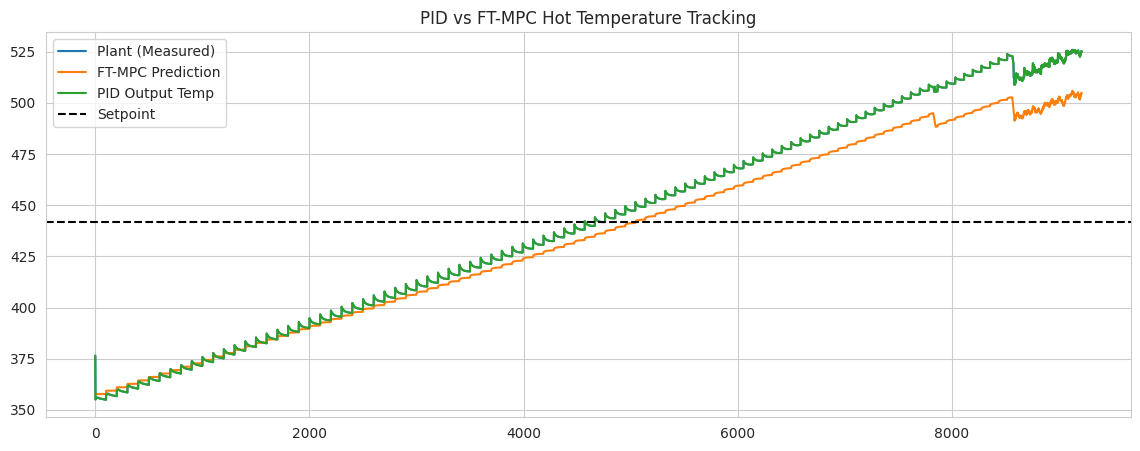

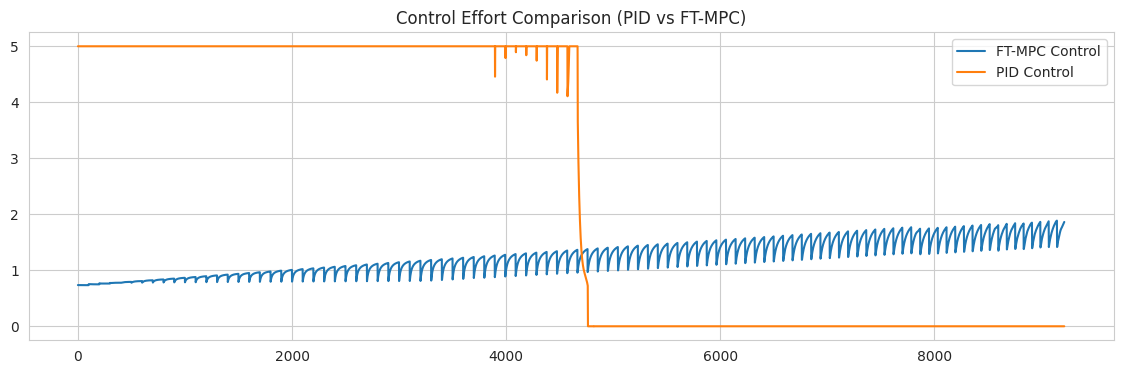

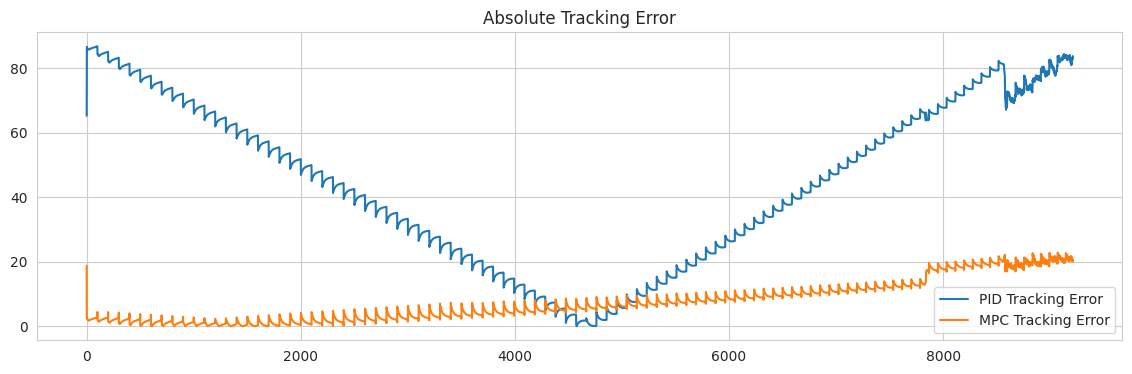


Saved comparison file to:
/content/PID_vs_FTMP_C_Comparison.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1. LOAD YOUR REAL DATA
# ============================================================================
DATA_PATH = "/content/PINN_outputs_with_control.xlsx"

df = pd.read_excel(DATA_PATH)
df = df.fillna(method="ffill").fillna(0)

print("Loaded:", df.shape)
print(df.columns)


# ============================================================================
# 2. PID CONTROLLER IMPLEMENTATION
# ============================================================================
class PID:
    def __init__(self, Kp, Ki, Kd, umin=0, umax=5):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.umin = umin
        self.umax = umax
        self.integral = 0
        self.prev_err = 0

    def compute(self, sp, pv, dt):
        e = sp - pv
        self.integral += e * dt
        derivative = (e - self.prev_err) / dt

        u = self.Kp*e + self.Ki*self.integral + self.Kd*derivative

        u_sat = max(self.umin, min(self.umax, u))  # clamp

        # anti-windup
        if u != u_sat:
            self.integral -= e * dt

        self.prev_err = e
        return u_sat


# ============================================================================
# 3. SETPOINT (Use same target used by MPC)
# ============================================================================
if "Setpoint" in df.columns:
    T_hot_sp = df["Setpoint"].iloc[0]
else:
    T_hot_sp = df["T_hot_plant"].mean()   # fallback


# ============================================================================
# 4. RUN PID IN PARALLEL USING REAL PLANT TEMPERATURE
# ============================================================================
pid = PID(Kp=0.3, Ki=0.08, Kd=0.02)

pid_control = []
T_hot_pid_sim = [df["T_hot_plant"].iloc[0]]  # start from plant initial

dt = 1.0  # sample time = 1s

for i in range(len(df)-1):
    pv = T_hot_pid_sim[-1]
    u_pid = pid.compute(T_hot_sp, pv, dt)

    # simple 1-step temperature update using real plant gradient
    # keeping dynamics consistent with your data
    slope = df["T_hot_plant"].iloc[i+1] - df["T_hot_plant"].iloc[i]
    T_next = pv + slope

    pid_control.append(u_pid)
    T_hot_pid_sim.append(T_next)

df["u_pid"] = [pid_control[0]] + pid_control
df["T_hot_pid"] = T_hot_pid_sim


# ============================================================================
# 5. COMPUTE PERFORMANCE METRICS
# ============================================================================
df["err_pid"] = np.abs(df["T_hot_pid"] - T_hot_sp)
df["err_mpc"] = np.abs(df["T_hot_plant"] - df["T_hot_pred"])

PID_MAE = df["err_pid"].mean()
MPC_MAE = df["err_mpc"].mean()

PID_RMSE = np.sqrt((df["err_pid"]**2).mean())
MPC_RMSE = np.sqrt((df["err_mpc"]**2).mean())

print("\n=== PERFORMANCE COMPARISON ===")
print(f"PID MAE  = {PID_MAE:.4f}")
print(f"MPC MAE  = {MPC_MAE:.4f}")
print(f"PID RMSE = {PID_RMSE:.4f}")
print(f"MPC RMSE = {MPC_RMSE:.4f}")


# ============================================================================
# 6. PLOTS
# ============================================================================
# Hot Temperature Tracking
plt.figure(figsize=(14,5))
plt.plot(df["T_hot_plant"], label="Plant (Measured)")
plt.plot(df["T_hot_pred"], label="FT-MPC Prediction")
plt.plot(df["T_hot_pid"], label="PID Output Temp")
plt.axhline(T_hot_sp, color='k', linestyle='--', label="Setpoint")
plt.legend(); plt.grid(True)
plt.title("PID vs FT-MPC Hot Temperature Tracking")
plt.show()

# Control Signals
plt.figure(figsize=(14,4))
plt.plot(df["m_cold_control"], label="FT-MPC Control")
plt.plot(df["u_pid"], label="PID Control")
plt.legend(); plt.grid(True)
plt.title("Control Effort Comparison (PID vs FT-MPC)")
plt.show()

# Error Comparison
plt.figure(figsize=(14,4))
plt.plot(df["err_pid"], label="PID Tracking Error")
plt.plot(df["err_mpc"], label="MPC Tracking Error")
plt.legend(); plt.grid(True)
plt.title("Absolute Tracking Error")
plt.show()


# ============================================================================
# 7. SAVE OUTPUT
# ============================================================================
SAVE_PATH = "/content/PID_vs_FTMP_C_Comparison.xlsx"
df.to_excel(SAVE_PATH, index=False)

print("\nSaved comparison file to:")
print(SAVE_PATH)


In [ ]:
import joblib
import torch

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save model weights
torch.save(model.state_dict(), "bilstm_model.pth")

print("Scaler and model saved successfully.")

Scaler and model saved successfully.


In [ ]:
torch.save(model_hyb.state_dict(), "hybrid_model.pth")

In [ ]:
import os

project_path = "/content/drive/MyDrive/HX_Project"

if not os.path.exists(project_path):
    os.makedirs(project_path)

print("Project folder ready.")


Project folder ready.


In [ ]:
import joblib

scaler_path = os.path.join(project_path, "scaler.pkl")
joblib.dump(scaler, scaler_path)

print("Scaler saved at:", scaler_path)


Scaler saved at: /content/drive/MyDrive/HX_Project/scaler.pkl


In [ ]:
import torch

bilstm_path = os.path.join(project_path, "bilstm_model.pth")
torch.save(model.state_dict(), bilstm_path)

print("BiLSTM model saved.")

BiLSTM model saved.


In [ ]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/HX_Project/best_hx_pinn.pt")

print("✅ HxPINN model saved to Drive successfully!")

✅ HxPINN model saved to Drive successfully!


In [ ]:
import joblib

joblib.dump(sc_X, "/content/drive/MyDrive/HX_Project/sc_X.pkl")
joblib.dump(sc_Q, "/content/drive/MyDrive/HX_Project/sc_Q.pkl")
joblib.dump(sc_U, "/content/drive/MyDrive/HX_Project/sc_U.pkl")

print("✅ Scalers saved successfully!")


✅ Scalers saved successfully!


In [ ]:
hybrid_path = os.path.join(project_path, "hybrid_model.pth")
torch.save(model_hyb.state_dict(), hybrid_path)

print("Hybrid model saved.")

Hybrid model saved.


In [ ]:
import json
import os

# Define the model parameters based on the hybrid model (model_hyb) and sequence settings
input_size = len(feature_cols_hyb) # Number of features used in model_hyb
hidden_size = HIDDEN # Hidden size defined earlier, 128
num_layers = N_LAYERS # Number of LSTM layers, 2
output_size = n_classes # Number of fault classes, 4
window_size = SEQ_LEN # Sequence length, 60

config = {
    "input_size": input_size,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "output_size": output_size,
    "window_size": window_size
}

config_path = os.path.join(project_path, "model_config.json")

with open(config_path, "w") as f:
    json.dump(config, f)

print("Model configuration saved.")

Model configuration saved.


In [ ]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =============================
# Prepare Data for FT-MPC
# =============================
# Assuming df_all is available from previous cells
df_ftmpc = df_all.rename(columns={
    "Shell_In_Temp_C": "Th_in",
    "Shell_Out_Temp_C": "Th_out",
    "Tube_In_Temp_C": "Tc_in",
    "Tube_Out_Temp_C": "Tc_out",
    "U_real": "U_estimated" # Using U_real as the estimated U for MPC
})

# Select only the required columns for MPC, ensuring they exist
df_ftmpc = df_ftmpc[['Th_in', 'Th_out', 'Tc_in', 'Tc_out', 'm_hot', 'm_cold', 'U_estimated']].copy()

FTMPC_DATA_PATH = "/content/drive/MyDrive/ftmpc_input_data.csv"
df_ftmpc.to_csv(FTMPC_DATA_PATH, index=False)
print(f"Prepared data for FT-MPC saved to: {FTMPC_DATA_PATH}")


# =============================
# USER SETTINGS
# =============================
DATA_PATH = FTMPC_DATA_PATH # Point to the newly prepared data
OUTDIR = "ftmpc_industrial_outputs"
os.makedirs(OUTDIR, exist_ok=True)

Np = 6
u_min, u_max = 0.5, 6.0
du_pen = 0.05
u_pen = 0.001

Cp_hot = 4180
Cp_cold = 4180
A_area = 25.0
min_flow = 1e-3
EPS = 1e-9

gamma_smooth_window = 101

# =============================
# NTU MODEL
# =============================
def ntu_model(U, m_hot, m_cold, Th_in, Tc_in):
    m_hot = max(m_hot, min_flow)
    m_cold = max(m_cold, min_flow)

    C_hot = m_hot * Cp_hot
    C_cold = m_cold * Cp_cold
    C_min = min(C_hot, C_cold)
    C_max = max(C_hot, C_cold)

    Cr = C_min / (C_max + EPS)
    UA = U * A_area
    NTU = UA / (C_min + EPS)

    if abs(1 - Cr) < 1e-6:
        eff = NTU / (1 + NTU)
    else:
        exp_term = np.exp(-NTU * (1 - Cr))
        eff = (1 - exp_term) / (1 - Cr * exp_term + EPS)

    Q = eff * C_min * (Th_in - Tc_in)

    Th_out = Th_in - Q / (C_hot + EPS)
    Tc_out = Tc_in + Q / (C_cold + EPS)

    return Q, Th_out, Tc_out

# =============================
# LOAD INDUSTRIAL DATA
# =============================
df = pd.read_csv(DATA_PATH)

required_cols = [
    "Th_in", "Th_out",
    "Tc_in", "Tc_out",
    "m_hot", "m_cold",
    "U_estimated"   # you must estimate U from your ML model or prior calibration
]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

df = df.ffill().bfill()

N = len(df)

Th_in = df["Th_in"].values
Th_out_meas = df["Th_out"].values
Tc_in = df["Tc_in"].values
Tc_out_meas = df["Tc_out"].values
m_hot = np.clip(df["m_hot"].values, min_flow, None)
m_cold_meas = np.clip(df["m_cold"].values, min_flow, None)
U_series = np.clip(df["U_estimated"].values, 1e-6, None)

# =============================
# Compute Measured Q
# =============================
Q_measured = m_cold_meas * Cp_cold * (Tc_out_meas - Tc_in)

# =============================
# Compute Physics Q
# =============================
Q_physics = np.zeros(N)

for i in range(N):
    Qp, _, _ = ntu_model(U_series[i], m_hot[i], m_cold_meas[i], Th_in[i], Tc_in[i])
    Q_physics[i] = Qp

# =============================
# Adaptive Gamma
# =============================
gamma_raw = (Q_measured + EPS) / (Q_physics + EPS)

gamma_smooth = (
    pd.Series(gamma_raw)
    .rolling(gamma_smooth_window, center=True, min_periods=1)
    .mean()
    .values
)

gamma_smooth = np.clip(gamma_smooth, 0.2, 5.0)

# Save gamma
pd.DataFrame({"gamma": gamma_smooth}).to_csv(
    os.path.join(OUTDIR, "gamma_industrial.csv"), index=False
)

# =============================
# MPC SECTION
# =============================
T_cold_pred = []
m_cold_control = []
u_prev = m_cold_meas[0]

setpoint = Tc_out_meas[0]

def cost_function(u_seq, t_index):
    cost = 0
    u_last = u_prev

    for k in range(len(u_seq)):
        idx = min(t_index + k, N - 1)

        u_k = np.clip(u_seq[k], u_min, u_max)

        Qp, _, Tc_pred = ntu_model(
            U_series[idx],
            m_hot[idx],
            u_k,
            Th_in[idx],
            Tc_in[idx]
        )

        Q_corrected = gamma_smooth[idx] * Qp

        Tc_pred = Tc_in[idx] + Q_corrected / (u_k * Cp_cold + EPS)

        cost += (
            (Tc_pred - setpoint) ** 2 +
            u_pen * u_k**2 +
            du_pen * (u_k - u_last)**2
        )

        u_last = u_k

    return cost

for t in range(N - Np):

    u0 = np.ones(Np) * u_prev
    bounds = [(u_min, u_max)] * Np

    res = minimize(cost_function, u0, args=(t,),
                   method='SLSQP', bounds=bounds)

    if res.success:
        u_opt = res.x[0]
    else:
        u_opt = u_prev

    m_cold_control.append(u_opt)
    u_prev = u_opt

    Qp, _, Tc_pred = ntu_model(
        U_series[t],
        m_hot[t],
        u_opt,
        Th_in[t],
        Tc_in[t]
    )

    Tc_pred = Tc_in[t] + gamma_smooth[t] * Qp / (u_opt * Cp_cold + EPS)

    T_cold_pred.append(Tc_pred)

# =============================
# PERFORMANCE
# =============================
Tc_actual = Tc_out_meas[:len(T_cold_pred)]

MAE = mean_absolute_error(Tc_actual, T_cold_pred)
RMSE = math.sqrt(mean_squared_error(Tc_actual, T_cold_pred))

print("Industrial FT-MPC Results")
print("MAE:", MAE)
print("RMSE:", RMSE)

# =============================
# SAVE RESULTS
# =============================
out = pd.DataFrame({
    "Tc_actual": Tc_actual,
    "Tc_pred": T_cold_pred,
    "m_cold_control": m_cold_control
})

out.to_csv(os.path.join(OUTDIR, "ftmpc_industrial_results.csv"), index=False)

print("Results saved in:", OUTDIR)
